#**Network Data Analysis Laboratory - IXP Traffic Forecasting**

##**Team: 12**

* Luca Bordin (luca1.bordin@mail.polimi.it)

* Mattia Menegale (mattia.menegale@mail.polimi.it)

* Francesco Cavalieri (francesco1.cavalieri@mail.polimi.it)

**Course:** Network Measurement And Data Analysis Lab 2025/2026

---

## **Project Goal**

The goal of this project is to **predict future regional IXP traffic volumes using historical time-series data**.<br>

Given a sliding window of the past **N** 5-minute intervals, the system must forecast the throughput of the next **K** intervals, where **K** and **N** are the parameters of a sensitivity analysis.

The work is organized around two main objectives:

*  **[Analysis]** Explore the IXP traffic dataset, aggregate the European IXPs into a single regional time series and prepare the chronological train/validation/test splits used by all models.
* **[Model comparison]** Compare different forecasting approaches on the sliding-window task, a **Random Forest Regressor** (a general-purpose ML baseline), recurrent neural networks **(LSTM, GRU)**, the classical statistical model **ARIMA**, and a **Time-Series Foundation Model (TSFM)**, restricting the analysis to the Europe region.

## **Dataset**

The project uses a collection of publicly available traffic statistics for Internet Exchange Points (IXPs), covering two years (**January 2023 - December 2024**). The dataset spans **472 IXPs worldwide** and accounts for **87% of all publicly announced IXP port capacity**.

* **Data scope:** time-series volumetric data reported at **5-minute intervals** for most IXPs (~88%), capturing application-agnostic Internet usage patterns globally.

* **Features:** Timestamp (adjusted to local time), IXP ID, Region (e.g., Europe, South America), Inbound Traffic Volume (bps), and Port Capacity.

Our analysis focuses on the **Europe** region for the model-comparison task and on **Jakarta's IXPs** for the federated-learning task.

## **Pipeline Overview**

| S | Section | Objective / Goal |
|:---|:---|:---|
| **S0** | **Environment Setup** | Dependencies, imports, Drive mount, global constants, shared utilities. |
| **S1** | **Data Loading & Exploration** | Load the dataset, explore the Europe-region series: diurnal/weekly patterns, missing data, stationarity, correlations. |
| **S2** | **Data Preprocessing** | Clean and regularize onto a strict 5-min grid (duplicates, gaps, outliers), build the Europe aggregate series, apply the chronological 70/15/15 split, and persist to Drive. |                                                                 | | **S3** | **Forecasting Setup** | Shared pipeline for all models: seeds, **N**/**K** config, splits, standardization, common metrics.|
| **S4** | **Model Training & Comparison (Europe)** | Train **RF**, **LSTM**, **GRU**, **ARIMA**, **TSFM** on the S3 setup, each with the **N**/**K** sensitivity analysis; compare on MAE, RMSE, MAPE, R², training cost. |

## **Evaluation**

Models are assessed with multiple performance metrics, including **MSE**, **MAE**, **RMSE**, and **MAPE** for forecasting quality, together with **training duration** and inference cost to capture the accuracy/efficiency trade-off across models and scenarios.

## **Resources**

The project is built on the publicly available **IXP traffic dataset** released by ETH Zurich's Networked Systems Group ([nsg-ethz/ixp-traffic-dataset](https://github.com/nsg-ethz/ixp-traffic-dataset)), and is informed by the accompanying study *"Five Blind Men and the Internet: Towards an Understanding of Internet Traffic"* (Kirci, Mishra, and Vanbever, arXiv:2509.06515, 2025).

# **S0 - Problem Analysis & Environment Setup**
Install dependencies, import libraries, mount Google Drive, define global constants, initialize clients, and provide shared utility functions.

## **S0.1 - Problem Analysis: Sliding-Window Traffic Forecasting**

### **Goal**

The goal is to predict future IXP traffic throughput from recent history: given the past N 5-minute measurements, forecast the next K values. This is a multi-step time-series forecasting problem, framed with a sliding window.

We compare five approaches under the same conditions and on the same grid of (N, K) pairs: a Random Forest Regressor (which treats the N lagged values as a flat feature vector), two recurrent networks (LSTM and GRU), a classical statistical model (ARIMA), and a pre-trained Time-Series Foundation Model (Chronos, used zero-shot).


### **Sliding-Window Formulation**
Given a series $x_1, x_2, \dots, x_T$ sampled every 5 minutes, each training example uses the last N observations as input, $X_t = [x_{t-N+1}, \dots, x_t]$, and the next K as target, $Y_t = [x_{t+1}, \dots, x_{t+K}]$. Sliding the window one step at a time yields about $T - N - K + 1$ examples per series.



### **Role of N and K**

N sets how much history the model sees: with a small N the model only captures short-term momentum and cannot see daily or weekly patterns, while a large N exposes seasonality directly but increases input dimensionality and training time (this hurts Random Forest in particular). We sweep N from 30 minutes up to 24 hours.

K sets how far ahead we predict. Error inevitably grows with K, since uncertainty compounds with the horizon. For small K the persistence baseline $\hat{x}_{t+1} = x_t$ is already hard to beat; differences between models become visible around 30-60 minutes, and at horizons of several hours only models that capture the daily pattern remain accurate.


### **Multi-Step Output Strategy**

For K > 1, the supervised models predict all K steps in a single forward pass (a dense output layer of size K for LSTM/GRU, scikit-learn's native multi-output for Random Forest). ARIMA and Chronos produce the K-step forecast natively. This avoids the error compounding of recursive forecasting and keeps the comparison fair.

### **Sensitivity Analysis**

Every model is evaluated across the same grid of $(N, K)$ pairs, reporting MSE/MAE on the test set, training time, and error-vs-horizon curves (details in S3-S4).


## **S0.2 Imports & Setup**

In [1]:
# ========================
# IMPORTS
# ========================

import os
import requests
import requests
import pandas as pd
import json
import time
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from pathlib import Path
from google.colab import drive
from google.colab import userdata


drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [2]:
# ========================
# CONSTANTS
# ========================
URL = "https://www.peeringdb.com/api/ix"
REGION_CONTINENT = "Europe"
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15


# ========================
# PATH
# ========================

PROJECT_DIR = Path("/content/drive/MyDrive/NDA_PROJECT/MAIN")

DATASET_DIR = PROJECT_DIR / "ixp-traffic-dataset"
DATA_DIR = DATASET_DIR / "data"

METADATA_FILE_PATH = DATA_DIR / "metadata.csv"
TRAFFIC_PROFILES_DIR = DATA_DIR / "profiles"

EUROPE_JSON_FILE_PATH = PROJECT_DIR / "europe.json"

EUROPE_RAW_PROFILES_FILE_PATH = DATA_DIR / "df_EU_timeseries.parquet"
EUROPE_TRAIN_FILE_PATH = DATA_DIR / "df_EU_timeseries_train.parquet"
EUROPE_VALIDATION_FILE_PATH = DATA_DIR / "df_EU_timeseries_validation.parquet"
EUROPE_TEST_FILE_PATH = DATA_DIR / "df_EU_timeseries_test.parquet"

EUROPE_AGGREGATED_SERIES_FILE_PATH = DATA_DIR / "europe_aggregated_5min.parquet"
EUROPE_PROFILE_COVERAGE_FILE_PATH = DATA_DIR / "europe_profile_coverage.csv"



# **S1 - Load Dataset, Raw Data Visualization & Analysis**
Load dataset from github, extract European data only, explore the Europe-region time series: inspect diurnal and weekly patterns, missing data, stationarity, and feature correlations to assess what the data suggests (useful features, seasonality, redundancy).

## **S1.1 - Load Dataset**

In [3]:
# Download the dataset from GitHub only if it is not already cached on Drive.

DATASET_REPO_URL = "https://github.com/nsg-ethz/ixp-traffic-dataset.git"

if METADATA_FILE_PATH.exists() and TRAFFIC_PROFILES_DIR.exists():
    print(f"Dataset already cached on Drive at {DATASET_DIR} -> skipping download.")
else:
    print("Dataset not found on Drive -> downloading from GitHub ")
    PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    !git clone --depth 1 "$DATASET_REPO_URL" "$DATASET_DIR"

# Verify that all required dataset paths are now available
required_paths = [
    PROJECT_DIR,
    DATASET_DIR,
    DATA_DIR,
    METADATA_FILE_PATH,
    TRAFFIC_PROFILES_DIR,
]

for path in required_paths:
    print(path, "->", path.exists())

missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required paths:\n" + "\n".join(str(path) for path in missing)
    )


Dataset already cached on Drive at /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset -> skipping download.
/content/drive/MyDrive/NDA_PROJECT/MAIN -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/metadata.csv -> True
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/profiles -> True


## **S1.2 - Extract European data only**

The downloaded dataset contains data of IXPs from multiple continents.
Here we extract data of European IXPs only.



### **Keep only fully European profiles**
A profile can represent one IXP or a coupled group of IXPs (⁠ixp_id + ⁠siblings⁠).
We include it only if every ID in that group belongs to Europe.

### **Loading the European IXP list**

We need the list of European IXPs (name, ID, city, country) to know which traffic profiles
belong to the Europe region. This list comes from the **PeeringDB** API
(`/api/ix?region_continent=Europe`).

Since the PeeringDB public endpoint is rate-limited (HTTP 429 on repeated calls), we adopt a
**cache-first** strategy: the list is fetched once and saved to `europe.json` on Drive, and
every later run simply reloads it. The API is contacted again only if the cache file is missing.

In [4]:
# Generic PeeringDB loader used for both Europe and Indonesia/Jakarta IXPs.
# The traffic dataset metadata contains IXP IDs, but not geographic information.
# PeeringDB is used to retrieve IXPs by region/country, and results are cached
# to avoid repeated API calls and rate limits.

import json
import requests
from pathlib import Path

#Normalize PeeringDB records to the column names used in this notebook.
def _normalize_peeringdb_record(record):

    ixp_id = record.get("Id", record.get("id"))

    return {
        "Id": int(ixp_id),
        "Name": record.get("Name", record.get("name")),
        "City": record.get("City", record.get("city")),
        "Country": record.get("Country", record.get("country")),
        "Website": record.get("Website", record.get("website")),
    }

# Load IXPs from PeeringDB using arbitrary query parameters.
def load_peeringdb_ixps(
    cache_path,
    query_params,
    fields="id,name,city,country,website"
):
    cache_path = Path(cache_path)

    if cache_path.exists():
        with open(cache_path, "r") as f:
            records = json.load(f)
        print(f"Loaded {len(records)} IXPs from cache: {cache_path}")
    else:
        params = {
            **query_params,
            "fields": fields,
        }

        headers = {
            "User-Agent": "Polimi-NDA-Project/1.0"
        }

        response = requests.get(
            URL,
            params=params,
            headers=headers,
            timeout=60
        )

        print("Requested URL:", response.url)
        print("Status code:", response.status_code)

        response.raise_for_status()

        records = response.json().get("data", [])
        normalized_for_cache = [_normalize_peeringdb_record(record) for record in records]

        with open(cache_path, "w") as f:
            json.dump(normalized_for_cache, f, indent=2)

        records = normalized_for_cache
        print(f"Fetched and cached {len(records)} IXPs -> {cache_path}")

    normalized_records = [_normalize_peeringdb_record(record) for record in records]
    ixp_df = pd.DataFrame(normalized_records)

    if not ixp_df.empty:
        ixp_df["Id"] = ixp_df["Id"].astype(int)

    return ixp_df

In [5]:
# Load the European IXP list from cache; hit the PeeringDB API only if missing.
EU_ipx = load_peeringdb_ixps(
    cache_path=EUROPE_JSON_FILE_PATH,
    query_params={
        "region_continent": REGION_CONTINENT
    }
)

print(f"European IXPs: {len(EU_ipx)}")
display(EU_ipx.head())


Loaded 441 IXPs from cache: /content/drive/MyDrive/NDA_PROJECT/MAIN/europe.json
European IXPs: 441


,Id,Name,City,Country,Website
0,18,LINX LON1,London,GB,https://www.linx.net/
1,26,AMS-IX,Amsterdam,NL,http://www.ams-ix.net/
2,29,Equinix Zurich,Zurich,CH,https://www.equinix.ch/
3,31,DE-CIX Frankfurt,Frankfurt,DE,https://www.de-cix.net/en/locations/germany/fr...
4,33,CIXP,Geneva,CH,https://www.cixp.net/


In [6]:
import ast

# Build the Europe dataset: for each IXP in metadata.csv (kept only if it and
# all its siblings are European) load the 5-min profile, attach the metadata
# columns, convert bps to Gbit/s and stack everything in long format.
def fetch_ipx_data(reference_df: pd.DataFrame = EU_ipx) -> pd.DataFrame:
    metadata_df = pd.read_csv(METADATA_FILE_PATH)
    metadata_df["siblings"] = metadata_df["siblings"].apply(ast.literal_eval)

    europe_ids = set(reference_df["Id"].astype(int))

    all_profiles = []

    for _, row in metadata_df.iterrows():
        idx = int(row["index"])
        ixp_id = int(row["ixp_id"])
        siblings = set(int(x) for x in row["siblings"])

        profile_ids = {ixp_id} | siblings

        # Keep only profiles fully belonging to Europe
        is_european = profile_ids.issubset(europe_ids)

        if not is_european:
            continue

        file_path = TRAFFIC_PROFILES_DIR / f"{idx}_traffic_profile.parquet"

        if not file_path.exists():
            print(f"Warning: missing file {file_path}")
            continue

        parquet_df = pd.read_parquet(file_path)

        match = reference_df[reference_df["Id"] == ixp_id]

        parquet_df["index"] = idx
        parquet_df["ixp_id"] = ixp_id
        parquet_df["siblings"] = str(row["siblings"])
        parquet_df["is_coupled"] = len(siblings) > 0
        parquet_df["name"] = (
            match["Name"].values[0] if not match.empty else "Unknown"
        )
        parquet_df["city"] = (
            match["City"].values[0] if not match.empty else "Unknown"
        )
        parquet_df["traffic_gbps"] = parquet_df["data_in"] / 1e9

        all_profiles.append(parquet_df)

        if len(all_profiles) % 10 == 0:
            print(f"Loaded {len(all_profiles)} European profiles...")

    if not all_profiles:
        raise ValueError("No European profiles found. Check europe.json and metadata.csv.")

    return pd.concat(all_profiles, ignore_index=True)

In [7]:
# Build the working table and derive calendar features
df_EU_timeseries = fetch_ipx_data(reference_df=EU_ipx)

df_EU_timeseries["human_time"] = pd.to_datetime(
    df_EU_timeseries["human_time"]
)

df_EU_timeseries["date"] = df_EU_timeseries["human_time"].dt.date
df_EU_timeseries["time"] = df_EU_timeseries["human_time"].dt.time
df_EU_timeseries["hour"] = df_EU_timeseries["human_time"].dt.hour
df_EU_timeseries["minute"] = df_EU_timeseries["human_time"].dt.minute

print(df_EU_timeseries.shape)
df_EU_timeseries.head()

Loaded 10 European profiles...
Loaded 20 European profiles...
Loaded 30 European profiles...
Loaded 40 European profiles...
Loaded 50 European profiles...
Loaded 60 European profiles...
Loaded 70 European profiles...
Loaded 80 European profiles...
Loaded 90 European profiles...
Loaded 100 European profiles...
Loaded 110 European profiles...
Loaded 120 European profiles...
Loaded 130 European profiles...
(28001294, 14)


,src_id,human_time,data_in,index,ixp_id,siblings,is_coupled,name,city,traffic_gbps,date,time,hour,minute
0,0.0,2023-01-01 00:00:00,3.958013e+11,0,48,[],False,INEX LAN1,Dublin,395.801337,2023-01-01,00:00:00,0,0
1,0.0,2023-01-01 00:05:00,3.888650e+11,0,48,[],False,INEX LAN1,Dublin,388.864992,2023-01-01,00:05:00,0,5
2,0.0,2023-01-01 00:10:00,4.200428e+11,0,48,[],False,INEX LAN1,Dublin,420.042754,2023-01-01,00:10:00,0,10
3,0.0,2023-01-01 00:15:00,3.923436e+11,0,48,[],False,INEX LAN1,Dublin,392.343601,2023-01-01,00:15:00,0,15
4,0.0,2023-01-01 00:20:00,4.095256e+11,0,48,[],False,INEX LAN1,Dublin,409.525620,2023-01-01,00:20:00,0,20


The printed shape confirms the size
of the raw dataset (~28M rows across all European IXPs).

In [8]:
# Aggregata the 5-minute data to one row per IXP per day. This compress the 28M rows
daily_stats = df_EU_timeseries.groupby(["index", "name", "date"]).agg(
    min_gbps=("traffic_gbps", "min"),
    max_gbps=("traffic_gbps", "max"),
    avg_gbps=("traffic_gbps", "mean")
).reset_index()

print(daily_stats)

       index         name        date    min_gbps    max_gbps    avg_gbps
0          0    INEX LAN1  2023-01-01  170.173831  587.898766  375.205768
1          0    INEX LAN1  2023-01-02  181.263752  594.733601  385.151998
2          0    INEX LAN1  2023-01-03  181.896487  646.114951  416.702207
3          0    INEX LAN1  2023-01-04  187.988427  589.844012  409.258042
4          0    INEX LAN1  2023-01-05  176.828967  627.126035  397.567435
...      ...          ...         ...         ...         ...         ...
97351    422  SONIX Malmo  2024-12-28    0.001579    0.136504    0.014834
97352    422  SONIX Malmo  2024-12-29    0.001152    0.197644    0.016578
97353    422  SONIX Malmo  2024-12-30    0.003224    0.068031    0.017573
97354    422  SONIX Malmo  2024-12-31    0.001162    0.162990    0.024246
97355    422  SONIX Malmo  2025-01-01    0.012978    0.012978    0.012978

[97356 rows x 6 columns]


In [9]:
# temporal coverage per IXP
ipx_days = daily_stats.groupby(["index", "name"]).agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    n_dates=("avg_gbps", "count")
).reset_index()

ipx_days

,index,name,start_date,end_date,n_dates
0,0,INEX LAN1,2023-01-01,2025-01-01,732
1,1,BCIX,2023-01-01,2025-01-01,732
2,3,STHIX - Stockholm,2023-01-01,2025-01-01,732
3,5,SIX.SK,2023-01-01,2025-01-01,732
4,6,SIX.SK Košice,2023-01-01,2025-01-01,732
...,...,...,...,...,...
128,408,SONIX Gothenburg,2023-01-01,2025-01-01,732
129,409,SONIX Stockholm,2023-01-01,2025-01-01,732
130,418,City-IX Frankfurt,2023-01-01,2025-01-01,732
131,421,ManxIX,2023-01-01,2025-01-01,732


## **S1.3 Raw Data Visualization and Analysis**

We first inspect one large IXP to see the overall signal: the full two-year series, a
one-week zoom (to reveal the daily/weekly shape), and the value distribution.


Representative IXP: [159] DE-CIX Frankfurt  (mean = 10938.8 Gbit/s)


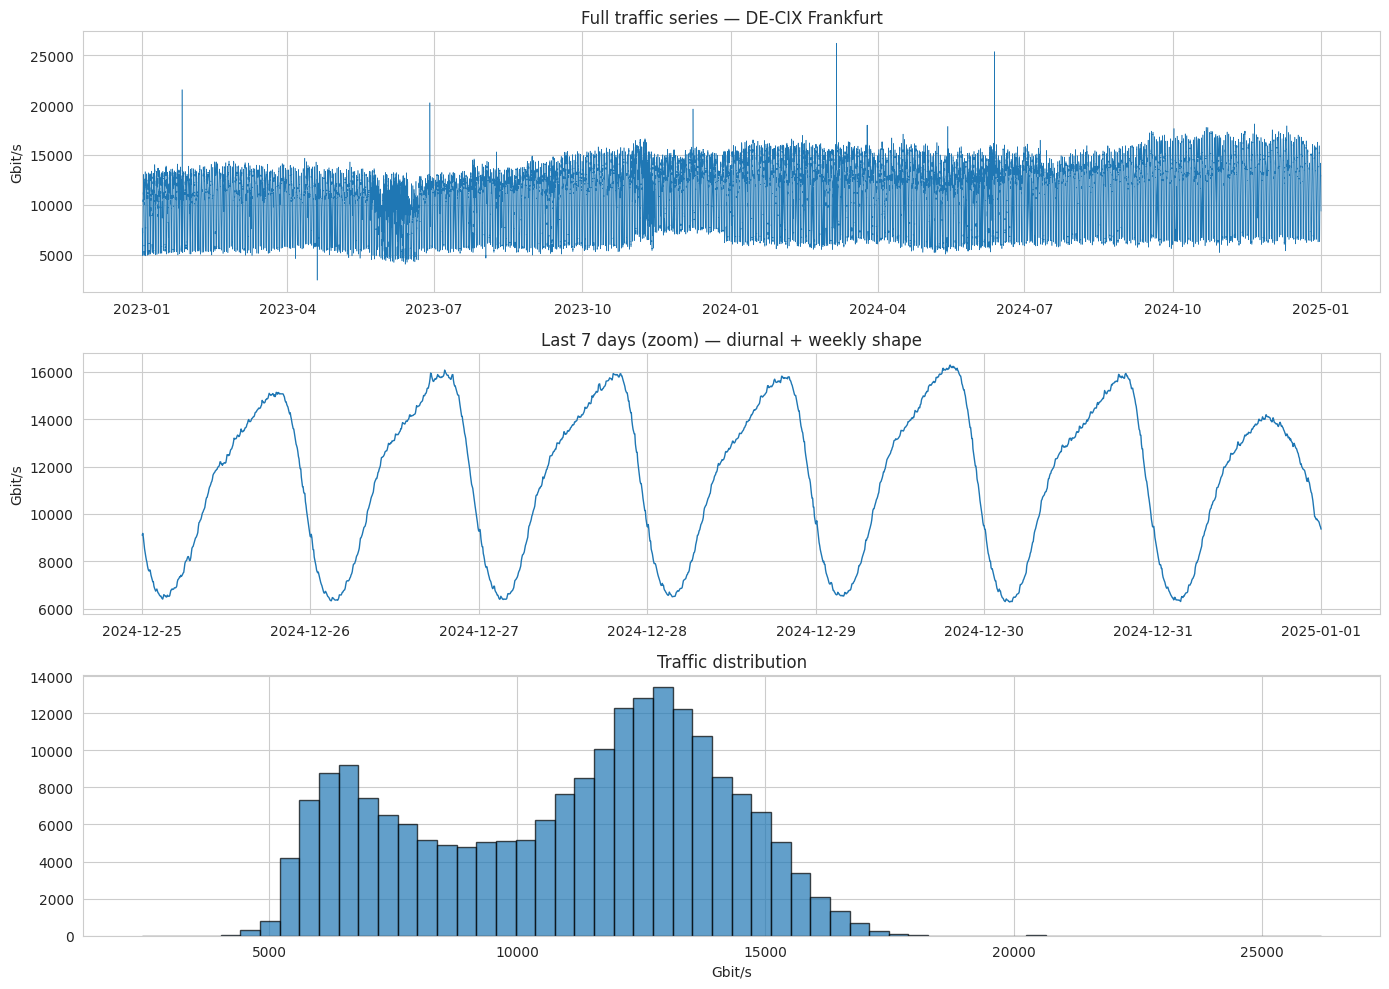

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_style("whitegrid")

# Representative IXP = the one with the highest average traffic
avg_by_ixp = df_EU_timeseries.groupby(["index", "name"])["traffic_gbps"].mean()
rep_index, rep_name = avg_by_ixp.idxmax()
print(f"Representative IXP: [{rep_index}] {rep_name}  (mean = {avg_by_ixp.max():.1f} Gbit/s)")

rep = (df_EU_timeseries[df_EU_timeseries["index"] == rep_index]
       .set_index("human_time").sort_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(rep.index, rep["traffic_gbps"], linewidth=0.4)
axes[0].set_title(f"Full traffic series — {rep_name}"); axes[0].set_ylabel("Gbit/s")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# last 7 days at 5-min cadence
one_week = rep.iloc[-7*24*12:]
axes[1].plot(one_week.index, one_week["traffic_gbps"], linewidth=1)
axes[1].set_title("Last 7 days (zoom) — diurnal + weekly shape"); axes[1].set_ylabel("Gbit/s")

axes[2].hist(rep["traffic_gbps"].dropna(), bins=60, edgecolor="k", alpha=0.7)
axes[2].set_title("Traffic distribution"); axes[2].set_xlabel("Gbit/s")
plt.tight_layout(); plt.show()

The representative IXP is DE-CIX Frankfurt (mean around 10,940 Gbit/s), one of the largest European IXPs.

Over the full two years the series shows a clear regular oscillation with a mild upward trend: the baseline rises from about 10-11 Tbit/s in early 2023 to 13-14 Tbit/s by late 2024, with daily peaks reaching 16 Tbit/s. A handful of isolated spikes up to 20-25 Tbit/s stand out as likely measurement glitches, and will be handled as outliers in S2.

The one-week zoom shows a very clean diurnal cycle, with troughs of 6-7 Tbit/s in the early morning and peaks of about 16 Tbit/s in the evening (roughly 2.3x amplitude). Weekends have a slightly lower peak but the same shape, so the weekly effect is mild.

The distribution is clearly bimodal, with a low-traffic mode (6-7 Tbit/s, night) and a high-traffic mode (12-13 Tbit/s, day) that match the night/day regimes seen in the zoom; the thin right tail reflects the rare spikes.

Overall, the models will need to capture a strong daily seasonality plus a slow trend.

## **S1.4 Diurnal & weekly seasonality**

To see seasonality at the *regional* level we average over all Europe IXPs. Each IXP is
first normalized by its own mean, so the average reflects the **shape** of the daily/weekly
cycle and is not dominated by the few largest IXPs.

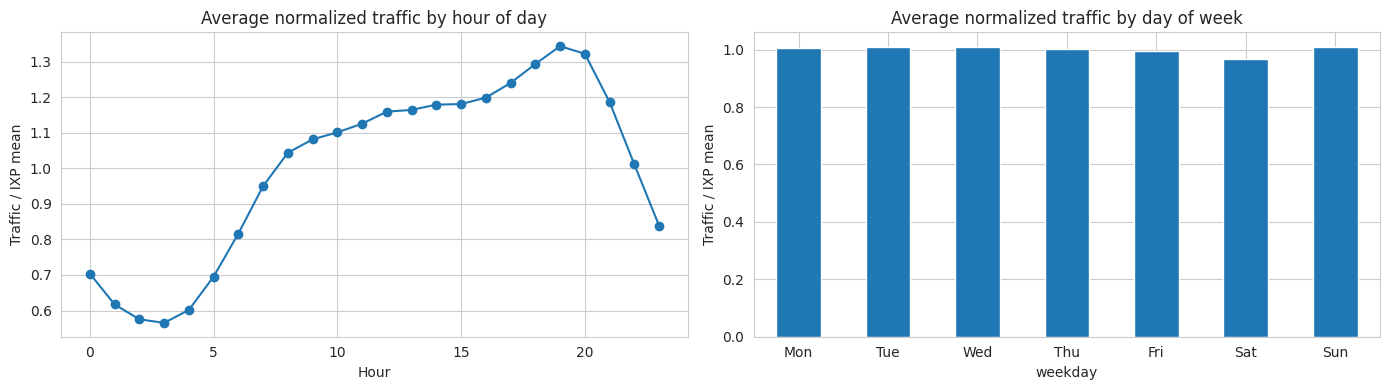

Clear diurnal (day/night) and weekly (weekday/weekend) seasonality → models must capture it.


In [11]:
tmp = df_EU_timeseries[["human_time", "index", "traffic_gbps"]].copy()
tmp["hour"]    = tmp["human_time"].dt.hour
tmp["weekday"] = tmp["human_time"].dt.weekday

# normalize each IXP by its own mean so shapes are comparable across IXPs
tmp["traffic_norm"] = tmp["traffic_gbps"] / tmp.groupby("index")["traffic_gbps"].transform("mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tmp.groupby("hour")["traffic_norm"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Average normalized traffic by hour of day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Traffic / IXP mean")

tmp.groupby("weekday")["traffic_norm"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average normalized traffic by day of week")
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
axes[1].set_ylabel("Traffic / IXP mean")
plt.tight_layout(); plt.show()
print("Clear diurnal (day/night) and weekly (weekday/weekend) seasonality → models must capture it.")

Averaging over all Europe IXPs (each normalized by its own mean) isolates the shape of the seasonality at the regional level.

The hourly profile confirms a pronounced daily cycle: traffic bottoms out around 03:00-04:00 (about 0.57 times the mean) and peaks around 19:00-20:00 (about 1.34 times the mean), so the evening carries roughly 2.3 times the night traffic. The weekday profile is instead almost flat, with all bars close to 1.0 and only Saturday marginally lower (about 0.97).

In short, daily seasonality dominates while the weekly effect is weak. This is useful for the model design: a lookback window covering at least one full day (N >= 288) lets the models see the dominant cycle, while day-of-week features would add little.

## **S1.5 Data quality & missing-sample analysis**

The dataset reports 5-minute samples for only ~88% of IXPs, so series are not guaranteed
to be regular. Per IXP we quantify completeness (missing fraction vs. the expected 5-min
grid), sampling regularity, duplicate timestamps, and the largest gap. This motivates the
cleaning/regularization in S2.


Per-IXP data-quality summary (Europe):


,samples,expected_5min,missing_frac,duplicate_ts,regular_5min_frac,largest_gap_h
count,133.000,133.0,133.000,133.000,133.000,133.000
mean,210536.045,210529.0,-0.000,7.045,1.000,0.083
std,16.356,0.0,0.000,16.356,0.000,0.000
min,210529.000,210529.0,-0.001,0.000,0.999,0.083
25%,210529.000,210529.0,-0.000,0.000,1.000,0.083
50%,210529.000,210529.0,0.000,0.000,1.000,0.083
75%,210533.000,210529.0,0.000,4.000,1.000,0.083
max,210636.000,210529.0,0.000,107.000,1.000,0.083


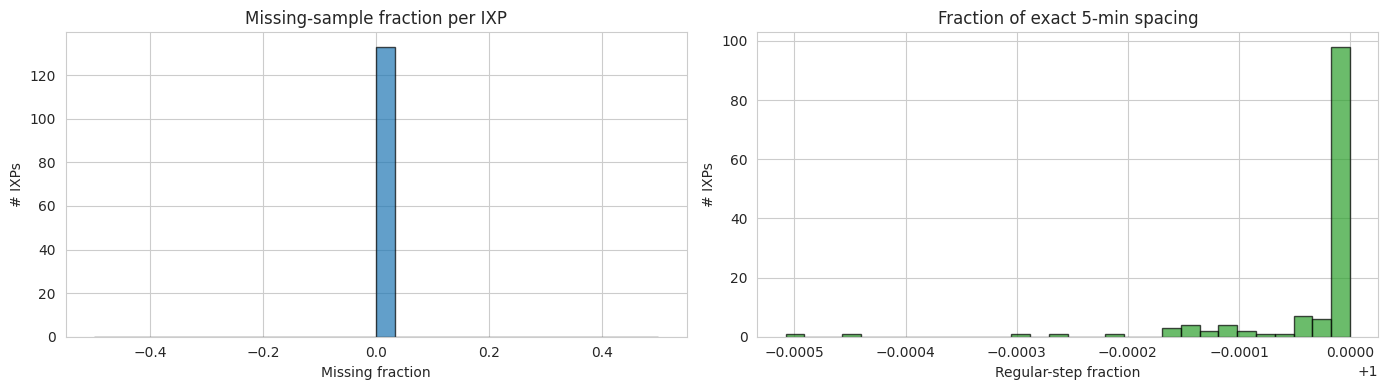

In [12]:
STEP = pd.Timedelta("5min")

# Per-IXP quality stats: completeness vs the expected 5-min grid,
# duplicate timestamps, fraction of exact 5-min steps and largest gap.
def ixp_quality(g):
    idx = pd.DatetimeIndex(g["human_time"]).sort_values()
    span = idx.max() - idx.min()
    expected = int(span / STEP) + 1
    actual = len(idx)
    deltas = idx.to_series().diff().dropna()
    return pd.Series({
        "samples":           actual,
        "expected_5min":     expected,
        "missing_frac":      1 - actual / expected if expected else np.nan,
        "duplicate_ts":      int(idx.duplicated().sum()),
        "regular_5min_frac": float((deltas == STEP).mean()) if len(deltas) else 0.0,
        "largest_gap_h":     deltas.max().total_seconds()/3600 if len(deltas) else 0.0,
    })

quality = df_EU_timeseries.groupby(["index", "name"])[["human_time"]].apply(ixp_quality)
print("Per-IXP data-quality summary (Europe):")
display(quality.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(quality["missing_frac"].clip(0, 1), bins=30, edgecolor="k", alpha=0.7)
axes[0].set_title("Missing-sample fraction per IXP"); axes[0].set_xlabel("Missing fraction"); axes[0].set_ylabel("# IXPs")
axes[1].hist(quality["regular_5min_frac"], bins=30, color="tab:green", edgecolor="k", alpha=0.7)
axes[1].set_title("Fraction of exact 5-min spacing"); axes[1].set_xlabel("Regular-step fraction"); axes[1].set_ylabel("# IXPs")
plt.tight_layout(); plt.show()

The Europe subset turns out to be very clean and regular. Every IXP has about 210,529 expected 5-minute samples with a missing fraction of essentially zero (the tiny negative values come from a few duplicate timestamps inflating the count slightly above the expected total). The regular_5min_frac is 1.000 for all IXPs (min 0.999) and the largest gap is 0.083 h, i.e. exactly 5 minutes: there are no real gaps, just the normal one-step spacing. The only artefact is a small number of duplicate timestamps (on average about 7 per IXP, with a maximum of 107 on a couple of them).

For S2 this means no heavy gap-filling is needed: cleaning reduces to collapsing duplicate timestamps and snapping the series to a strict 5-minute grid, which is what regularize_series does. Spike removal can stay conservative.


## **S1.6 Stationarity & autocorrelation**

ARIMA requires a (weakly) stationary input, so we run an Augmented Dickey-Fuller test on the
Europe aggregate (raw level vs. 1st difference) and inspect ACF/PACF to guide (p, d, q).
A strong peak at lag 288 (= one day at 5-min) confirms daily seasonality, which the neural
models must also capture. *(This uses an EDA-only aggregate; the official cleaned series is
produced in S2.)*


Augmented Dickey-Fuller test (Europe aggregate, last 20k points):
Raw level        ADF= -19.267  p=0.0000  -> stationary
1st difference   ADF= -20.944  p=0.0000  -> stationary


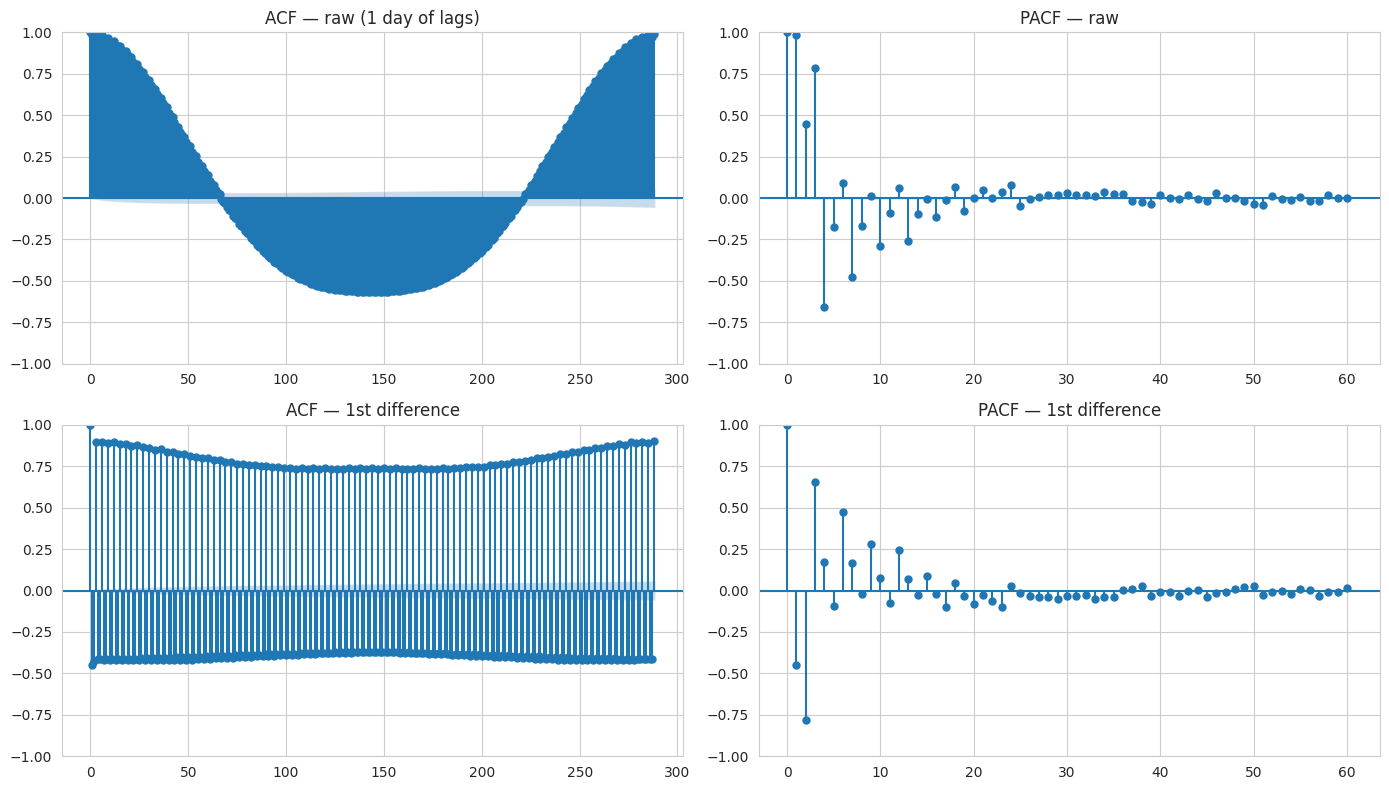

Peak at lag 288 (= 1 day) → daily seasonality; use differencing / seasonal terms for ARIMA.


In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

europe_series_eda = (
    df_EU_timeseries.groupby("human_time")["traffic_gbps"].sum().sort_index()
    .resample("5min").mean().interpolate("time", limit=6).dropna()
)

def adf_summary(x, label):
    stat, pval = adfuller(x, autolag="AIC")[:2]
    print(f"{label:16s} ADF={stat:8.3f}  p={pval:.4f}  -> "
          f"{'stationary' if pval < 0.05 else 'NON-stationary'}")

print("Augmented Dickey-Fuller test (Europe aggregate, last 20k points):")
adf_summary(europe_series_eda.values[-20000:],                 "Raw level")
adf_summary(europe_series_eda.diff().dropna().values[-20000:], "1st difference")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(europe_series_eda.values,                  lags=288, ax=axes[0,0]); axes[0,0].set_title("ACF — raw (1 day of lags)")
plot_pacf(europe_series_eda.values,                 lags=60,  ax=axes[0,1], method="ywm"); axes[0,1].set_title("PACF — raw")
plot_acf(europe_series_eda.diff().dropna().values,  lags=288, ax=axes[1,0]); axes[1,0].set_title("ACF — 1st difference")
plot_pacf(europe_series_eda.diff().dropna().values, lags=60,  ax=axes[1,1], method="ywm"); axes[1,1].set_title("PACF — 1st difference")
plt.tight_layout(); plt.show()
print("Peak at lag 288 (= 1 day) → daily seasonality; use differencing / seasonal terms for ARIMA.")

On the Europe aggregate, the ADF test flags both the raw level (p = 0.000) and the first difference (p = 0.000) as stationary: the strong daily cycle is mean-reverting, so there is no unit root to remove.

The ACF of the raw series is a smooth sinusoid with a period of 288 lags (one day): strongly positive at short lags, dipping to about -0.6 around lag 144 (half a day) and coming back towards +1 at 288, which is textbook daily seasonality. The PACF shows large spikes on the first few lags (1-3) and a marked negative lobe around lags 4-7 followed by a quick decay, pointing to a short autoregressive component on top of the seasonal structure. After first differencing, the 288-lag periodic pattern is still clearly visible, so plain (non-seasonal) differencing does not remove the daily cycle.

For ARIMA this means the series does not need ordinary differencing, but it is dominated by a seasonal period of 288. A plain ARIMA will struggle here: the options are seasonal handling (SARIMA with s = 288 or seasonal differencing, both computationally heavy with such a large period, or Fourier/seasonal-dummy regressors) or relying on the neural models with a lookback N >= 288 so that they see a full daily cycle. This directly motivates the N values (12 / 72 / 288) used in the sensitivity analysis.

## **S1.7 Save Raw Europe Dataset**
Save the full long-format table (one row per IXP per 5-minute timestamp, ~28M rows) to a Parquet file on Drive.

This is a **checkpoint**: it lets later runs reload the assembled dataset directly, skipping the slow
PeeringDB fetch and the per-profile loading in the cells above.

*Standardization and sliding-window construction (past **N** → next **K**) are deferred to S3, where they are fitted on the training split only to avoid data leakage.*


In [14]:
# Save the raw Europe dataset to Drive (skip if already cached).
if EUROPE_RAW_PROFILES_FILE_PATH.exists():
    print(f"Already cached on Drive -> skipping save: {EUROPE_RAW_PROFILES_FILE_PATH}")
else:
    df_EU_timeseries.to_parquet(
        EUROPE_RAW_PROFILES_FILE_PATH,
        index=False,
        engine="pyarrow",
    )
    print(f"Saved: {EUROPE_RAW_PROFILES_FILE_PATH}")


Already cached on Drive -> skipping save: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/df_EU_timeseries.parquet


# **S2 - Data Preprocessing**
 Clean and regularize the raw data onto a strict 5-minute grid: aggregate the Europe region into a single series, collapse duplicate timestamps, handle gaps and outliers, then apply the chronological 70/15/15 train/validation/test split and persist everything to Drive.


## **S2.1 Reload the Raw Europe Dataset from Drive**
Read `df_EU_timeseries` back from the Parquet file
just written. From here on the pipeline runs from this cached copy, so the data-loading cells above
do not need to be re-executed in future sessions.

In [15]:
# Load Raw Europe Dataset from Drive.
df_EU_timeseries = pd.read_parquet(
    EUROPE_RAW_PROFILES_FILE_PATH,
    columns=["human_time", "traffic_gbps"],
)
df_EU_timeseries["human_time"] = pd.to_datetime(df_EU_timeseries["human_time"])

# Print first dataset rows
df_EU_timeseries.head()


,human_time,traffic_gbps
0,2023-01-01 00:00:00,395.801337
1,2023-01-01 00:05:00,388.864992
2,2023-01-01 00:10:00,420.042754
3,2023-01-01 00:15:00,392.343601
4,2023-01-01 00:20:00,409.525620


## **S2.2 Cleaning & regularization**

Before splitting and modelling, we turn the raw per-IXP measurements into a single clean, regularly-sampled regional series. The steps are:

1. aggregate the Europe region by summing traffic_gbps across all IXPs per timestamp;
2. regularize onto a strict 5-minute grid (resample("5min")), collapsing duplicate timestamps;
3. interpolate short gaps (up to FILL_LIMIT steps) and drop the rest;
4. flag extreme spikes with a robust rolling median +/- k*MAD rule, kept conservative so that real traffic surges are not removed.

Two helper functions implement this: regularize_series (steps 2-4 on a single series, returning a small cleaning report) and build_clean_europe_aggregate (step 1 plus the regularization of the aggregate).

These operations are applied to the whole series before the split: they are structural and local, they do not learn parameters from the data, so they cannot leak information from test into train.


In [16]:
# ==========================
# CLEANING & REGULARIZATION
# ==========================

# interpolate gaps up to 6 steps (= 30 min)
FILL_LIMIT = 6

# robust spike threshold: |x - median| > SPIKE_K * MAD (high => conservative)
SPIKE_K    = 12.0

# rolling window (steps) for the robust median/MAD
SPIKE_WIN  = 25

# regularize and clean a datetime series
def regularize_series(s, fill_limit=FILL_LIMIT, spike_k=SPIKE_K,
                      spike_win=SPIKE_WIN, remove_spikes=True, return_report=False):
    report = {}
    s = s.sort_index()
    report["raw_points"] = len(s)
    report["duplicates_collapsed"] = int(s.index.duplicated().sum())
    s = s[~s.index.duplicated(keep="first")]

    s = s.resample("5min").mean()
    report["grid_points"] = len(s)
    report["empty_bins"] = int(s.isna().sum())

    report["negatives_removed"] = int((s < 0).sum())
    s[s < 0] = np.nan

    n_spikes = 0
    if remove_spikes:
        med = s.rolling(spike_win, center=True, min_periods=1).median()
        mad = (s - med).abs().rolling(spike_win, center=True, min_periods=1).median()
        spikes = ((s - med).abs() > spike_k * mad.replace(0, np.nan)).fillna(False)
        n_spikes = int(spikes.sum())
        s[spikes] = np.nan
    report["spikes_removed"] = n_spikes

    na_before = int(s.isna().sum())
    s = s.interpolate(method="time", limit=fill_limit)
    report["interpolated"] = na_before - int(s.isna().sum())
    report["dropped"] = int(s.isna().sum())
    s = s.dropna()
    report["final_points"] = len(s)

    return (s, report) if return_report else s

# Sum traffic across all European IXPs per timestamp
def build_clean_europe_aggregate(df_long, verbose=True):
    agg = df_long.groupby("human_time")["traffic_gbps"].sum().sort_index()
    clean, report = regularize_series(agg, return_report=True)
    if verbose:
        print("Cleaning and regularization report (Europe aggregate)")
        for k, v in report.items():
            print(f"  {k:22s}: {v:,}")
        print(f"  period                : {clean.index.min()}  ->  {clean.index.max()}")
    return clean.to_frame(name="traffic_gbps")

In [17]:
#build the regional series
europe_aggregated = build_clean_europe_aggregate(df_EU_timeseries)
print("\nShape:", europe_aggregated.shape)
display(europe_aggregated["traffic_gbps"].describe().round(1))
europe_aggregated.head()

Cleaning and regularization report (Europe aggregate)
  raw_points            : 210,529
  duplicates_collapsed  : 0
  grid_points           : 210,529
  empty_bins            : 0
  negatives_removed     : 0
  spikes_removed        : 151
  interpolated          : 151
  dropped               : 0
  final_points          : 210,529
  period                : 2023-01-01 00:00:00  ->  2025-01-01 00:00:00

Shape: (210529, 1)


,traffic_gbps
count,210529.0
mean,66519.5
std,20365.2
min,26763.9
25%,47843.6
50%,70573.1
75%,82187.7
max,117610.6


,traffic_gbps
human_time,
2023-01-01 00:00:00,52117.246420
2023-01-01 00:05:00,52900.231947
2023-01-01 00:10:00,49768.480857
2023-01-01 00:15:00,50012.499445
2023-01-01 00:20:00,51267.815866


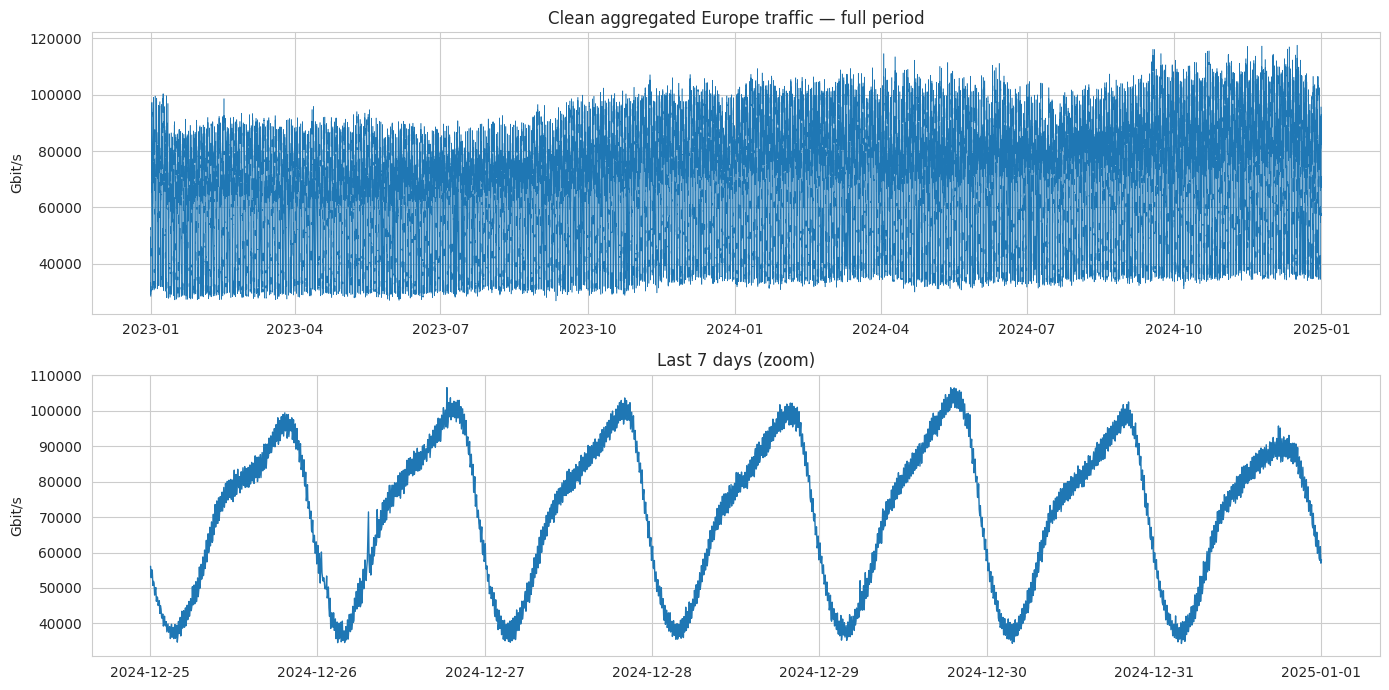

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#visualize the clean regional serie
s = europe_aggregated["traffic_gbps"]
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(s.index, s.values, linewidth=0.4)
axes[0].set_title("Clean aggregated Europe traffic — full period"); axes[0].set_ylabel("Gbit/s")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# last 7 days at 5-min cadence
wk = s.iloc[-7*24*12:]
axes[1].plot(wk.index, wk.values, linewidth=1)
axes[1].set_title("Last 7 days (zoom)"); axes[1].set_ylabel("Gbit/s")
plt.tight_layout(); plt.show()

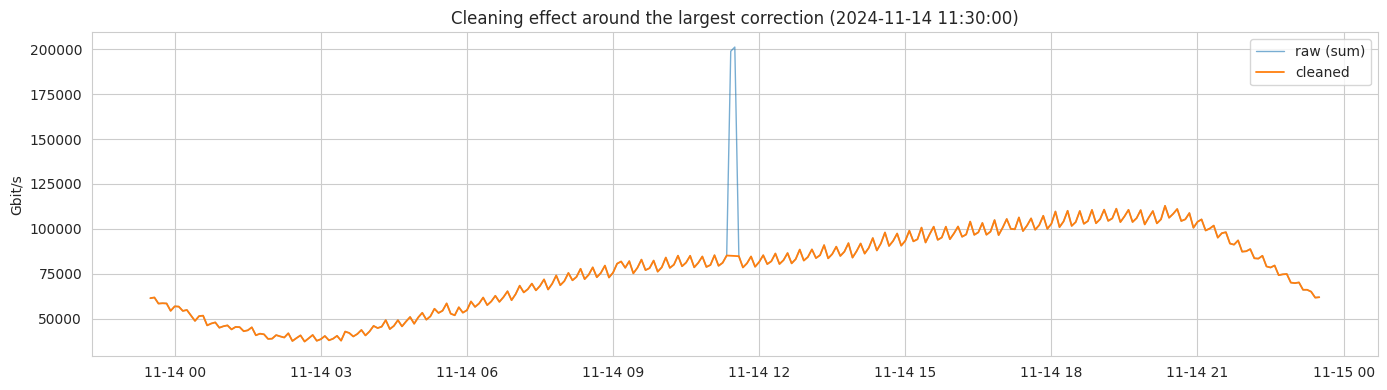

Largest single-point correction: 116338.2 Gbit/s at 2024-11-14 11:30:00


In [19]:
# plot raw vs cleaned aggregate around the largest correction
raw_agg   = (df_EU_timeseries.groupby("human_time")["traffic_gbps"].sum()
             .sort_index().resample("5min").mean())
clean_agg = europe_aggregated["traffic_gbps"]

diff = (raw_agg.reindex(clean_agg.index) - clean_agg).abs()
if diff.max() and diff.max() > 1e-6:
    center = diff.idxmax()
    win = slice(center - pd.Timedelta("12h"), center + pd.Timedelta("12h"))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(raw_agg[win].index, raw_agg[win].values, label="raw (sum)", alpha=0.6, linewidth=1)
    ax.plot(clean_agg[win].index, clean_agg[win].values, label="cleaned", linewidth=1.3)
    ax.set_title(f"Cleaning effect around the largest correction ({center})")
    ax.set_ylabel("Gbit/s"); ax.legend(); plt.tight_layout(); plt.show()
    print(f"Largest single-point correction: {diff.max():.1f} Gbit/s at {center}")
else:
    print("No meaningful corrections: the aggregate had no spikes/outliers to clean.")

## **S2.3 Chronological Dataset split (train / validation / test)**

Time-series forecasting requires a chronological split (never random): the model is trained on
the past and evaluated on the future, so test data must come strictly *after* training data.

In [20]:
#label each timestamp as train/validation or test
def assign_chronological_split_to_series(df, split_column="temporal_split",
                                         train_ratio=TRAIN_RATIO,
                                         validation_ratio=VALIDATION_RATIO):
    df = df.sort_index().copy()
    n = len(df)
    train_end      = int(n * train_ratio)
    validation_end = int(n * (train_ratio + validation_ratio))

    df[split_column] = "test"
    df.iloc[:train_end,             df.columns.get_loc(split_column)] = "train"
    df.iloc[train_end:validation_end, df.columns.get_loc(split_column)] = "validation"

    print(df[split_column].value_counts(), "\n")
    for name in ["train", "validation", "test"]:
        seg = df[df[split_column] == name]
        print(f"{name.capitalize():10s}: {seg.index.min()}  ->  {seg.index.max()}")
    return df

In [21]:
# Clean, regularly-sampled Europe aggregate (replaces the naive .sum())
europe_aggregated = assign_chronological_split_to_series(europe_aggregated)
europe_aggregated.head()

temporal_split
train         147370
test           31580
validation     31579
Name: count, dtype: int64 

Train     : 2023-01-01 00:00:00  ->  2024-05-26 16:45:00
Validation: 2024-05-26 16:50:00  ->  2024-09-13 08:20:00
Test      : 2024-09-13 08:25:00  ->  2025-01-01 00:00:00


,traffic_gbps,temporal_split
human_time,,
2023-01-01 00:00:00,52117.246420,train
2023-01-01 00:05:00,52900.231947,train
2023-01-01 00:10:00,49768.480857,train
2023-01-01 00:15:00,50012.499445,train
2023-01-01 00:20:00,51267.815866,train


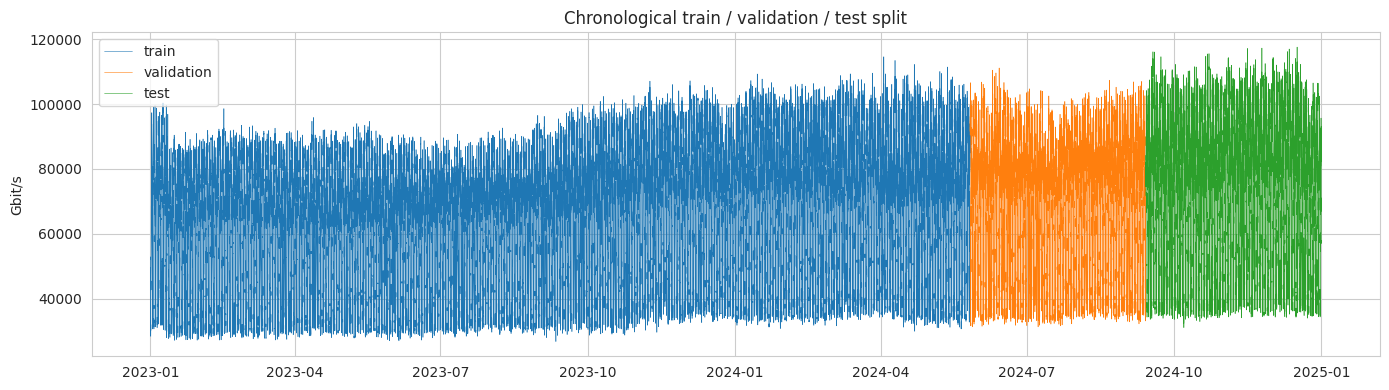

,count,mean,std,min,max
temporal_split,,,,,
test,31580,73144.0,21635.4,31053.8,117610.6
train,147370,64605.4,19862.1,26763.9,114618.6
validation,31579,68827.6,19737.3,31288.0,111163.8


In [22]:
#visualize the split and compare the distribution
fig, ax = plt.subplots(figsize=(14, 4))
colors = {"train": "tab:blue", "validation": "tab:orange", "test": "tab:green"}
for name, c in colors.items():
    seg = europe_aggregated[europe_aggregated["temporal_split"] == name]
    ax.plot(seg.index, seg["traffic_gbps"], color=c, linewidth=0.4, label=name)
ax.set_title("Chronological train / validation / test split")
ax.set_ylabel("Gbit/s"); ax.legend(); plt.tight_layout(); plt.show()

display(europe_aggregated.groupby("temporal_split")["traffic_gbps"]
        .agg(["count", "mean", "std", "min", "max"]).round(1))

## **S2.4 Save the splits to Drive**

Persist the full labelled series and the three splits as Parquet files, so S3/S4/S5 can reload them
directly without re-running S1–S2. The shapes are printed as a final sanity check.

In [23]:
europe_train      = europe_aggregated[europe_aggregated["temporal_split"] == "train"]
europe_validation = europe_aggregated[europe_aggregated["temporal_split"] == "validation"]
europe_test       = europe_aggregated[europe_aggregated["temporal_split"] == "test"]

europe_train.to_parquet(DATA_DIR / "europe_aggregated_train.parquet")
europe_validation.to_parquet(DATA_DIR / "europe_aggregated_validation.parquet")
europe_test.to_parquet(DATA_DIR / "europe_aggregated_test.parquet")
europe_aggregated.to_parquet(EUROPE_AGGREGATED_SERIES_FILE_PATH)

print("Full:      ", europe_aggregated.shape)
print("Train:     ", europe_train.shape)
print("Validation:", europe_validation.shape)
print("Test:      ", europe_test.shape)
print("\nSaved:")
for p in [EUROPE_AGGREGATED_SERIES_FILE_PATH,
          DATA_DIR / "europe_aggregated_train.parquet",
          DATA_DIR / "europe_aggregated_validation.parquet",
          DATA_DIR / "europe_aggregated_test.parquet"]:
    print(" ", p)

Full:       (210529, 2)
Train:      (147370, 2)
Validation: (31579, 2)
Test:       (31580, 2)

Saved:
  /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/europe_aggregated_5min.parquet
  /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/europe_aggregated_train.parquet
  /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/europe_aggregated_validation.parquet
  /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/europe_aggregated_test.parquet


In [24]:
# Verify the saved file: reload it from Drive and inspect the first rows.
pd.read_parquet(EUROPE_AGGREGATED_SERIES_FILE_PATH).head(1000000,)

,traffic_gbps,temporal_split
human_time,,
2023-01-01 00:00:00,52117.246420,train
2023-01-01 00:05:00,52900.231947,train
2023-01-01 00:10:00,49768.480857,train
2023-01-01 00:15:00,50012.499445,train
2023-01-01 00:20:00,51267.815866,train
...,...,...
2024-12-31 23:40:00,58374.794735,test
2024-12-31 23:45:00,57822.825047,test
2024-12-31 23:50:00,61647.667097,test


# **S3 - Forecasting Setup**

This section prepares the shared forecasting setup used by every model trained later (Random Forest, LSTM, GRU, ARIMA, TSFM).


In [15]:
# ========================
# IMPORTS
# ========================

import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## **S3.1 - Reproducibility**

We fix the random seeds (Python, NumPy, PyTorch, CUDA) and force deterministic cuDNN kernels to make the experiments reproducible across runs. If a GPU is available, neural-network training is performed on CUDA.

In [16]:
# ========================
# REPRODUCIBILITY
# ========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Make cuDNN deterministic: results are reproducible across runs
# at the cost of slightly slower training.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cuda


## **S3.2 - Forecasting configuration**

The baseline forecasting setup uses 6 hours of past traffic to predict the next hour. Since the dataset is sampled every 5 minutes:

  - N_LOOKBACK = 72 corresponds to 6 hours;
  - K_HORIZON = 12 corresponds to 1 hour.

  Both values follow from the analysis in S1.6: the ACF of the Europe aggregate remains strongly positive for the first 50-75 lags (4-8 hours) before crossing zero near lag 75. A 6-hour lookback therefore captures the bulk of the short-term autocorrelation without extending into the negative phase of the diurnal cycle, while a 1-hour horizon is a natural granularity for network capacity planning.

  N_LOOKBACK and K_HORIZON define the baseline configuration used for the main model comparison. The sensitivity analysis in S4 instead explores the full grid given by N_VALUES = [12, 72, 288] (1 h, 6 h, 24 h) and K_VALUES = [1, 12, 36] (5 min, 1 h, 3 h), spanning from short-term reactivity (N = 12) up to a full diurnal cycle (N = 288), and from one-step prediction (K = 1) up to a 3-hour horizon (K = 36).

  Finally, adjacent sliding windows overlap almost entirely: shifting by one step only adds one new sample and drops one old one. Training on every third window (TRAIN_STRIDE = 3) cuts the training samples by a factor of 3, shortening fit time without meaningful information loss.

In [17]:
# ==========================
# FORECASTING CONFIGURATION
# ==========================

N_LOOKBACK = 72
K_HORIZON = 12

# Use every 3rd sliding window for training to reduce overlap and training time.
TRAIN_STRIDE = 3

# Number of training samples processed together in each optimization step.
BATCH_SIZE = 256

# 1 hour, 6 hours, 24 hours
N_VALUES = [12, 72, 288]

# 5 minutes, 1 hour, 3 hours
K_VALUES = [1, 12, 36]

## **S3.3 - Load aggregated Europe traffic series**

The models are trained on the aggregated European traffic series, not directly on the raw 28M-row dataframe. The raw profiles are used to build the aggregated regional series.

In [18]:
# ===============================
# LOAD AGGREAGATED EUROPE SERIES
# ===============================

europe_aggregated = pd.read_parquet(
    EUROPE_AGGREGATED_SERIES_FILE_PATH
)

if "human_time" in europe_aggregated.columns:
    europe_aggregated["human_time"] = pd.to_datetime(
        europe_aggregated["human_time"]
    )
    europe_aggregated = europe_aggregated.set_index("human_time")

europe_aggregated = europe_aggregated.sort_index()

print("Aggregated Europe shape:", europe_aggregated.shape)
display(europe_aggregated.head())
display(europe_aggregated["temporal_split"].value_counts())

Aggregated Europe shape: (210529, 2)


,traffic_gbps,temporal_split
human_time,,
2023-01-01 00:00:00,52117.246420,train
2023-01-01 00:05:00,52900.231947,train
2023-01-01 00:10:00,49768.480857,train
2023-01-01 00:15:00,50012.499445,train
2023-01-01 00:20:00,51267.815866,train


,count
temporal_split,
train,147370
test,31580
validation,31579


## **S3.4 - Extract train, validation and test splits**

The chronological split was created during preprocessing. We reuse it here to avoid temporal leakage.

In [19]:
# =============================
# EXTRACT CHRONOLOGICAL SPLITS
# =============================

train_raw = europe_aggregated[
    europe_aggregated["temporal_split"] == "train"
]["traffic_gbps"].to_numpy(np.float32)

validation_raw = europe_aggregated[
    europe_aggregated["temporal_split"] == "validation"
]["traffic_gbps"].to_numpy(np.float32)

test_raw = europe_aggregated[
    europe_aggregated["temporal_split"] == "test"
]["traffic_gbps"].to_numpy(np.float32)

print("Train:", train_raw.shape)
print("Validation:", validation_raw.shape)
print("Test:", test_raw.shape)

Train: (147370,)
Validation: (31579,)
Test: (31580,)


## **S3.5 - Standardization**

The scaler is fitted only on the training data to avoid data leakage. The same transformation is then applied to validation and test data.

In [20]:
# ========================
# STANDARDIZATION
# ========================

class Standardizer:
    def fit(self, values):
        self.mean = float(np.mean(values))
        self.std = max(float(np.std(values)), 1e-8)
        return self

    def transform(self, values):
        return (values - self.mean) / self.std

    def inverse(self, values):
        return values * self.std + self.mean

#only on training set
scaler = Standardizer().fit(train_raw)

train_scaled = scaler.transform(train_raw)
validation_scaled = scaler.transform(validation_raw)
test_scaled = scaler.transform(test_raw)

print("Train mean:", scaler.mean)
print("Train std:", scaler.std)

Train mean: 64605.4140625
Train std: 19862.015625


## **S3.6 - Sliding-window construction**

Each model receives the previous `N` traffic values and predicts the next `K` values.

In [21]:
# ========================
# SLIDING WINDOWS
# ========================

def make_windows(values, n_lookback, k_horizon, stride=1):
    X = []
    Y = []

    # Last valid starting index
    # We need enough values for both the input window and the future target.
    last_start = len(values) - n_lookback - k_horizon

    # Slide the window over the time series.
    # "stride" controls how many time steps we move forward each time.
    for start in range(0, last_start + 1, stride):

        #Input window
        X.append(values[start : start + n_lookback])

        #Target window
        Y.append(values[start + n_lookback : start + n_lookback + k_horizon])

    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.float32)

# Create training windows from the standardized training series.
# TRAIN_STRIDE reduces overlap between consecutive training examples.
X_train, Y_train = make_windows(
    train_scaled,
    N_LOOKBACK,
    K_HORIZON,
    stride=TRAIN_STRIDE
)

X_validation, Y_validation = make_windows(
    validation_scaled,
    N_LOOKBACK,
    K_HORIZON,
    stride=K_HORIZON
)

X_test, Y_test = make_windows(
    test_scaled,
    N_LOOKBACK,
    K_HORIZON,
    stride=K_HORIZON
)

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_validation.shape, Y_validation.shape)
print("Test:", X_test.shape, Y_test.shape)

Train: (49096, 72) (49096, 12)
Validation: (2625, 72) (2625, 12)
Test: (2625, 72) (2625, 12)


## **S3.7 - Metric function**

All models are evaluated using the same metrics.

In [22]:
# ========================
# EVALUATION METRICS
# ========================

def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-6))
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2

# **S4 - Model Training and Comparison**

We train **one model at a time** on the shared forecasting setup defined in S3, evaluate each on the same held-out test set, and then bring all results together in a final comparison.

The order is:

1. **S4.1** - Random Forest Regressor *(classical ML baseline)*
2. **S4.2** - LSTM *(neural baseline)*
3. **S4.3** - GRU *(lighter recurrent alternative)*
4. **S4.4** - ARIMA *(classical statistical baseline)*
5. **S4.5** - TSFM with Chronos *(pretrained foundation model, zero-shot)*
6. **S4.6** - Final comparison of all five models



### **Sensitivity analysis**

The **full N x K sensitivity grid** (N ∈ {12, 72, 288}, K ∈ {1, 12, 36}) is evaluated for **all five models**:

- **Random Forest**, **LSTM**, and **GRU** are supervised models. For them, changing `N` and `K` changes the training windows and the learned mapping from past context to future horizon.
- **ARIMA** is fit independently inside each test window. For ARIMA, the sweep measures how much the per-window statistical fit benefits from additional context and how quickly its forecast degrades as the horizon grows.
- **Chronos TSFM** is zero-shot. For Chronos, the sweep measures context-length and horizon sensitivity of the pretrained model, not task-specific training behavior.

## **S4.1 - Random Forest Regressor Baseline**




In [ ]:

# ========================
# RF CONFIGURATION
# ========================

# Number of trees in the forest
RF_N_ESTIMATORS = 200

# Maximum depth of each tree.
RF_MAX_DEPTH = None

# Minimum number of samples required in each leaf node.
RF_MIN_SAMPLES_LEAF = 2

# Number of CPU cores used by scikit-learn.
# -1 means using all available cores.
RF_N_JOBS = -1

### **S4.1.1 - Train Random Forest**

The Random Forest is trained on the same windows used later by the LSTM.

In [ ]:
# ========================
# TRAIN RF
# ========================


rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    n_jobs=RF_N_JOBS,
    random_state=SEED,
    verbose=1
)

start_time = time.time()

rf_model.fit(
    X_train,
    Y_train,
)

rf_training_time = time.time() - start_time

print(f"Random Forest training time: {rf_training_time:.2f} seconds")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 16.4min


Random Forest training time: 1003.77 seconds


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 16.7min finished


### **S4.1.2 - Evaluate Random Forest**

Predictions are converted back to Gbit/s before computing the final test metrics.

In [ ]:
# ========================
# EVALUATE RF
# ========================

rf_predictions_scaled = rf_model.predict(X_test)

rf_predictions = scaler.inverse(rf_predictions_scaled)
rf_targets = scaler.inverse(Y_test)

rf_y_pred = rf_predictions.ravel()
rf_y_true = rf_targets.ravel()

rf_mae, rf_rmse, rf_mape, rf_r2 = compute_regression_metrics(
    rf_y_true,
    rf_y_pred
)

print(f"Random Forest MAE  [Gbit/s]: {rf_mae:.2f}")
print(f"Random Forest RMSE [Gbit/s]: {rf_rmse:.2f}")
print(f"Random Forest MAPE [%]:     {rf_mape:.2f}")
print(f"Random Forest R2:           {rf_r2:.4f}")

Random Forest MAE  [Gbit/s]: 3986.08
Random Forest RMSE [Gbit/s]: 5623.59
Random Forest MAPE [%]:     5.26
Random Forest R2:           0.9326


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


### **S4.1.3 - Random Forest forecast visualization**

The first test day is plotted to visually inspect the forecast.

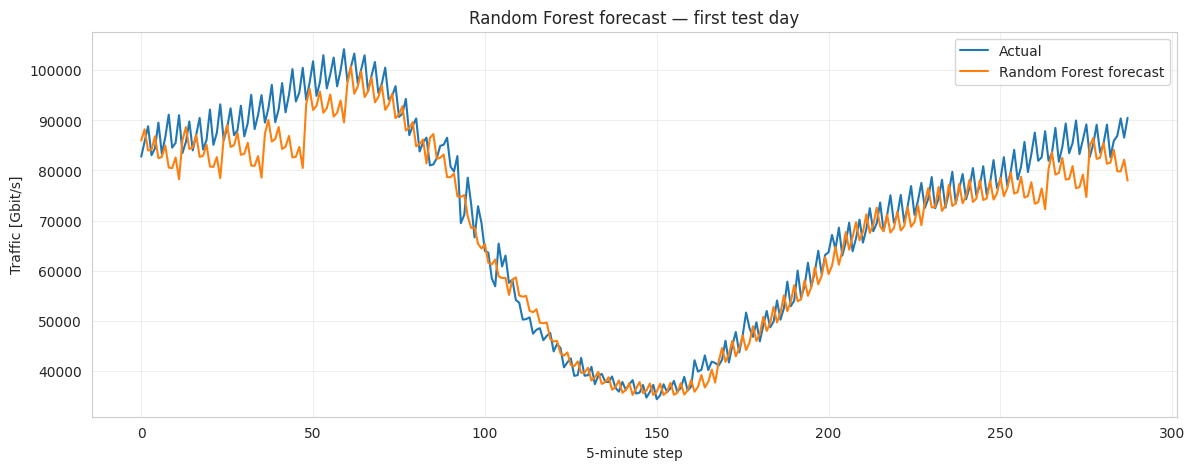

In [ ]:
# ==========================
# RF FORECAST VISUALIZATION
# ==========================

first_day_windows = (24 * 12) // K_HORIZON

plt.figure(figsize=(14, 5))

plt.plot(
    rf_targets[:first_day_windows].ravel(),
    label="Actual"
)

plt.plot(
    rf_predictions[:first_day_windows].ravel(),
    label="Random Forest forecast"
)

plt.title("Random Forest forecast — first test day")
plt.xlabel("5-minute step")
plt.ylabel("Traffic [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### **S4.1.4 - Save Random Forest metrics**

In [ ]:
# ========================
# SAVE RF METRICS
# ========================

rf_metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "N": N_LOOKBACK,
        "K": K_HORIZON,
        "n_estimators": RF_N_ESTIMATORS,
        "max_depth": RF_MAX_DEPTH,
        "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
        "MAE_Gbit_s": rf_mae,
        "RMSE_Gbit_s": rf_rmse,
        "MAPE_percent": rf_mape,
        "R2": rf_r2,
        "training_time_seconds": rf_training_time,
    }
])

display(rf_metrics)

rf_metrics.to_csv(
    DATA_DIR / "random_forest_metrics.csv",
    index=False
)

print("Saved:", DATA_DIR / "random_forest_metrics.csv")

,model,N,K,n_estimators,max_depth,min_samples_leaf,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
0,Random Forest,72,12,200,None,2,3986.082132,5623.592677,5.259206,0.932577,1003.768117


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/random_forest_metrics.csv


### **S4.1.5 - Random Forest sensitivity analysis over N and K**

How the forecasting performance changes with different lookback windows `N` and prediction horizons `K`.


In [ ]:
# ========================
# RF SENSITIVITY ANALYSIS
# ========================

RF_SENSITIVITY_FILE_PATH = DATA_DIR / "random_forest_sensitivity_NK.csv"


def run_rf_experiment(n_lookback, k_horizon, train_stride=3):
    X_train_exp, Y_train_exp = make_windows(
        train_scaled,
        n_lookback,
        k_horizon,
        stride=train_stride
    )

    X_test_exp, Y_test_exp = make_windows(
        test_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    # For K=1, sklearn prefers a 1D target vector.
    # For K>1, we keep the 2D multi-output target.
    if k_horizon == 1:
        Y_train_fit = Y_train_exp.ravel()
    else:
        Y_train_fit = Y_train_exp

    rf_exp = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        n_jobs=RF_N_JOBS,
        random_state=42,
    )

    start = time.time()

    rf_exp.fit(
        X_train_exp,
        Y_train_fit
    )

    exp_training_time = time.time() - start

    predictions_scaled_exp = rf_exp.predict(X_test_exp)

    # For K=1, sklearn returns shape (n_windows,), so we restore 2D shape.
    if k_horizon == 1:
        predictions_scaled_exp = predictions_scaled_exp.reshape(-1, 1)

    predictions_exp = scaler.inverse(predictions_scaled_exp)
    targets_exp = scaler.inverse(Y_test_exp)

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    return {
        "model": "Random Forest",
        "N": n_lookback,
        "K": k_horizon,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": exp_training_time,
        "train_windows": len(X_train_exp),
        "test_windows": len(X_test_exp),
    }


# Load already completed experiments, if the file exists
if RF_SENSITIVITY_FILE_PATH.exists():
    rf_sensitivity = pd.read_csv(RF_SENSITIVITY_FILE_PATH)

    rf_sensitivity_results = rf_sensitivity.to_dict("records")

    completed_pairs = set(
        zip(
            rf_sensitivity["N"].astype(int),
            rf_sensitivity["K"].astype(int)
        )
    )

    print("Loaded previous checkpoint:")
    print(RF_SENSITIVITY_FILE_PATH)
    print("Completed experiments:", completed_pairs)

else:
    rf_sensitivity_results = []
    completed_pairs = set()

    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:
        if (N, K) in completed_pairs:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running RF sensitivity experiment: N={N}, K={K}")

        result = run_rf_experiment(
            n_lookback=N,
            k_horizon=K,
            train_stride=TRAIN_STRIDE,
        )

        rf_sensitivity_results.append(result)
        completed_pairs.add((N, K))

        rf_sensitivity = pd.DataFrame(rf_sensitivity_results)

        # Save immediately after each completed experiment
        rf_sensitivity.to_csv(
            RF_SENSITIVITY_FILE_PATH,
            index=False
        )

        print(result)
        print("Checkpoint saved:", RF_SENSITIVITY_FILE_PATH)


rf_sensitivity = pd.DataFrame(rf_sensitivity_results)

display(rf_sensitivity)

print("Final saved file:", RF_SENSITIVITY_FILE_PATH)

Loaded previous checkpoint:
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/random_forest_sensitivity_NK.csv
Completed experiments: {(72, 12), (12, 1), (12, 36), (288, 12), (72, 1), (72, 36), (12, 12), (288, 1), (288, 36)}
Skipping already completed experiment: N=12, K=1
Skipping already completed experiment: N=12, K=12
Skipping already completed experiment: N=12, K=36
Skipping already completed experiment: N=72, K=1
Skipping already completed experiment: N=72, K=12
Skipping already completed experiment: N=72, K=36
Skipping already completed experiment: N=288, K=1
Skipping already completed experiment: N=288, K=12
Skipping already completed experiment: N=288, K=36


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,train_windows,test_windows
0,Random Forest,12,1,2815.992756,4066.950428,3.836954,0.964677,170.681502,49120,31568
1,Random Forest,12,12,3632.622651,5072.890433,4.892087,0.945050,220.115772,49116,2630
2,Random Forest,12,36,6995.509335,10128.549155,8.697594,0.781101,317.753646,49108,876
3,Random Forest,72,1,2801.073465,4026.258486,3.797560,0.965434,987.403350,49100,31508
4,Random Forest,72,12,3986.082132,5623.592677,5.259206,0.932577,1210.501245,49096,2625
5,Random Forest,72,36,7932.972823,12187.588049,9.588643,0.683324,1753.923070,49088,875
6,Random Forest,288,1,2672.298735,3749.978221,3.653389,0.969983,3950.617872,49028,31292
7,Random Forest,288,12,3214.194500,4201.803474,4.472675,0.962319,4620.736404,49024,2607
8,Random Forest,288,36,3395.001356,4511.346519,4.668188,0.956563,6487.774712,49016,869


Final saved file: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/random_forest_sensitivity_NK.csv


### **S4.1.6 - Random Forest sensitivity visualization**

The heatmap and line plots summarize how the Random Forest error changes with the lookback window `N` and the forecasting horizon `K`.


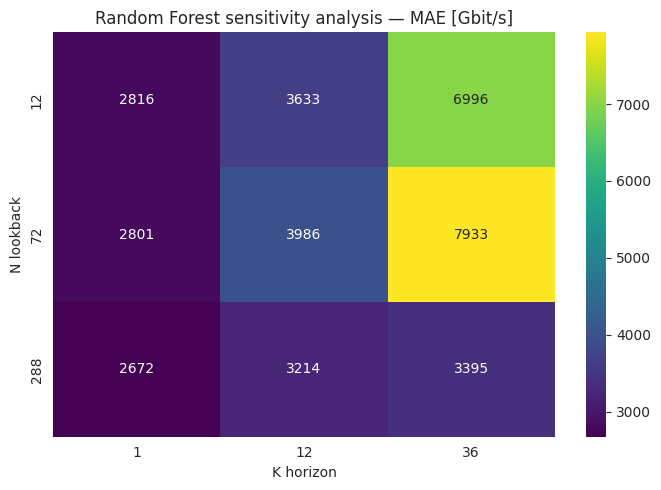

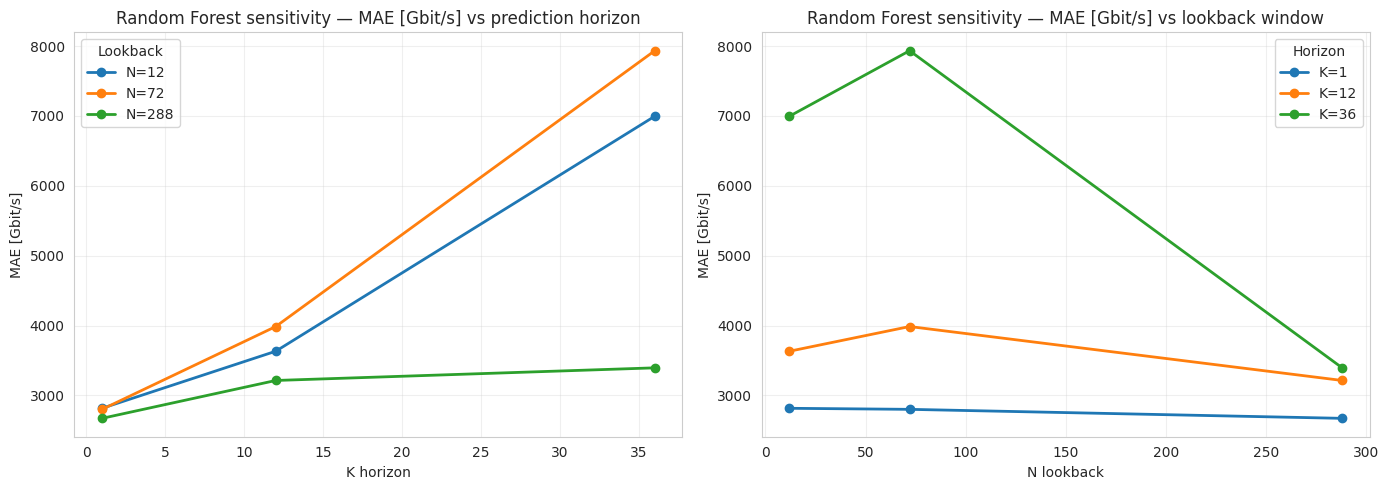

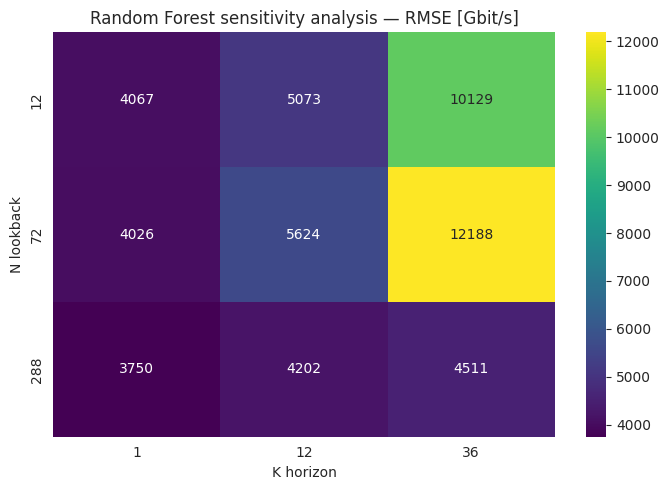

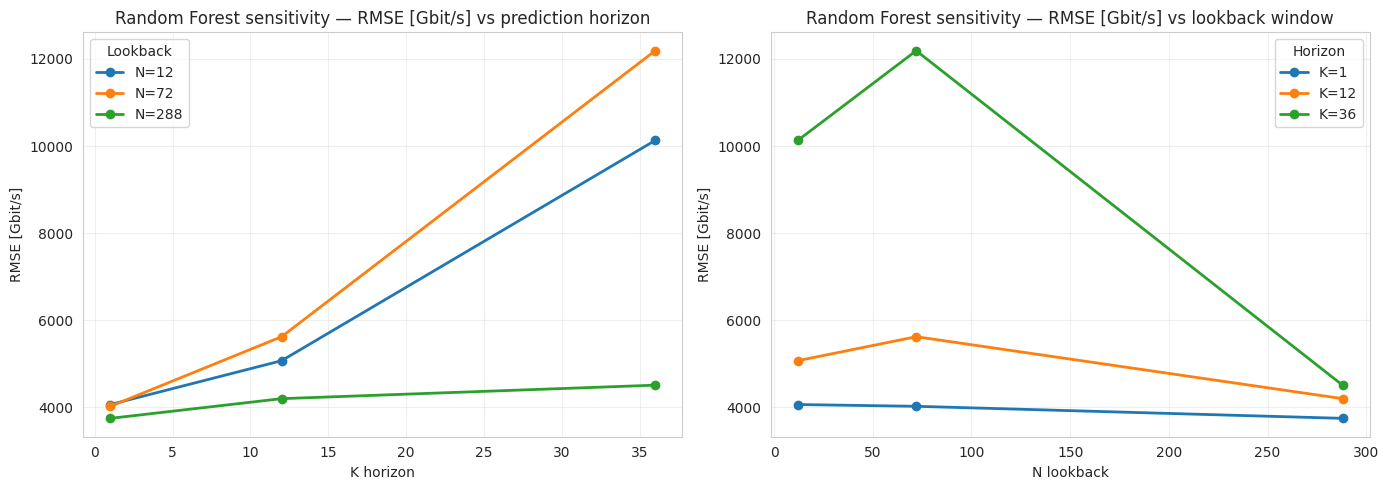

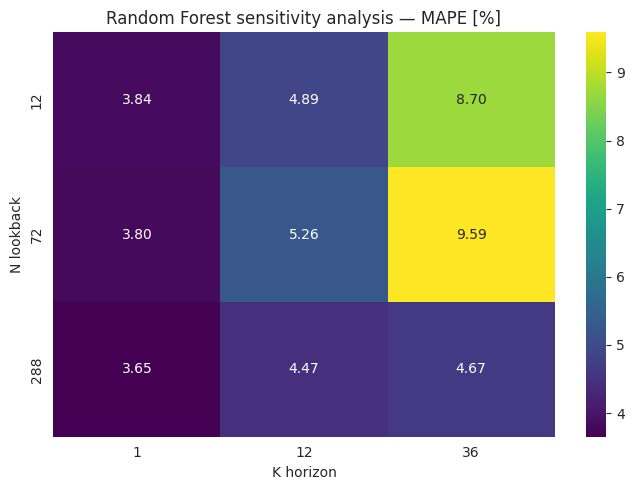

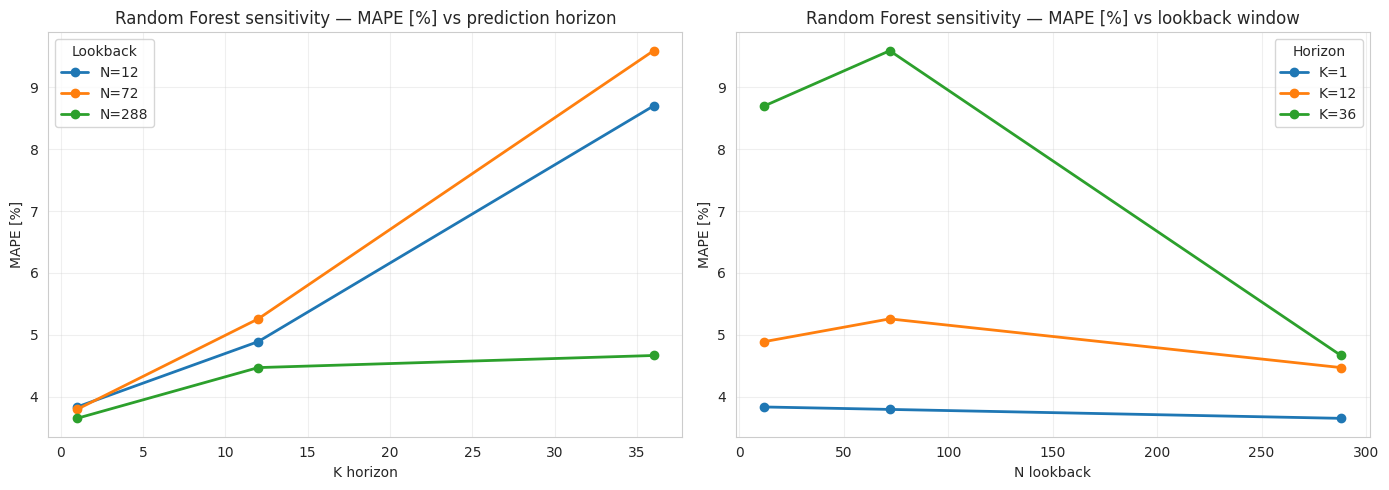

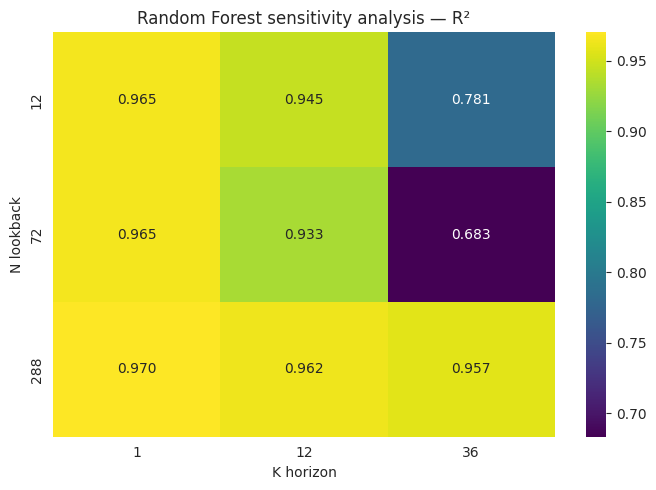

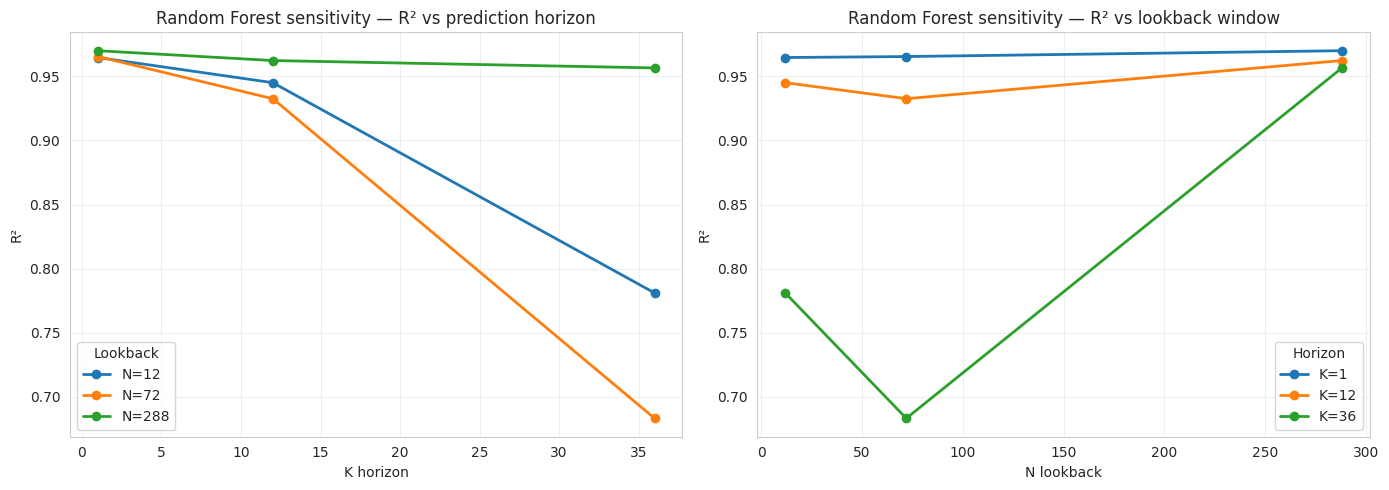

In [ ]:
# ========================
# RF VISUALIZATION
# ========================

metrics_to_plot = [
    ("MAE_Gbit_s", "MAE [Gbit/s]", ".0f"),
    ("RMSE_Gbit_s", "RMSE [Gbit/s]", ".0f"),
    ("MAPE_percent", "MAPE [%]", ".2f"),
    ("R2", "R²", ".3f"),
]

for metric, metric_label, fmt in metrics_to_plot:

    # ------------------------
    # Heatmap
    # ------------------------
    pivot_metric = rf_sensitivity.pivot(
        index="N",
        columns="K",
        values=metric
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        pivot_metric,
        annot=True,
        fmt=fmt,
        cmap="viridis"
    )

    plt.title(f"Random Forest sensitivity analysis — {metric_label}")
    plt.xlabel("K horizon")
    plt.ylabel("N lookback")
    plt.tight_layout()
    plt.show()


    # Line plot
    plt.figure(figsize=(14, 5))

    # Metric vs K horizon, one line for each N
    plt.subplot(1, 2, 1)

    for N in sorted(rf_sensitivity["N"].unique()):
        subset = rf_sensitivity[
            rf_sensitivity["N"] == N
        ].sort_values("K")

        plt.plot(
            subset["K"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"N={N}"
        )

    plt.title(f"Random Forest sensitivity — {metric_label} vs prediction horizon")
    plt.xlabel("K horizon")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Lookback")

    # Metric vs N lookback, one line for each K
    plt.subplot(1, 2, 2)

    for K in sorted(rf_sensitivity["K"].unique()):
        subset = rf_sensitivity[
            rf_sensitivity["K"] == K
        ].sort_values("N")

        plt.plot(
            subset["N"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"K={K}"
        )

    plt.title(f"Random Forest sensitivity — {metric_label} vs lookback window")
    plt.xlabel("N lookback")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Horizon")

    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"rf_sensitivity_{metric}.png",
        dpi=150
    )
    plt.show()

### **S4.1.7 - Reading the Random Forest sensitivity results**

The Random Forest error increases as the prediction horizon `K` grows, which is expected because longer-term forecasts are harder.

The best results are obtained with `N = 288`, corresponding to 24 hours of past traffic at 5-minute resolution. This suggests that the full daily cycle is highly informative for predicting European IXP traffic.

Intermediate lookback windows do not always improve performance: `N = 72` can be worse than `N = 12`, likely because it adds features without capturing the full daily pattern.

Overall, the key result is that Random Forest benefits strongly from seeing one complete day of history, especially for longer prediction horizons.

## **S4.2 - LSTM Forecasting**

LSTM uses the **same sliding-window inputs** as the Random Forest but processes them as ordered temporal sequences, so it can in principle exploit long-range dependencies the RF cannot see.

We use **expanding-window cross-validation** to select the LSTM hyperparameters, then train the final model on the original train/validation split.


### **S4.2.1 - LSTM configuration**

The baseline LSTM setting uses the same forecasting window as the Random Forest baseline:

- `N_LOOKBACK = 72`: previous 6 hours;
- `K_HORIZON = 12`: next 1 hour.

The hyperparameter grid is used only for LSTM model selection.

In [33]:
# ========================
# LSTM CONFIGURATION
# ========================

LSTM_MAX_EPOCHS = 30
LSTM_PATIENCE = 5

LSTM_PARAM_GRID = [
    {"hidden_size": 32, "num_layers": 1, "dropout": 0.0, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 1, "dropout": 0.0, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 2, "dropout": 0.1, "learning_rate": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.1, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 2, "dropout": 0.1, "learning_rate": 3e-4},
]

LSTM_CV_FOLDS = 3
LSTM_CV_EPOCHS = 8
LSTM_CV_PATIENCE = 3

### **S4.2.2 - DataLoaders**

PyTorch DataLoaders are used to feed mini-batches to the LSTM during training and evaluation.

In [34]:
# ========================
# DATALOADERS
# ========================

def make_loader(X, Y, batch_size, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(Y)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )


train_loader = make_loader(
    X_train,
    Y_train,
    BATCH_SIZE,
    shuffle=True
)

validation_loader = make_loader(
    X_validation,
    Y_validation,
    BATCH_SIZE,
    shuffle=False
)

test_loader = make_loader(
    X_test,
    Y_test,
    BATCH_SIZE,
    shuffle=False
)

### **S4.2.3 - LSTM model definition**

The LSTM reads the input sequence and uses the final hidden representation to predict the next `K` traffic values.

In [35]:
# ========================
# LSTM MODEL DEFINITION
# ========================

class LSTMForecaster(nn.Module):
    def __init__(
        self,
        horizon,
        hidden_size=64,
        num_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):
        x = x.unsqueeze(-1)

        output, _ = self.lstm(x)

        last_hidden = output[:, -1, :]

        prediction = self.head(last_hidden)

        return prediction

### **S4.2.4 - Reusable LSTM training function**

This function trains an LSTM model with early stopping. At the end of training, the best model according to validation loss is restored.

In [36]:
# ================================
# REUSABLE LSTM TRAINING FUNCTION
# ================================

def train_lstm_model(
    model,
    X_train,
    Y_train,
    X_validation,
    Y_validation,
    learning_rate,
    max_epochs,
    patience,
    batch_size,
    verbose=True
):
    train_loader = make_loader(
        X_train,
        Y_train,
        batch_size,
        shuffle=True
    )

    validation_loader = make_loader(
        X_validation,
        Y_validation,
        batch_size,
        shuffle=False
    )

    model = model.to(DEVICE)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_loss = float("inf")
    best_state = None
    bad_epochs = 0

    history = {
        "train_loss": [],
        "validation_loss": []
    }

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()

        train_loss_sum = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            pred = model(xb)

            loss = loss_fn(pred, yb)

            loss.backward()

            optimizer.step()

            train_loss_sum += loss.item() * len(xb)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()

        validation_loss_sum = 0.0

        with torch.no_grad():
            for xb, yb in validation_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                pred = model(xb)

                loss = loss_fn(pred, yb)

                validation_loss_sum += loss.item() * len(xb)

        validation_loss = validation_loss_sum / len(validation_loader.dataset)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(validation_loss)

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train MSE: {train_loss:.5f} | "
                f"validation MSE: {validation_loss:.5f}"
            )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

            if bad_epochs >= patience:
                if verbose:
                    print("Early stopping")
                break

    training_time = time.time() - start_time

    model.load_state_dict(best_state)

    return model, history, best_validation_loss, training_time

### **S4.2.5 - Expanding-window cross-validation**

Random cross-validation is not appropriate for time series because it would mix past and future observations. We use expanding-window cross-validation, where each fold trains on a growing past window and validates on a later time window.

This cross-validation is used only to select the LSTM hyperparameters.

In [37]:
# ==================================
# EXPANDING-WINDOW CROSS-VALIDATION
# ==================================

def expanding_window_cv_splits(
    values,
    n_folds=3,
    validation_fraction=0.15
):
    n = len(values)
    validation_size = int(n * validation_fraction)

    for fold in range(n_folds):
        validation_end = n - (n_folds - 1 - fold) * validation_size
        validation_start = validation_end - validation_size

        train_values = values[:validation_start]
        validation_values = values[validation_start:validation_end]

        yield fold + 1, train_values, validation_values


def evaluate_lstm_config_cv(
    train_values,
    params,
    n_lookback=N_LOOKBACK,
    k_horizon=K_HORIZON,
    n_folds=LSTM_CV_FOLDS,
    cv_epochs=LSTM_CV_EPOCHS,
    patience=LSTM_CV_PATIENCE
):
    fold_losses = []

    for fold, fold_train_raw, fold_validation_raw in expanding_window_cv_splits(
        train_values,
        n_folds=n_folds,
        validation_fraction=0.15
    ):
        print(f"Fold {fold}/{n_folds}")

        fold_scaler = Standardizer().fit(fold_train_raw)

        X_fold_train, Y_fold_train = make_windows(
            fold_scaler.transform(fold_train_raw),
            n_lookback,
            k_horizon,
            stride=TRAIN_STRIDE
        )

        X_fold_validation, Y_fold_validation = make_windows(
            fold_scaler.transform(fold_validation_raw),
            n_lookback,
            k_horizon,
            stride=k_horizon
        )

        fold_model = LSTMForecaster(
            horizon=k_horizon,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            dropout=params["dropout"]
        )

        _, _, best_validation_loss, _ = train_lstm_model(
            model=fold_model,
            X_train=X_fold_train,
            Y_train=Y_fold_train,
            X_validation=X_fold_validation,
            Y_validation=Y_fold_validation,
            learning_rate=params["learning_rate"],
            max_epochs=cv_epochs,
            patience=patience,
            batch_size=BATCH_SIZE,
            verbose=False
        )

        fold_losses.append(best_validation_loss)

        print(f"Validation MSE fold {fold}: {best_validation_loss:.6f}")

    return float(np.mean(fold_losses)), float(np.std(fold_losses))

### **S4.2.6 - Run LSTM cross-validation**

Each candidate configuration is evaluated using expanding-window cross-validation. The configuration with the lowest mean validation MSE is selected.

In [38]:
# ==========================
# RUN LSTM CROSS-VALIDATION
# ==========================

lstm_cv_results_list = []

for i, params in enumerate(LSTM_PARAM_GRID, start=1):
    print("=" * 80)
    print(f"Testing LSTM configuration {i}/{len(LSTM_PARAM_GRID)}")
    print(params)

    mean_validation_mse, std_validation_mse = evaluate_lstm_config_cv(
        train_values=train_raw,
        params=params
    )

    lstm_cv_results_list.append({
        **params,
        "mean_validation_mse": mean_validation_mse,
        "std_validation_mse": std_validation_mse
    })

    print(f"Mean CV validation MSE: {mean_validation_mse:.6f}")
    print(f"Std CV validation MSE:  {std_validation_mse:.6f}")

lstm_cv_results = (
    pd.DataFrame(lstm_cv_results_list)
    .sort_values("mean_validation_mse")
)

display(lstm_cv_results)

lstm_cv_results.to_csv(
    DATA_DIR / "lstm_cross_validation_results.csv",
    index=False
)

print("Saved:", DATA_DIR / "lstm_cross_validation_results.csv")

Testing LSTM configuration 1/5
{'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Fold 1/3
Validation MSE fold 1: 0.043187
Fold 2/3
Validation MSE fold 2: 0.036209
Fold 3/3
Validation MSE fold 3: 0.011805
Mean CV validation MSE: 0.030401
Std CV validation MSE:  0.013454
Testing LSTM configuration 2/5
{'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Fold 1/3
Validation MSE fold 1: 0.041474
Fold 2/3
Validation MSE fold 2: 0.036127
Fold 3/3
Validation MSE fold 3: 0.009746
Mean CV validation MSE: 0.029116
Std CV validation MSE:  0.013870
Testing LSTM configuration 3/5
{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001}
Fold 1/3
Validation MSE fold 1: 0.041754
Fold 2/3
Validation MSE fold 2: 0.037370
Fold 3/3
Validation MSE fold 3: 0.009516
Mean CV validation MSE: 0.029547
Std CV validation MSE:  0.014276
Testing LSTM configuration 4/5
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001}


,hidden_size,num_layers,dropout,learning_rate,mean_validation_mse,std_validation_mse
1,64,1,0.0,0.0010,0.029116,0.013870
3,128,2,0.1,0.0010,0.029192,0.014338
2,64,2,0.1,0.0010,0.029547,0.014276
0,32,1,0.0,0.0010,0.030401,0.013454
4,64,2,0.1,0.0003,0.032445,0.015149


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_cross_validation_results.csv


### **S4.2.7 - Select the best LSTM configuration**

The best hyperparameters are extracted from the cross-validation results and used for the final LSTM model.

In [39]:
# ===============================
# SELECT BEST LSTM CONFIGURATION
# ===============================

best_lstm_params = lstm_cv_results.iloc[0]

BEST_HIDDEN_SIZE = int(best_lstm_params["hidden_size"])
BEST_NUM_LAYERS = int(best_lstm_params["num_layers"])
BEST_DROPOUT = float(best_lstm_params["dropout"])
BEST_LEARNING_RATE = float(best_lstm_params["learning_rate"])

print("Best LSTM parameters:")
print("Hidden size:", BEST_HIDDEN_SIZE)
print("Num layers:", BEST_NUM_LAYERS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LEARNING_RATE)
print("CV validation MSE:", best_lstm_params["mean_validation_mse"])

Best LSTM parameters:
Hidden size: 64
Num layers: 1
Dropout: 0.0
Learning rate: 0.001
CV validation MSE: 0.029115689556556027


### **S4.2.8 - Final LSTM training**

The final LSTM is trained using the best hyperparameters selected by cross-validation. Training uses the training split and early stopping is based on the validation split.

In [40]:
# ========================
# FINAL LSTM TRAINING
# ========================

lstm_model = LSTMForecaster(
    horizon=K_HORIZON,
    hidden_size=BEST_HIDDEN_SIZE,
    num_layers=BEST_NUM_LAYERS,
    dropout=BEST_DROPOUT
).to(DEVICE)

print(lstm_model)

lstm_n_parameters = sum(
    p.numel()
    for p in lstm_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", lstm_n_parameters)

lstm_model, lstm_history, lstm_best_validation_loss, lstm_training_time = train_lstm_model(
    model=lstm_model,
    X_train=X_train,
    Y_train=Y_train,
    X_validation=X_validation,
    Y_validation=Y_validation,
    learning_rate=BEST_LEARNING_RATE,
    max_epochs=LSTM_MAX_EPOCHS,
    patience=LSTM_PATIENCE,
    batch_size=BATCH_SIZE,
    verbose=True
)

print(f"Best validation loss: {lstm_best_validation_loss:.6f}")
print(f"Training time: {lstm_training_time:.2f} seconds")

LSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=12, bias=True)
)
Trainable parameters: 17932
Epoch 01 | train MSE: 0.17071 | validation MSE: 0.04681
Epoch 02 | train MSE: 0.00931 | validation MSE: 0.04264
Epoch 03 | train MSE: 0.00702 | validation MSE: 0.04308
Epoch 04 | train MSE: 0.00652 | validation MSE: 0.03977
Epoch 05 | train MSE: 0.00614 | validation MSE: 0.04000
Epoch 06 | train MSE: 0.00597 | validation MSE: 0.03944
Epoch 07 | train MSE: 0.00587 | validation MSE: 0.04078
Epoch 08 | train MSE: 0.00568 | validation MSE: 0.03992
Epoch 09 | train MSE: 0.00562 | validation MSE: 0.04065
Epoch 10 | train MSE: 0.00555 | validation MSE: 0.04092
Epoch 11 | train MSE: 0.00557 | validation MSE: 0.03944
Early stopping
Best validation loss: 0.039440
Training time: 7.97 seconds


### **S4.2.9 - LSTM learning curve**

The learning curve is used to inspect the training process and check whether validation loss stabilizes or starts increasing.

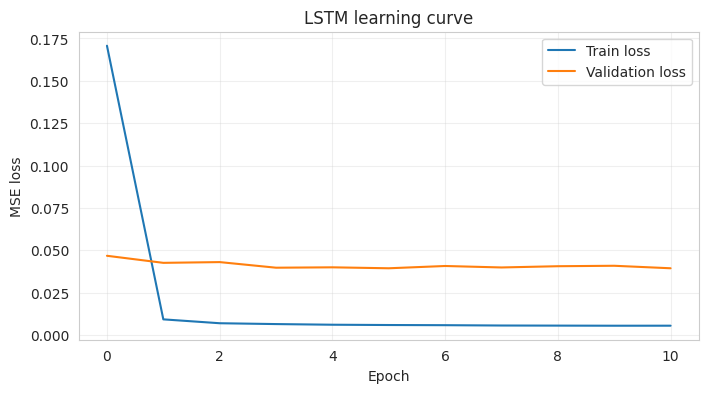

In [41]:
# ========================
# LSTM LEARNING CURVE
# ========================

plt.figure(figsize=(8, 4))

plt.plot(
    lstm_history["train_loss"],
    label="Train loss"
)

plt.plot(
    lstm_history["validation_loss"],
    label="Validation loss"
)

plt.title("LSTM learning curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### **S4.2.10 - LSTM test evaluation**

The final LSTM is evaluated on the held-out test set. Predictions are converted back to Gbit/s before computing the metrics.

In [42]:
# ========================
# LSTM TEST EVALUATION
# ========================

lstm_model.eval()

lstm_predictions_scaled = []
lstm_targets_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        pred = lstm_model(xb).cpu().numpy()

        lstm_predictions_scaled.append(pred)
        lstm_targets_scaled.append(yb.numpy())

lstm_predictions_scaled = np.concatenate(lstm_predictions_scaled)
lstm_targets_scaled = np.concatenate(lstm_targets_scaled)

lstm_predictions = scaler.inverse(lstm_predictions_scaled)
lstm_targets = scaler.inverse(lstm_targets_scaled)

lstm_y_pred = lstm_predictions.ravel()
lstm_y_true = lstm_targets.ravel()

lstm_mae, lstm_rmse, lstm_mape, lstm_r2 = compute_regression_metrics(
    lstm_y_true,
    lstm_y_pred
)

print(f"LSTM MAE  [Gbit/s]: {lstm_mae:.2f}")
print(f"LSTM RMSE [Gbit/s]: {lstm_rmse:.2f}")
print(f"LSTM MAPE [%]:     {lstm_mape:.2f}")
print(f"LSTM R2:           {lstm_r2:.4f}")

LSTM MAE  [Gbit/s]: 3371.16
LSTM RMSE [Gbit/s]: 4080.24
LSTM MAPE [%]:     4.61
LSTM R2:           0.9645


### **S4.2.11 - LSTM forecast visualization**

The first test day is plotted to visually compare the true traffic and the LSTM forecast.

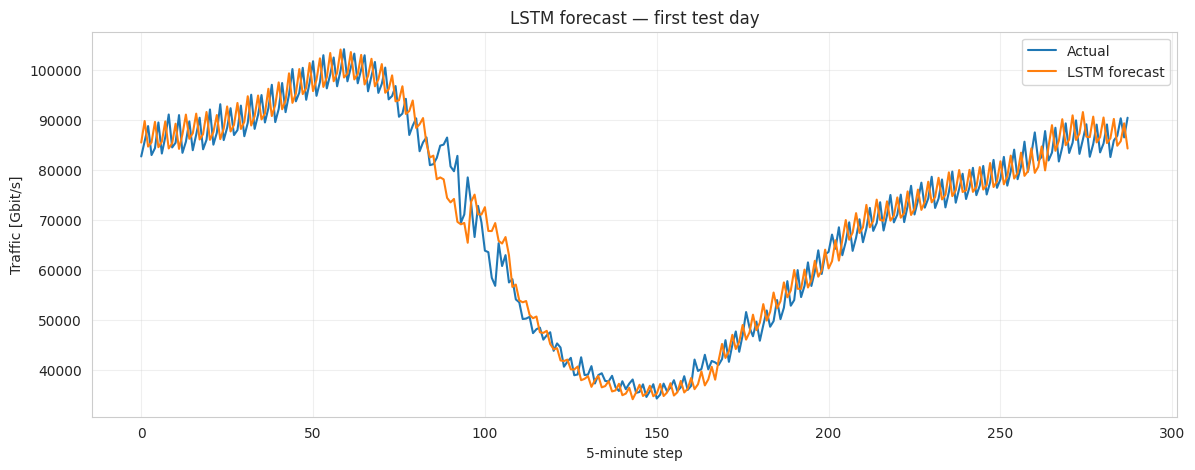

In [43]:
# ============================
# LSTM FORECAST VISUALIZATION
# ============================

first_day_windows = (24 * 12) // K_HORIZON

plt.figure(figsize=(14, 5))

plt.plot(
    lstm_targets[:first_day_windows].ravel(),
    label="Actual"
)

plt.plot(
    lstm_predictions[:first_day_windows].ravel(),
    label="LSTM forecast"
)

plt.title("LSTM forecast — first test day")
plt.xlabel("5-minute step")
plt.ylabel("Traffic [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### **S4.2.12 - Save LSTM metrics and model**

The LSTM metrics, selected hyperparameters, scaler parameters and model weights are saved for reproducibility.

In [44]:
# ===========================
# SAVE LSTM METRICS AND MODEL
# ===========================

lstm_metrics = pd.DataFrame([
    {
        "model": "LSTM",
        "N": N_LOOKBACK,
        "K": K_HORIZON,
        "hidden_size": BEST_HIDDEN_SIZE,
        "num_layers": BEST_NUM_LAYERS,
        "dropout": BEST_DROPOUT,
        "learning_rate": BEST_LEARNING_RATE,
        "cv_validation_mse": best_lstm_params["mean_validation_mse"],
        "MAE_Gbit_s": lstm_mae,
        "RMSE_Gbit_s": lstm_rmse,
        "MAPE_percent": lstm_mape,
        "R2": lstm_r2,
        "training_time_seconds": lstm_training_time,
    }
])

display(lstm_metrics)

lstm_metrics.to_csv(
    DATA_DIR / "lstm_metrics.csv",
    index=False
)

torch.save(
    {
        "model_state_dict": lstm_model.state_dict(),
        "N": N_LOOKBACK,
        "K": K_HORIZON,
        "hidden_size": BEST_HIDDEN_SIZE,
        "num_layers": BEST_NUM_LAYERS,
        "dropout": BEST_DROPOUT,
        "learning_rate": BEST_LEARNING_RATE,
        "scaler_mean": scaler.mean,
        "scaler_std": scaler.std,
    },
    DATA_DIR / "lstm_model.pt"
)

print("Saved:", DATA_DIR / "lstm_metrics.csv")
print("Saved:", DATA_DIR / "lstm_model.pt")

,model,N,K,hidden_size,num_layers,dropout,learning_rate,cv_validation_mse,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
0,LSTM,72,12,64,1,0.0,0.001,0.029116,3371.156494,4080.237371,4.609358,0.964506,7.969151


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_metrics.csv
Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_model.pt


### **S4.2.13 - LSTM sensitivity analysis over N and K**

How the forecasting performance changes with different lookback windows `N` and prediction horizons `K`.

The LSTM architecture selected by cross-validation is kept fixed, while `N` and `K` are varied.

In [45]:
def run_lstm_experiment(
    n_lookback,
    k_horizon,
    max_epochs=12,
    patience=3,
    train_stride=TRAIN_STRIDE,
):
    X_train_exp, Y_train_exp = make_windows(
        train_scaled,
        n_lookback,
        k_horizon,
        stride=train_stride
    )

    X_validation_exp, Y_validation_exp = make_windows(
        validation_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    X_test_exp, Y_test_exp = make_windows(
        test_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    experiment_model = LSTMForecaster(
        horizon=k_horizon,
        hidden_size=BEST_HIDDEN_SIZE,
        num_layers=BEST_NUM_LAYERS,
        dropout=BEST_DROPOUT
    ).to(DEVICE)

    experiment_model, _, _, experiment_training_time = train_lstm_model(
        model=experiment_model,
        X_train=X_train_exp,
        Y_train=Y_train_exp,
        X_validation=X_validation_exp,
        Y_validation=Y_validation_exp,
        learning_rate=BEST_LEARNING_RATE,
        max_epochs=max_epochs,
        patience=patience,
        batch_size=BATCH_SIZE,
        verbose=False
    )

    test_loader_exp = make_loader(
        X_test_exp,
        Y_test_exp,
        BATCH_SIZE,
        shuffle=False
    )

    experiment_model.eval()

    predictions_scaled_exp = []
    targets_scaled_exp = []

    with torch.no_grad():
        for xb, yb in test_loader_exp:
            xb = xb.to(DEVICE)
            pred = experiment_model(xb).cpu().numpy()
            predictions_scaled_exp.append(pred)
            targets_scaled_exp.append(yb.numpy())

    predictions_scaled_exp = np.concatenate(predictions_scaled_exp)
    targets_scaled_exp = np.concatenate(targets_scaled_exp)

    predictions_exp = scaler.inverse(predictions_scaled_exp)
    targets_exp = scaler.inverse(targets_scaled_exp)

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    return {
        "model": "LSTM",
        "N": n_lookback,
        "K": k_horizon,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": experiment_training_time,
        "train_windows": len(X_train_exp),
        "validation_windows": len(X_validation_exp),
        "test_windows": len(X_test_exp),
    }

In [46]:
# ==========================
# LSTM SENSITIVITY ANALYSIS
# ==========================

LSTM_SENSITIVITY_PATH = DATA_DIR / "lstm_sensitivity_NK.csv"

# Load previous results if the checkpoint already exists.
if LSTM_SENSITIVITY_PATH.exists():
    lstm_sensitivity = pd.read_csv(LSTM_SENSITIVITY_PATH)
    lstm_sensitivity_results = lstm_sensitivity.to_dict("records")
    completed_experiments = set(
        zip(lstm_sensitivity["N"], lstm_sensitivity["K"])
    )
    print(f"Loaded checkpoint: {LSTM_SENSITIVITY_PATH}")
    print(f"Completed experiments: {len(completed_experiments)}")
else:
    lstm_sensitivity_results = []
    completed_experiments = set()
    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:

        # Skip experiments already saved in the checkpoint.
        if (N, K) in completed_experiments:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running LSTM sensitivity experiment: N={N}, K={K}")

        result = run_lstm_experiment(
            n_lookback=N,
            k_horizon=K,
            max_epochs=12,
            patience=3,
            train_stride=TRAIN_STRIDE,
        )

        lstm_sensitivity_results.append(result)
        completed_experiments.add((N, K))

        # Save checkpoint immediately after each experiment.
        lstm_sensitivity = pd.DataFrame(lstm_sensitivity_results)
        lstm_sensitivity.to_csv(
            LSTM_SENSITIVITY_PATH,
            index=False
        )

        print(result)
        print(f"Checkpoint saved: {LSTM_SENSITIVITY_PATH}")


lstm_sensitivity = pd.DataFrame(lstm_sensitivity_results)

display(lstm_sensitivity)

print("Final results saved:", LSTM_SENSITIVITY_PATH)

Loaded checkpoint: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_sensitivity_NK.csv
Completed experiments: 9
Skipping already completed experiment: N=12, K=1
Skipping already completed experiment: N=12, K=12
Skipping already completed experiment: N=12, K=36
Skipping already completed experiment: N=72, K=1
Skipping already completed experiment: N=72, K=12
Skipping already completed experiment: N=72, K=36
Skipping already completed experiment: N=288, K=1
Skipping already completed experiment: N=288, K=12
Skipping already completed experiment: N=288, K=36


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,train_windows,validation_windows,test_windows
0,LSTM,12,1,2413.630615,3087.628540,3.331510,0.979640,4.537785,49120,31567,31568
1,LSTM,12,12,3705.276367,4291.867426,5.155362,0.960668,10.621041,49116,2630,2630
2,LSTM,12,36,4280.638184,5660.495385,5.804010,0.931631,20.093706,49108,876,876
3,LSTM,72,1,2284.308105,2958.567728,3.144684,0.981336,12.211540,49100,31507,31508
4,LSTM,72,12,3391.139648,4147.772414,4.642840,0.963322,11.127217,49096,2625,2625
5,LSTM,72,36,4492.940430,6278.388328,6.013738,0.915962,13.924815,49088,875,875
6,LSTM,288,1,2283.743164,2919.696731,3.155295,0.981803,9.958936,49028,31291,31292
7,LSTM,288,12,3436.667969,4185.669361,4.710124,0.962608,11.178359,49024,2607,2607
8,LSTM,288,36,4572.845703,6532.170237,6.088394,0.908933,10.582124,49016,869,869


Final results saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_sensitivity_NK.csv


### **S4.2.14 - LSTM sensitivity visualization**

The heatmap and line plots summarize how the LSTM error changes with the lookback window `N` and the forecasting horizon `K`.

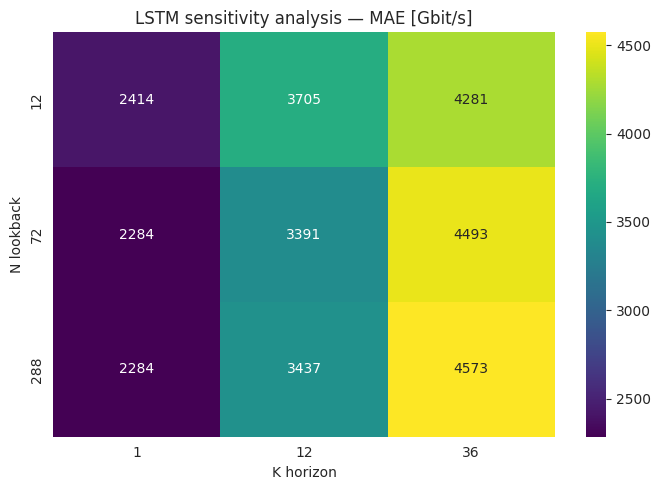

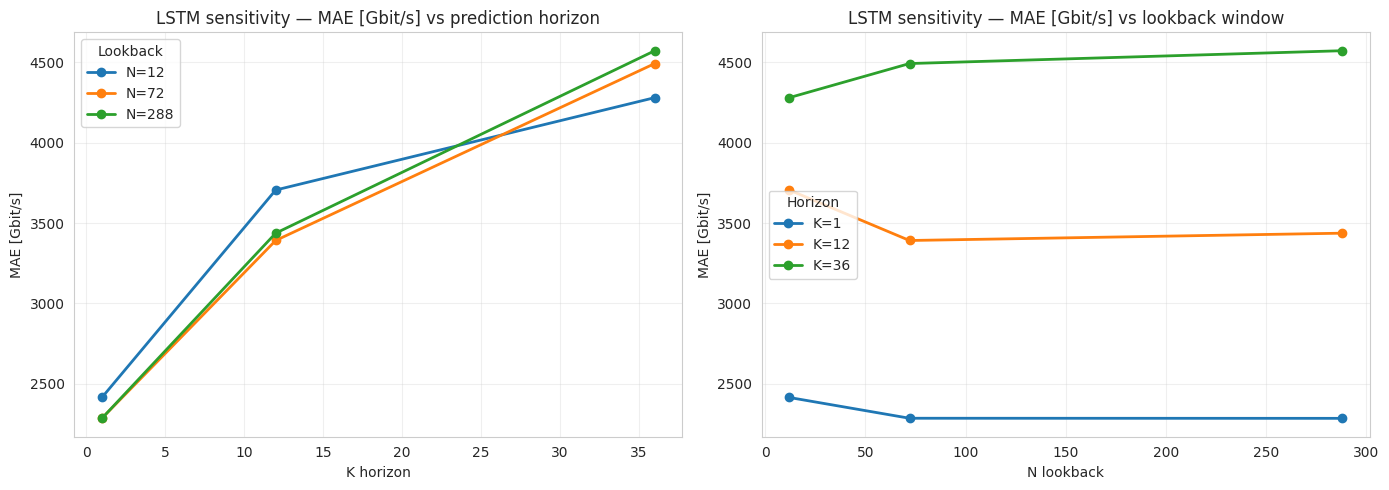

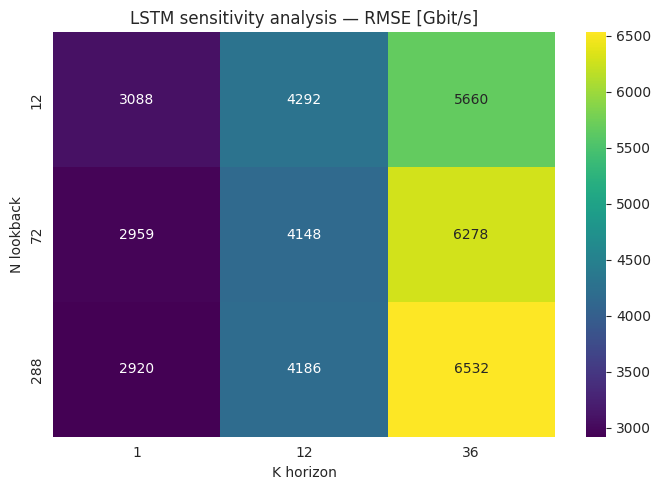

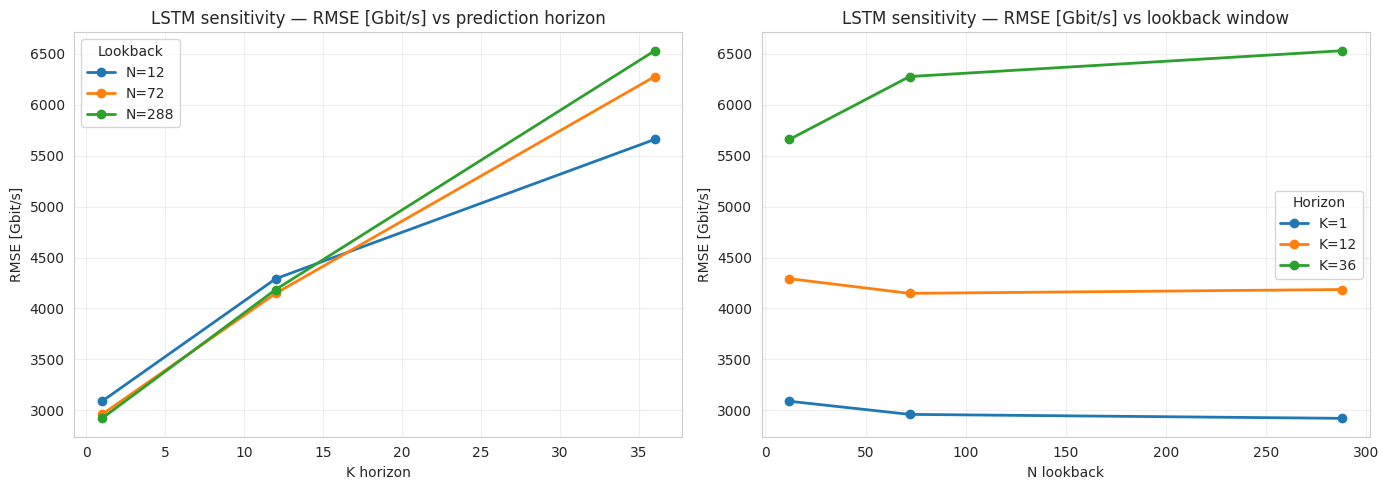

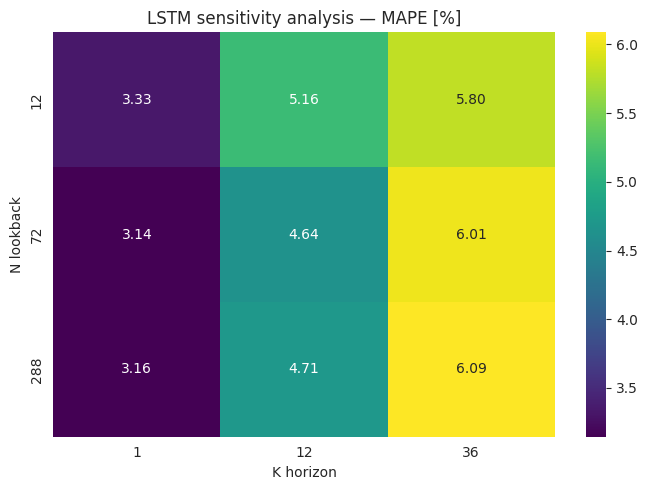

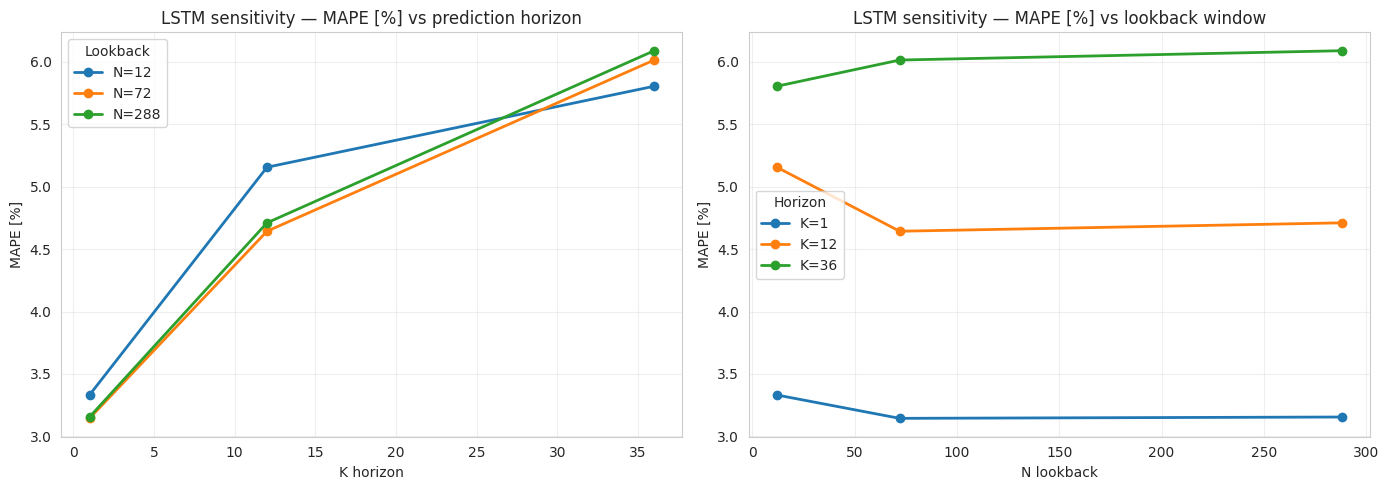

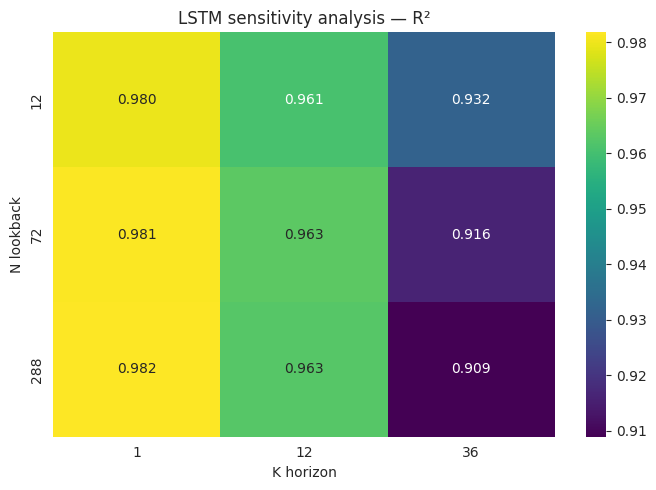

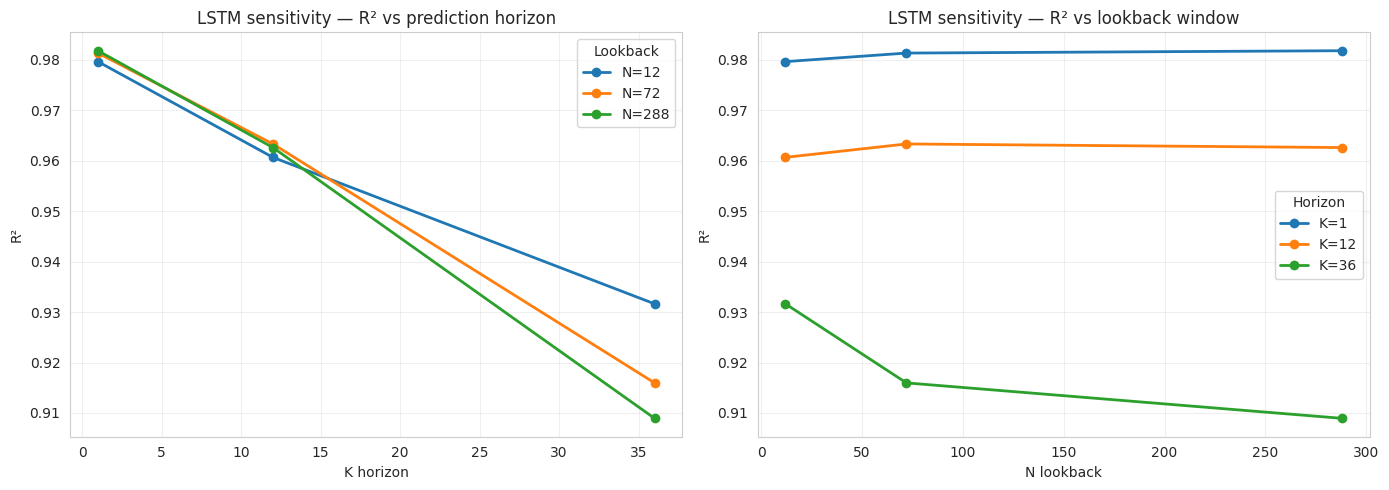

In [47]:
# ===============================
# LSTM SENSITIVITY VISUALIZATION
# ===============================

metrics_to_plot = [
    ("MAE_Gbit_s", "MAE [Gbit/s]", ".0f"),
    ("RMSE_Gbit_s", "RMSE [Gbit/s]", ".0f"),
    ("MAPE_percent", "MAPE [%]", ".2f"),
    ("R2", "R²", ".3f"),
]

for metric, metric_label, fmt in metrics_to_plot:

    # Heatmap
    pivot_metric = lstm_sensitivity.pivot(
        index="N",
        columns="K",
        values=metric
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        pivot_metric,
        annot=True,
        fmt=fmt,
        cmap="viridis"
    )

    plt.title(f"LSTM sensitivity analysis — {metric_label}")
    plt.xlabel("K horizon")
    plt.ylabel("N lookback")
    plt.tight_layout()
    plt.show()

    # Line plots
    plt.figure(figsize=(14, 5))

    # Metric vs K horizon, one line for each N
    plt.subplot(1, 2, 1)

    for N in sorted(lstm_sensitivity["N"].unique()):
        subset = lstm_sensitivity[
            lstm_sensitivity["N"] == N
        ].sort_values("K")

        plt.plot(
            subset["K"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"N={N}"
        )

    plt.title(f"LSTM sensitivity — {metric_label} vs prediction horizon")
    plt.xlabel("K horizon")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Lookback")

    # Metric vs N lookback, one line for each K
    plt.subplot(1, 2, 2)

    for K in sorted(lstm_sensitivity["K"].unique()):
        subset = lstm_sensitivity[
            lstm_sensitivity["K"] == K
        ].sort_values("N")

        plt.plot(
            subset["N"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"K={K}"
        )

    plt.title(f"LSTM sensitivity — {metric_label} vs lookback window")
    plt.xlabel("N lookback")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Horizon")

    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"lstm_sensitivity_{metric}.png",
        dpi=150
    )
    plt.show()

### **S4.2.15 - Reading the LSTM sensitivity results**

The LSTM error increases as the prediction horizon `K` grows, which is expected because longer forecasts are harder.

The lookback window has a different effect from Random Forest. Increasing `N` does not consistently improve the LSTM results. In particular, `N = 288` does not help and can even worsen performance, especially for longer horizons.

The best trade-off appears around `N = 72`: it provides enough temporal context without making the sequence unnecessarily long. Very long sequences may make the LSTM harder to train and can introduce extra noise.

Overall, the LSTM is less dependent on a full 24-hour lookback than Random Forest. For this reason, `N = 72` is a reasonable default choice for the later model comparison.

### **S4.2.16 - LSTM vs Random Forest sensitivity comparison**

Side-by-side comparison of how the two models respond to changes in `N` and `K`. This is the core deliverable of the sensitivity analysis required by the assignment.


In [48]:
# ====================================
# LSTM vs RF SENSITIVITY COMPARISION
# ====================================

sensitivity_all = pd.concat(
    [lstm_sensitivity],
    ignore_index=True
)

metrics_to_compare = [
    ("MAE_Gbit_s", "MAE [Gbit/s]", ".0f", "lower"),
    ("RMSE_Gbit_s", "RMSE [Gbit/s]", ".0f", "lower"),
    ("MAPE_percent", "MAPE [%]", ".2f", "lower"),
    ("R2", "R²", ".3f", "higher"),
]

for metric, metric_label, fmt, better_direction in metrics_to_compare:

    # Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, model in zip(axes, ["LSTM", "Random Forest"]):
        pivot = sensitivity_all[
            sensitivity_all["model"] == model
        ].pivot(
            index="N",
            columns="K",
            values=metric
        )

        sns.heatmap(
            pivot,
            annot=True,
            fmt=fmt,
            cmap="viridis",
            ax=ax
        )

        ax.set_title(f"{model} — {metric_label}")
        ax.set_xlabel("K horizon")
        ax.set_ylabel("N lookback")

    plt.suptitle(
        f"Sensitivity analysis — LSTM vs Random Forest ({metric_label})",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"sensitivity_comparison_heatmaps_{metric}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    # Metric vs K for each N, both models
    fig, axes = plt.subplots(
        1,
        len(N_VALUES),
        figsize=(6 * len(N_VALUES), 5),
        sharey=True
    )

    if len(N_VALUES) == 1:
        axes = [axes]

    for ax, N in zip(axes, sorted(N_VALUES)):
        for model, marker, ls in [
            ("LSTM", "o", "-"),
            ("Random Forest", "s", "--")
        ]:
            subset = sensitivity_all[
                (sensitivity_all["model"] == model) &
                (sensitivity_all["N"] == N)
            ].sort_values("K")

            ax.plot(
                subset["K"],
                subset[metric],
                marker=marker,
                linestyle=ls,
                linewidth=2,
                label=model
            )

        ax.set_title(f"N = {N} ({N * 5 // 60}h lookback)")
        ax.set_xlabel("K horizon")
        ax.set_ylabel(metric_label)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.suptitle(
        f"LSTM vs Random Forest — {metric_label} vs prediction horizon",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"sensitivity_comparison_lineplots_{metric}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    # Delta heatmap
    pivot_lstm = lstm_sensitivity.pivot(
        index="N",
        columns="K",
        values=metric
    )

    pivot_rf = rf_sensitivity.pivot(
        index="N",
        columns="K",
        values=metric
    )

    if better_direction == "lower":
        # Positive means RF has higher error than LSTM, so LSTM wins.
        delta = pivot_rf - pivot_lstm
        delta_title = f"{metric_label} difference (RF - LSTM)"
    else:
        # For R², higher is better. Positive means LSTM has higher R².
        delta = pivot_lstm - pivot_rf
        delta_title = f"{metric_label} difference (LSTM - RF)"

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        delta,
        annot=True,
        fmt=fmt,
        cmap="RdYlGn",
        center=0
    )

    plt.title(
        f"{delta_title}\nGreen = LSTM wins, Red = Random Forest wins"
    )
    plt.xlabel("K horizon")
    plt.ylabel("N lookback")
    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"sensitivity_delta_heatmap_{metric}.png",
        dpi=150
    )
    plt.show()

NameError: name 'rf_sensitivity' is not defined

### **S4.2.17 - Reading the LSTM vs Random Forest sensitivity comparison**

The comparison shows that both models become less accurate as the prediction horizon `K` increases. This is expected: predicting further into the future is harder.

For short and medium lookback windows (`N = 12` and `N = 72`), the LSTM clearly performs better than Random Forest, especially for longer horizons. For example, at `N = 72, K = 36`, the LSTM has much lower MAE/RMSE/MAPE and much higher R² than Random Forest.

The situation changes at `N = 288`. With a full 24-hour lookback, Random Forest becomes very competitive and even outperforms the LSTM for longer horizons. This happens because the full daily cycle is explicitly present in the input, allowing Random Forest to exploit strong “same time yesterday” patterns.

Overall, the LSTM is the better choice when the available lookback is short or moderate, while Random Forest is a strong baseline when a full-day lookback is available. This confirms that the LSTM is less dependent on explicitly seeing the full daily cycle, whereas Random Forest benefits strongly from it.

In [ ]:
# ====================================================
# TRAINING TIME COMPARISON — RF vs LSTM across N × K
# ====================================================

pivot_time_lstm = lstm_sensitivity.pivot(
    index="N", columns="K", values="training_time_seconds"
)
pivot_time_rf = rf_sensitivity.pivot(
    index="N", columns="K", values="training_time_seconds"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pivot, model in zip(
    axes,
    [pivot_time_lstm, pivot_time_rf],
    ["LSTM", "Random Forest"]
):
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        ax=ax
    )
    ax.set_title(f"{model} — training time [s]")
    ax.set_xlabel("K horizon")
    ax.set_ylabel("N lookback")

plt.suptitle("Training time across N × K grid", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "sensitivity_training_time_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary bar: total time per model
total_lstm_time = lstm_sensitivity["training_time_seconds"].sum()
total_rf_time   = rf_sensitivity["training_time_seconds"].sum()

print(f"LSTM total sensitivity sweep time : {total_lstm_time:.1f} s  ({total_lstm_time/60:.1f} min)")
print(f"RF   total sensitivity sweep time : {total_rf_time:.1f} s  ({total_rf_time/60:.1f} min)")
print(f"RF / LSTM ratio                   : {total_rf_time / total_lstm_time:.1f}×")

#Speed-up per (N, K) cell
speedup = pivot_time_rf / pivot_time_lstm
plt.figure(figsize=(7, 5))
sns.heatmap(
    speedup,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)
plt.title("Training time ratio (RF / LSTM)\nHigher = RF takes proportionally longer")
plt.xlabel("K horizon")
plt.ylabel("N lookback")
plt.tight_layout()
plt.savefig(DATA_DIR / "sensitivity_training_time_ratio.png", dpi=150)
plt.show()

### **S4.2.18 - Training time: Random Forest vs LSTM**

The heatmaps above show training time in seconds for each (N, K) combination.

Random Forest dominates wall-clock time, often by two orders of magnitude relative to the LSTM. The ratio heatmap makes the asymmetry explicit: a single RF experiment at (N = 288, K = 1) can take as long as the entire LSTM sensitivity sweep combined.

The mechanisms are different for the two models. RF training time scales with N (more features mean deeper trees and more split comparisons) but is largely independent of K, since a multi-output RF builds the same set of trees regardless of how many outputs they predict. LSTM training time scales weakly with N (slightly longer sequences per forward pass) and with K (a larger output head means gradients flowing through more output neurons), but since the dominant cost is matrix operations on GPU both dependencies are mild, and the LSTM stays fast across the entire grid.

In practice, if the compute budget is a constraint (for example if the model must be re-trained daily on fresh data), the LSTM sweep takes a fraction of the RF time while achieving equal or better accuracy on most metrics. The genuine advantage left to the RF is interpretability, since feature importances map directly to lag positions, not speed.

In [50]:
BEST_HIDDEN_SIZE = 128
BEST_NUM_LAYERS = 2

In [51]:
def run_lstm_experiment(
    n_lookback,
    k_horizon,
    max_epochs=12,
    patience=3,
    train_stride=TRAIN_STRIDE,
):
    X_train_exp, Y_train_exp = make_windows(
        train_scaled,
        n_lookback,
        k_horizon,
        stride=train_stride
    )

    X_validation_exp, Y_validation_exp = make_windows(
        validation_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    X_test_exp, Y_test_exp = make_windows(
        test_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    experiment_model = LSTMForecaster(
        horizon=k_horizon,
        hidden_size=BEST_HIDDEN_SIZE,
        num_layers=BEST_NUM_LAYERS,
        dropout=BEST_DROPOUT
    ).to(DEVICE)

    experiment_model, _, _, experiment_training_time = train_lstm_model(
        model=experiment_model,
        X_train=X_train_exp,
        Y_train=Y_train_exp,
        X_validation=X_validation_exp,
        Y_validation=Y_validation_exp,
        learning_rate=BEST_LEARNING_RATE,
        max_epochs=max_epochs,
        patience=patience,
        batch_size=BATCH_SIZE,
        verbose=False
    )

    test_loader_exp = make_loader(
        X_test_exp,
        Y_test_exp,
        BATCH_SIZE,
        shuffle=False
    )

    experiment_model.eval()

    predictions_scaled_exp = []
    targets_scaled_exp = []

    with torch.no_grad():
        for xb, yb in test_loader_exp:
            xb = xb.to(DEVICE)
            pred = experiment_model(xb).cpu().numpy()
            predictions_scaled_exp.append(pred)
            targets_scaled_exp.append(yb.numpy())

    predictions_scaled_exp = np.concatenate(predictions_scaled_exp)
    targets_scaled_exp = np.concatenate(targets_scaled_exp)

    predictions_exp = scaler.inverse(predictions_scaled_exp)
    targets_exp = scaler.inverse(targets_scaled_exp)

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    return {
        "model": "LSTM",
        "N": n_lookback,
        "K": k_horizon,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": experiment_training_time,
        "train_windows": len(X_train_exp),
        "validation_windows": len(X_validation_exp),
        "test_windows": len(X_test_exp),
    }

In [52]:
# ==========================
# LSTM SENSITIVITY ANALYSIS
# ==========================

LSTM_SENSITIVITY_PATH = DATA_DIR / "lstm_sensitivity_NK_128_2.csv"

# Load previous results if the checkpoint already exists.
if LSTM_SENSITIVITY_PATH.exists():
    lstm_sensitivity = pd.read_csv(LSTM_SENSITIVITY_PATH)
    lstm_sensitivity_results = lstm_sensitivity.to_dict("records")
    completed_experiments = set(
        zip(lstm_sensitivity["N"], lstm_sensitivity["K"])
    )
    print(f"Loaded checkpoint: {LSTM_SENSITIVITY_PATH}")
    print(f"Completed experiments: {len(completed_experiments)}")
else:
    lstm_sensitivity_results = []
    completed_experiments = set()
    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:

        # Skip experiments already saved in the checkpoint.
        if (N, K) in completed_experiments:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running LSTM sensitivity experiment: N={N}, K={K}")

        result = run_lstm_experiment(
            n_lookback=N,
            k_horizon=K,
            max_epochs=12,
            patience=3,
            train_stride=TRAIN_STRIDE,
        )

        lstm_sensitivity_results.append(result)
        completed_experiments.add((N, K))

        # Save checkpoint immediately after each experiment.
        lstm_sensitivity = pd.DataFrame(lstm_sensitivity_results)
        lstm_sensitivity.to_csv(
            LSTM_SENSITIVITY_PATH,
            index=False
        )

        print(result)
        print(f"Checkpoint saved: {LSTM_SENSITIVITY_PATH}")


lstm_sensitivity = pd.DataFrame(lstm_sensitivity_results)

display(lstm_sensitivity)

print("Final results saved:", LSTM_SENSITIVITY_PATH)

No checkpoint found. Starting from scratch.
Running LSTM sensitivity experiment: N=12, K=1
{'model': 'LSTM', 'N': 12, 'K': 1, 'MAE_Gbit_s': 2310.9091796875, 'RMSE_Gbit_s': 2995.8698236071605, 'MAPE_percent': np.float32(3.1894672), 'R2': 0.9808323979377747, 'training_time_seconds': 12.232232570648193, 'train_windows': 49120, 'validation_windows': 31567, 'test_windows': 31568}
Checkpoint saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_sensitivity_NK_128_2.csv
Running LSTM sensitivity experiment: N=12, K=12
{'model': 'LSTM', 'N': 12, 'K': 12, 'MAE_Gbit_s': 3726.933837890625, 'RMSE_Gbit_s': 4265.85466231563, 'MAPE_percent': np.float32(5.156228), 'R2': 0.9611430764198303, 'training_time_seconds': 12.887751817703247, 'train_windows': 49116, 'validation_windows': 2630, 'test_windows': 2630}
Checkpoint saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_sensitivity_NK_128_2.csv
Running LSTM sensitivity experiment: N=12, K=36
{'model': 'LSTM

,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,train_windows,validation_windows,test_windows
0,LSTM,12,1,2310.909180,2995.869824,3.189467,0.980832,12.232233,49120,31567,31568
1,LSTM,12,12,3726.933838,4265.854662,5.156228,0.961143,12.887752,49116,2630,2630
2,LSTM,12,36,4826.022949,6728.541893,6.439312,0.903397,9.722251,49108,876,876
3,LSTM,72,1,2235.016602,2898.155103,3.087617,0.982090,15.116836,49100,31507,31508
4,LSTM,72,12,3492.228027,4138.724200,4.782402,0.963482,27.821309,49096,2625,2625
5,LSTM,72,36,4399.488281,5759.179108,5.965105,0.929287,33.930547,49088,875,875
6,LSTM,288,1,2267.910889,2844.872053,3.128293,0.982724,95.434636,49028,31291,31292
7,LSTM,288,12,3518.701416,4158.382378,4.794893,0.963094,99.178068,49024,2607,2607
8,LSTM,288,36,4049.659668,5138.409482,5.498875,0.943649,132.128773,49016,869,869


Final results saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/lstm_sensitivity_NK_128_2.csv


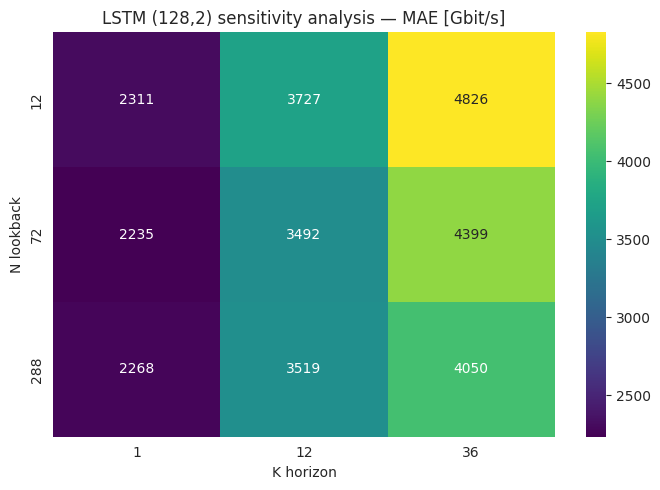

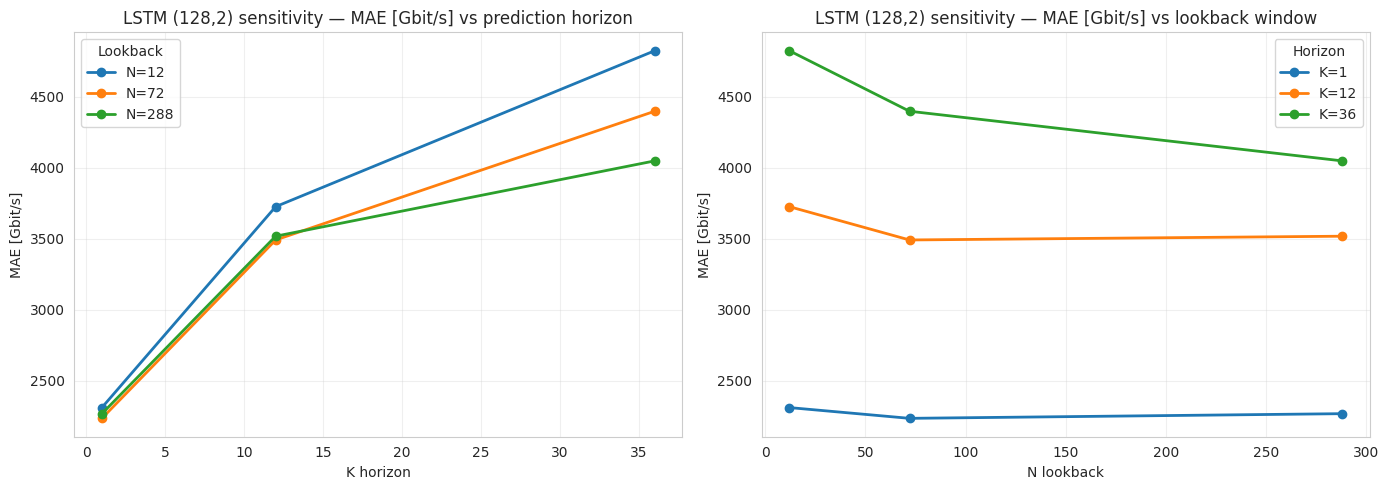

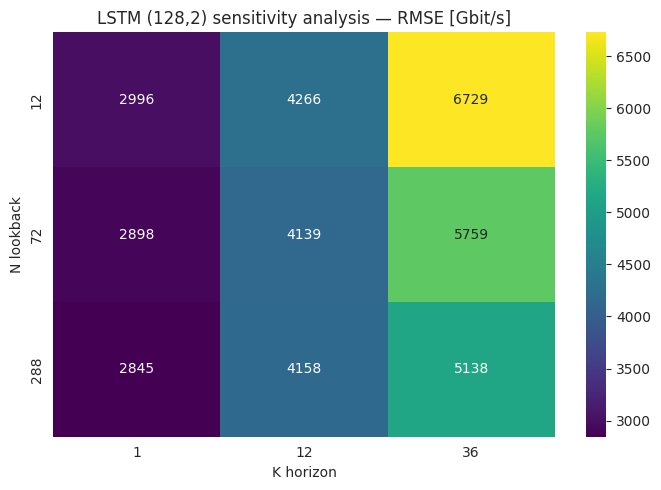

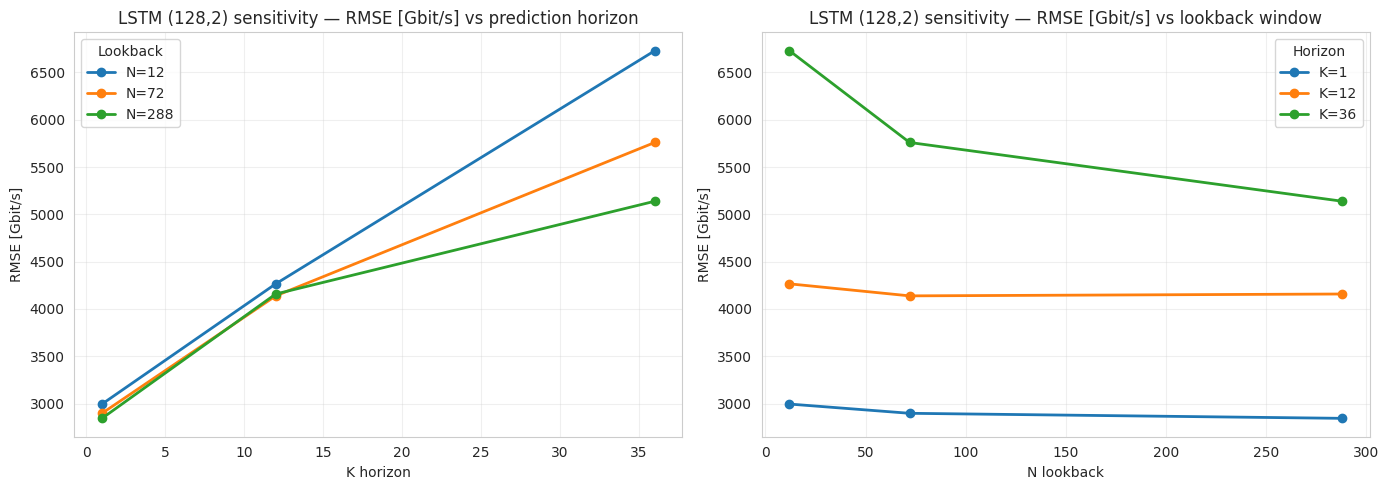

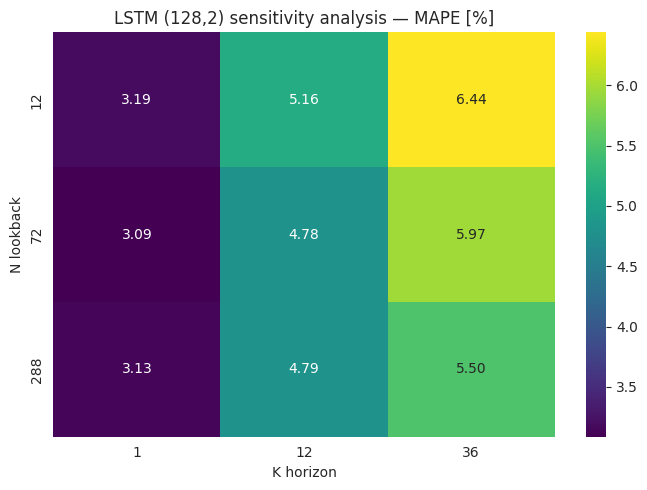

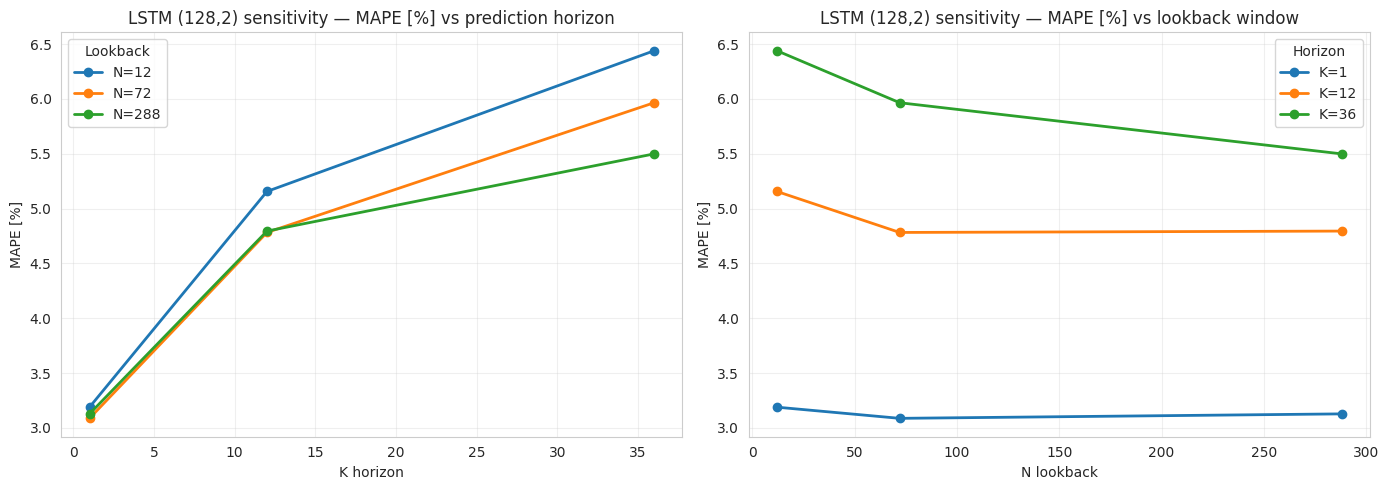

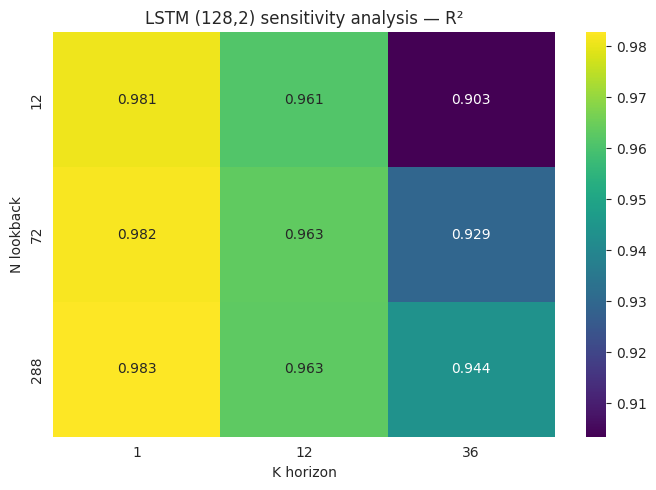

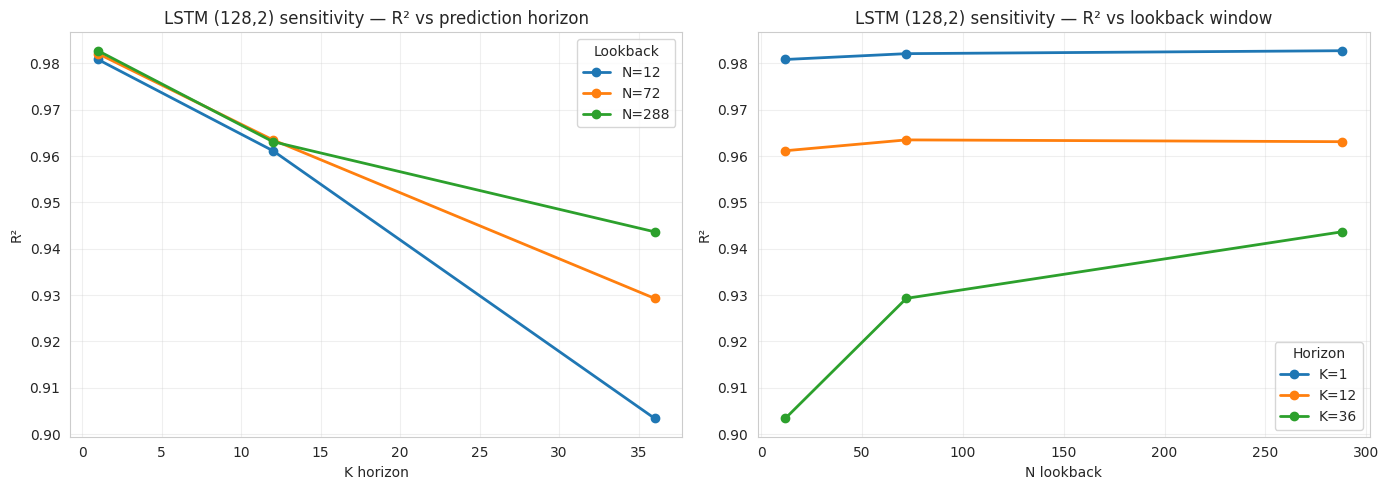

In [54]:
# ===============================
# LSTM (128,2) SENSITIVITY VISUALIZATION
# ===============================

metrics_to_plot = [
    ("MAE_Gbit_s", "MAE [Gbit/s]", ".0f"),
    ("RMSE_Gbit_s", "RMSE [Gbit/s]", ".0f"),
    ("MAPE_percent", "MAPE [%]", ".2f"),
    ("R2", "R²", ".3f"),
]

for metric, metric_label, fmt in metrics_to_plot:

    # Heatmap
    pivot_metric = lstm_sensitivity.pivot(
        index="N",
        columns="K",
        values=metric
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        pivot_metric,
        annot=True,
        fmt=fmt,
        cmap="viridis"
    )

    plt.title(f"LSTM (128,2) sensitivity analysis — {metric_label}")
    plt.xlabel("K horizon")
    plt.ylabel("N lookback")
    plt.tight_layout()
    plt.show()

    # Line plots
    plt.figure(figsize=(14, 5))

    # Metric vs K horizon, one line for each N
    plt.subplot(1, 2, 1)

    for N in sorted(lstm_sensitivity["N"].unique()):
        subset = lstm_sensitivity[
            lstm_sensitivity["N"] == N
        ].sort_values("K")

        plt.plot(
            subset["K"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"N={N}"
        )

    plt.title(f"LSTM (128,2) sensitivity — {metric_label} vs prediction horizon")
    plt.xlabel("K horizon")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Lookback")

    # Metric vs N lookback, one line for each K
    plt.subplot(1, 2, 2)

    for K in sorted(lstm_sensitivity["K"].unique()):
        subset = lstm_sensitivity[
            lstm_sensitivity["K"] == K
        ].sort_values("N")

        plt.plot(
            subset["N"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=f"K={K}"
        )

    plt.title(f"LSTM (128,2) sensitivity — {metric_label} vs lookback window")
    plt.xlabel("N lookback")
    plt.ylabel(metric_label)
    plt.grid(alpha=0.3)
    plt.legend(title="Horizon")

    plt.tight_layout()
    plt.savefig(
        DATA_DIR / f"lstm_128_2_sensitivity_{metric}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

## **S4.3 - GRU Forecasting**

The GRU is a recurrent model similar to the LSTM but with a simpler gating mechanism: two gates (update and reset) instead of the LSTM's three, and no separate cell state. The result is roughly 25% fewer parameters for the same hidden_size, faster training and, on signals with mostly short-range dependencies, often comparable accuracy.

We reuse all of the LSTM infrastructure from S4.2 (training loop, cross-validation splitter, dataloaders, scaler, sliding-window tensors), so that the LSTM-vs-GRU comparison is meaningful: both models see the same data under the same training protocol, and the only thing that changes between S4.2 and S4.3 is the model class.


### **S4.3.1 - Configuration & hyperparameter grid**

This cell defines both the final-training settings and the cross-validation grid.

For the final training, GRU_MAX_EPOCHS = 30 is the maximum number of epochs once the winning configuration has been chosen, and GRU_PATIENCE = 5 stops the training early if the validation loss does not improve for 5 consecutive epochs.

For the cross-validation, GRU_PARAM_GRID contains five configurations spanning hidden size (32 to 128), depth (1 or 2 layers), dropout (0 or 0.1) and learning rate (1e-3 or 3e-4). The grid is kept small on purpose: the goal is to pick a reasonable configuration to compare against the LSTM, not to search the hyperparameter space exhaustively. The CV stage runs on a reduced budget (GRU_CV_FOLDS = 3, GRU_CV_EPOCHS = 8, GRU_CV_PATIENCE = 3): cross-validation ranks the configurations cheaply, then the winner is re-trained with the full GRU_MAX_EPOCHS budget on the original train/validation split.


In [ ]:
# ========================
# GRU CONFIGURATION
# ========================

GRU_MAX_EPOCHS = 30
GRU_PATIENCE = 5

GRU_PARAM_GRID = [
    {"hidden_size": 32, "num_layers": 1, "dropout": 0.0, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 1, "dropout": 0.0, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 2, "dropout": 0.1, "learning_rate": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.1, "learning_rate": 1e-3},
    {"hidden_size": 64, "num_layers": 2, "dropout": 0.1, "learning_rate": 3e-4},
]

GRU_CV_FOLDS = 3
GRU_CV_EPOCHS = 8
GRU_CV_PATIENCE = 3

### **S4.3.2 - GRU model definition**

GRUForecaster is a thin wrapper around PyTorch's nn.GRU plus a linear projection head.

The input batch of shape (batch_size, N_LOOKBACK) is reshaped to (batch_size, N_LOOKBACK, 1), since the GRU expects an explicit feature dimension even though our input has a single channel (throughput). It then goes through a stack of num_layers GRU cells with hidden_size units each; dropout is applied between layers (not inside the recurrence), and PyTorch only activates it when num_layers > 1, which is why the constructor guards on that condition. The output at the last time step is taken as a summary of the input window (the standard sequence-to-vector pattern), and a single Linear(hidden_size, horizon) layer emits all K predictions in one forward pass, the same direct multi-output strategy used by the LSTM.

The architecture mirrors LSTMForecaster (S4.2.3) component by component, swapping only the recurrent cell, so any difference in performance comes from the cell and not from the rest of the network.


In [ ]:
# ========================
# GRU model
# ========================

class GRUForecaster(nn.Module):
    def __init__(
        self,
        horizon,
        hidden_size=64,
        num_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):
        x = x.unsqueeze(-1)

        output, _ = self.gru(x)

        last_hidden = output[:, -1, :]

        prediction = self.head(last_hidden)

        return prediction

### **S4.3.3 - Reusable GRU training function**

train_gru_model is a simple pass-through to train_lstm_model (defined in S4.2.4). Both models share the same input/output shapes, loss function (MSE on standardized targets), optimizer (Adam) and early-stopping logic, so there is no reason to duplicate the training loop.

Reusing the same training function also guarantees a fair comparison: both models see the same number of gradient updates per epoch, are early-stopped with the same patience and tolerance, and their training_time_seconds is measured by the same code path, which matters for the timing comparison in S4.6.


In [ ]:
# ================================
# REUSABLE GRU TRAINING FUNCTION
# ================================

def train_gru_model(
    model,
    X_train,
    Y_train,
    X_validation,
    Y_validation,
    learning_rate,
    max_epochs,
    patience,
    batch_size,
    verbose=True
):
    return train_lstm_model(
        model=model,
        X_train=X_train,
        Y_train=Y_train,
        X_validation=X_validation,
        Y_validation=Y_validation,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        batch_size=batch_size,
        verbose=verbose
    )

### **S4.3.4 - Expanding-window cross-validation**

evaluate_gru_config_cv runs expanding-window cross-validation on the training split, identical in structure to the LSTM CV (S4.2.5).

The training series is split into n_folds expanding folds via expanding_window_cv_splits: each fold uses more history for training than the previous one, never less, which mimics how the model would actually be used (always trained on all data up to a cutoff, then applied to the future). For each fold, a fresh Standardizer is fitted on that fold's training portion only (to avoid leakage), windows are built on the standardized series, and a fresh GRUForecaster with the candidate hyperparameters is trained with a reduced epoch budget. The best validation MSE of each fold is recorded, and the function returns mean and standard deviation across folds.

The standard deviation is reported alongside the mean to tell whether a configuration is genuinely better or just lucky on one fold.

In [ ]:
# ========================
# GRU cross-validation
# ========================

def evaluate_gru_config_cv(
    train_values,
    params,
    n_lookback=N_LOOKBACK,
    k_horizon=K_HORIZON,
    n_folds=GRU_CV_FOLDS,
    cv_epochs=GRU_CV_EPOCHS,
    patience=GRU_CV_PATIENCE
):
    fold_losses = []

    for fold, fold_train_raw, fold_validation_raw in expanding_window_cv_splits(
        train_values,
        n_folds=n_folds,
        validation_fraction=0.15
    ):
        print(f"Fold {fold}/{n_folds}")

        fold_scaler = Standardizer().fit(fold_train_raw)

        X_fold_train, Y_fold_train = make_windows(
            fold_scaler.transform(fold_train_raw),
            n_lookback,
            k_horizon,
            stride=TRAIN_STRIDE
        )

        X_fold_validation, Y_fold_validation = make_windows(
            fold_scaler.transform(fold_validation_raw),
            n_lookback,
            k_horizon,
            stride=k_horizon
        )

        fold_model = GRUForecaster(
            horizon=k_horizon,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            dropout=params["dropout"]
        )

        _, _, best_validation_loss, _ = train_gru_model(
            model=fold_model,
            X_train=X_fold_train,
            Y_train=Y_fold_train,
            X_validation=X_fold_validation,
            Y_validation=Y_fold_validation,
            learning_rate=params["learning_rate"],
            max_epochs=cv_epochs,
            patience=patience,
            batch_size=BATCH_SIZE,
            verbose=False
        )

        fold_losses.append(best_validation_loss)

    return float(np.mean(fold_losses)), float(np.std(fold_losses))

### **S4.3.5 - Run cross-validation over the grid**

This cell iterates over every entry in GRU_PARAM_GRID, calls evaluate_gru_config_cv for each, and collects the results into a DataFrame sorted by mean_validation_mse, best configuration on top.

The table is also saved as gru_cross_validation_results.csv in DATA_DIR, so the results can be cited in the report without re-running the CV.

This is the slowest cell in S4.3: it runs len(GRU_PARAM_GRID) * GRU_CV_FOLDS * GRU_CV_EPOCHS forward/backward passes. On a Colab GPU it typically completes in a few minutes.


In [ ]:
# =========================
# RUN GRU CROSS-VALIDATION
# =========================

gru_cv_results_list = []

for i, params in enumerate(GRU_PARAM_GRID, start=1):
    print("=" * 80)
    print(f"Testing GRU configuration {i}/{len(GRU_PARAM_GRID)}")
    print(params)

    mean_validation_mse, std_validation_mse = evaluate_gru_config_cv(
        train_values=train_raw,
        params=params
    )

    gru_cv_results_list.append({
        **params,
        "mean_validation_mse": mean_validation_mse,
        "std_validation_mse": std_validation_mse
    })

gru_cv_results = (
    pd.DataFrame(gru_cv_results_list)
    .sort_values("mean_validation_mse")
)

display(gru_cv_results)

gru_cv_results.to_csv(
    DATA_DIR / "gru_cross_validation_results.csv",
    index=False
)

Testing GRU configuration 1/5
{'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Fold 1/3
Fold 2/3
Fold 3/3
Testing GRU configuration 2/5
{'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Fold 1/3
Fold 2/3
Fold 3/3
Testing GRU configuration 3/5
{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001}
Fold 1/3
Fold 2/3
Fold 3/3
Testing GRU configuration 4/5
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001}
Fold 1/3
Fold 2/3
Fold 3/3
Testing GRU configuration 5/5
{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.0003}
Fold 1/3
Fold 2/3
Fold 3/3


,hidden_size,num_layers,dropout,learning_rate,mean_validation_mse,std_validation_mse
3,128,2,0.1,0.0010,0.028722,0.014033
1,64,1,0.0,0.0010,0.030279,0.013099
2,64,2,0.1,0.0010,0.030821,0.014358
0,32,1,0.0,0.0010,0.031177,0.013909
4,64,2,0.1,0.0003,0.033237,0.013001


### **S4.3.6 - Final training on the winning configuration**

The top row of gru_cv_results (lowest mean validation MSE) gives the winning hyperparameters, which are used to train one final GRU on the original train/validation split, not on the CV folds. This produces a single model rather than an ensemble of fold models, a training_time_seconds measured on the same split the LSTM used (so the timing comparison in S4.6 is fair), and a learning curve (gru_history) that can be inspected to check convergence.

The full GRU_MAX_EPOCHS budget is used here, since the CV stage ran on a reduced budget just to rank the configurations.


In [ ]:
# ========================
# FINAL GRU TRAINING
# ========================

best_gru_params = gru_cv_results.iloc[0]

BEST_GRU_HIDDEN_SIZE = int(best_gru_params["hidden_size"])
BEST_GRU_NUM_LAYERS = int(best_gru_params["num_layers"])
BEST_GRU_DROPOUT = float(best_gru_params["dropout"])
BEST_GRU_LEARNING_RATE = float(best_gru_params["learning_rate"])

gru_model = GRUForecaster(
    horizon=K_HORIZON,
    hidden_size=BEST_GRU_HIDDEN_SIZE,
    num_layers=BEST_GRU_NUM_LAYERS,
    dropout=BEST_GRU_DROPOUT
).to(DEVICE)

gru_model, gru_history, gru_best_validation_loss, gru_training_time = train_gru_model(
    model=gru_model,
    X_train=X_train,
    Y_train=Y_train,
    X_validation=X_validation,
    Y_validation=Y_validation,
    learning_rate=BEST_GRU_LEARNING_RATE,
    max_epochs=GRU_MAX_EPOCHS,
    patience=GRU_PATIENCE,
    batch_size=BATCH_SIZE,
    verbose=True
)

Epoch 01 | train MSE: 0.08197 | validation MSE: 0.04194
Epoch 02 | train MSE: 0.00884 | validation MSE: 0.04089
Epoch 03 | train MSE: 0.00754 | validation MSE: 0.04134
Epoch 04 | train MSE: 0.00675 | validation MSE: 0.03967
Epoch 05 | train MSE: 0.00610 | validation MSE: 0.04101
Epoch 06 | train MSE: 0.00581 | validation MSE: 0.03981
Epoch 07 | train MSE: 0.00570 | validation MSE: 0.04016
Epoch 08 | train MSE: 0.00552 | validation MSE: 0.03892
Epoch 09 | train MSE: 0.00535 | validation MSE: 0.03883
Epoch 10 | train MSE: 0.00532 | validation MSE: 0.03922
Epoch 11 | train MSE: 0.00518 | validation MSE: 0.03947
Epoch 12 | train MSE: 0.00502 | validation MSE: 0.03994
Epoch 13 | train MSE: 0.00500 | validation MSE: 0.04030
Epoch 14 | train MSE: 0.00495 | validation MSE: 0.03992
Early stopping


### **S4.3.7 - Test-set evaluation**

After training, the model is run in .eval() mode (dropout disabled) over test_loader, inside a torch.no_grad() block, and predictions and targets are accumulated in the standardized space.

Since the model was trained on standardized targets, the predictions come out in the standardized scale: scaler.inverse(...) brings both predictions and targets back to Gbit/s before computing the metrics, so the MAE and RMSE are expressed in the same physical units used by every other model in the comparison.

The four metrics from S3.7 are printed as a quick sanity check and saved in the next cell.

In [ ]:
# ========================
# GRU TEST EVALUATION
# ========================

gru_model.eval()

gru_predictions_scaled = []
gru_targets_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        pred = gru_model(xb).cpu().numpy()

        gru_predictions_scaled.append(pred)
        gru_targets_scaled.append(yb.numpy())

gru_predictions_scaled = np.concatenate(gru_predictions_scaled)
gru_targets_scaled = np.concatenate(gru_targets_scaled)

gru_predictions = scaler.inverse(gru_predictions_scaled)
gru_targets = scaler.inverse(gru_targets_scaled)

gru_y_pred = gru_predictions.ravel()
gru_y_true = gru_targets.ravel()

gru_mae, gru_rmse, gru_mape, gru_r2 = compute_regression_metrics(
    gru_y_true,
    gru_y_pred
)

print(f"GRU MAE  [Gbit/s]: {gru_mae:.2f}")
print(f"GRU RMSE [Gbit/s]: {gru_rmse:.2f}")
print(f"GRU MAPE [%]:     {gru_mape:.2f}")
print(f"GRU R2:           {gru_r2:.4f}")

GRU MAE  [Gbit/s]: 3532.19
GRU RMSE [Gbit/s]: 4072.45
GRU MAPE [%]:     4.85
GRU R2:           0.9646


### **S4.3.8 - Save GRU metrics**

gru_metrics is saved as a single-row DataFrame with the same schema as rf_metrics, lstm_metrics, arima_metrics and tsfm_metrics, since the S4.6 comparison cell simply concatenates the five frames.

The row also includes the winning hyperparameters (hidden_size, num_layers, dropout, learning_rate) and the CV validation MSE. These columns are absent from the RF/ARIMA/TSFM rows, but pd.concat in S4.6 fills them with NaN in the merged table, so nothing breaks.

In [ ]:
# ========================
# SAVE GRU METRICS
# ========================

gru_metrics = pd.DataFrame([
    {
        "model": "GRU",
        "N": N_LOOKBACK,
        "K": K_HORIZON,
        "hidden_size": BEST_GRU_HIDDEN_SIZE,
        "num_layers": BEST_GRU_NUM_LAYERS,
        "dropout": BEST_GRU_DROPOUT,
        "learning_rate": BEST_GRU_LEARNING_RATE,
        "cv_validation_mse": best_gru_params["mean_validation_mse"],
        "MAE_Gbit_s": gru_mae,
        "RMSE_Gbit_s": gru_rmse,
        "MAPE_percent": gru_mape,
        "R2": gru_r2,
        "training_time_seconds": gru_training_time,
    }
])

display(gru_metrics)

gru_metrics.to_csv(
    DATA_DIR / "gru_metrics.csv",
    index=False
)

,model,N,K,hidden_size,num_layers,dropout,learning_rate,cv_validation_mse,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
0,GRU,72,12,128,2,0.1,0.001,0.028722,3532.191895,4072.446562,4.852595,0.964642,28.778393


### **S4.3.9 - GRU sensitivity analysis over N and K**

The same (N, K) sweep used for the LSTM is repeated here, keeping fixed the best GRU hyperparameters selected by cross-validation, so that the effect of lookback length and forecast horizon is isolated from architecture tuning.

The output schema matches lstm_sensitivity and rf_sensitivity, so the GRU can be included directly in the final all-model sensitivity comparison.

In [ ]:
# ========================================
# GRU SENSITIVITY ANALYSIS WITH CHECKPOINT
# ========================================

GRU_SENSITIVITY_FILE_PATH = DATA_DIR / "gru_sensitivity_NK.csv"


def run_gru_experiment(
    n_lookback,
    k_horizon,
    max_epochs=12,
    patience=3,
    train_stride=TRAIN_STRIDE,
):
    X_train_exp, Y_train_exp = make_windows(
        train_scaled,
        n_lookback,
        k_horizon,
        stride=train_stride
    )

    X_validation_exp, Y_validation_exp = make_windows(
        validation_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    X_test_exp, Y_test_exp = make_windows(
        test_scaled,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    experiment_model = GRUForecaster(
        horizon=k_horizon,
        hidden_size=BEST_GRU_HIDDEN_SIZE,
        num_layers=BEST_GRU_NUM_LAYERS,
        dropout=BEST_GRU_DROPOUT
    ).to(DEVICE)

    experiment_model, _, _, experiment_training_time = train_gru_model(
        model=experiment_model,
        X_train=X_train_exp,
        Y_train=Y_train_exp,
        X_validation=X_validation_exp,
        Y_validation=Y_validation_exp,
        learning_rate=BEST_GRU_LEARNING_RATE,
        max_epochs=max_epochs,
        patience=patience,
        batch_size=BATCH_SIZE,
        verbose=False
    )

    test_loader_exp = make_loader(
        X_test_exp,
        Y_test_exp,
        BATCH_SIZE,
        shuffle=False
    )

    experiment_model.eval()

    predictions_scaled_exp = []
    targets_scaled_exp = []

    with torch.no_grad():
        for xb, yb in test_loader_exp:
            xb = xb.to(DEVICE)

            pred = experiment_model(xb).cpu().numpy()

            predictions_scaled_exp.append(pred)
            targets_scaled_exp.append(yb.numpy())

    predictions_scaled_exp = np.concatenate(predictions_scaled_exp)
    targets_scaled_exp = np.concatenate(targets_scaled_exp)

    predictions_exp = scaler.inverse(predictions_scaled_exp)
    targets_exp = scaler.inverse(targets_scaled_exp)

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    return {
        "model": "GRU",
        "N": n_lookback,
        "K": k_horizon,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": experiment_training_time,
        "train_windows": len(X_train_exp),
        "validation_windows": len(X_validation_exp),
        "test_windows": len(X_test_exp),
    }


if GRU_SENSITIVITY_FILE_PATH.exists():
    gru_sensitivity = pd.read_csv(GRU_SENSITIVITY_FILE_PATH)
    gru_sensitivity_results = gru_sensitivity.to_dict("records")

    completed_pairs = set(
        zip(
            gru_sensitivity["N"].astype(int),
            gru_sensitivity["K"].astype(int)
        )
    )

    print("Loaded previous checkpoint:")
    print(GRU_SENSITIVITY_FILE_PATH)
    print("Completed experiments:", completed_pairs)

else:
    gru_sensitivity_results = []
    completed_pairs = set()

    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:
        if (N, K) in completed_pairs:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running GRU sensitivity experiment: N={N}, K={K}")

        result = run_gru_experiment(
            n_lookback=N,
            k_horizon=K,
            max_epochs=12,
            patience=3,
            train_stride=TRAIN_STRIDE,
        )

        gru_sensitivity_results.append(result)
        completed_pairs.add((N, K))

        gru_sensitivity = pd.DataFrame(gru_sensitivity_results)
        gru_sensitivity.to_csv(
            GRU_SENSITIVITY_FILE_PATH,
            index=False
        )

        print(result)
        print("Checkpoint saved:", GRU_SENSITIVITY_FILE_PATH)


gru_sensitivity = pd.DataFrame(gru_sensitivity_results)

display(gru_sensitivity)

print("Final saved file:", GRU_SENSITIVITY_FILE_PATH)

Loaded previous checkpoint:
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/gru_sensitivity_NK.csv
Completed experiments: {(72, 12), (12, 1), (12, 36), (288, 12), (72, 1), (72, 36), (12, 12), (288, 1), (288, 36)}
Skipping already completed experiment: N=12, K=1
Skipping already completed experiment: N=12, K=12
Skipping already completed experiment: N=12, K=36
Skipping already completed experiment: N=72, K=1
Skipping already completed experiment: N=72, K=12
Skipping already completed experiment: N=72, K=36
Skipping already completed experiment: N=288, K=1
Skipping already completed experiment: N=288, K=12
Skipping already completed experiment: N=288, K=36


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,train_windows,validation_windows,test_windows
0,GRU,12,1,2367.717773,3032.853607,3.262804,0.980356,6.535143,49120,31567,31568
1,GRU,12,12,3838.483154,4401.808492,5.426667,0.958627,8.577683,49116,2630,2630
2,GRU,12,36,4151.330566,5442.713294,5.687780,0.936791,5.981566,49108,876,876
3,GRU,72,1,2406.372070,3111.810888,3.286487,0.979352,13.941221,49100,31507,31508
4,GRU,72,12,3549.297607,4147.464768,4.860263,0.963327,18.503198,49096,2625,2625
5,GRU,72,36,4509.076172,6340.331853,6.112518,0.914296,15.590321,49088,875,875
6,GRU,288,1,2400.860840,3096.440053,3.297557,0.979534,38.305959,49028,31291,31292
7,GRU,288,12,3638.329102,4138.294576,5.001793,0.963450,86.982636,49024,2607,2607
8,GRU,288,36,3739.639893,4479.630342,5.185260,0.957172,93.931421,49016,869,869


Final saved file: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/gru_sensitivity_NK.csv


### **S4.3.10 - GRU sensitivity visualization**

The heatmap and line plots summarize how the GRU error changes with the lookback window `N` and the forecasting horizon `K`.

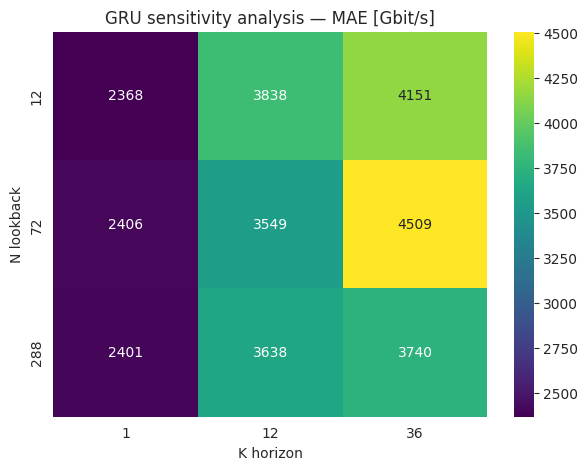

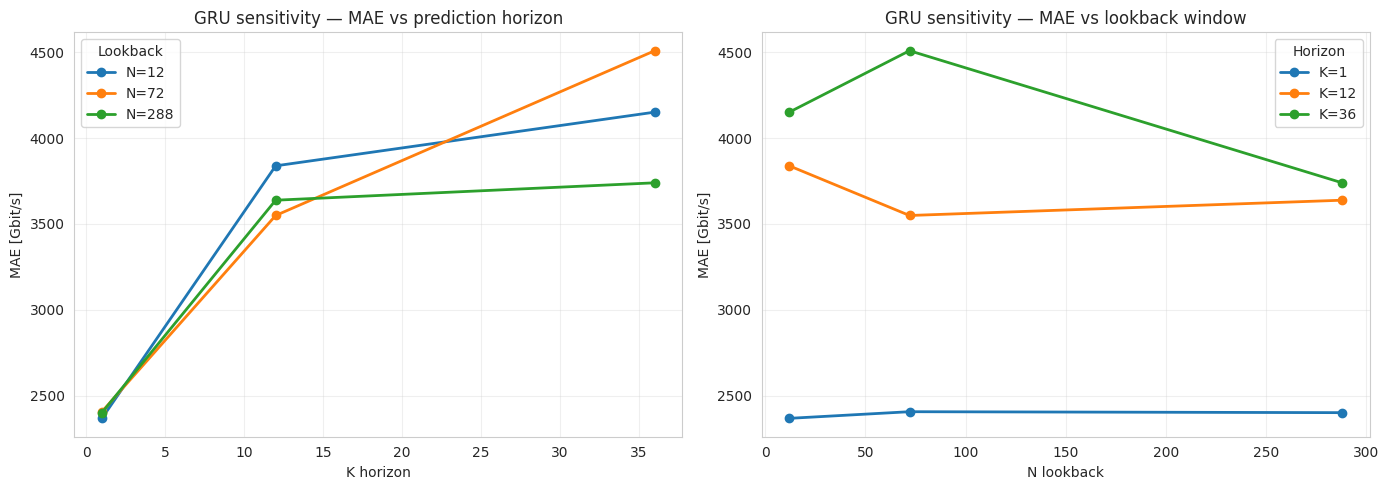

In [ ]:
# ==============================
# GRU SENSITIVITY VISUALIZATION
# ==============================

pivot_mae_gru = gru_sensitivity.pivot(
    index="N",
    columns="K",
    values="MAE_Gbit_s"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    pivot_mae_gru,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title("GRU sensitivity analysis — MAE [Gbit/s]")
plt.xlabel("K horizon")
plt.ylabel("N lookback")
plt.show()


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

for N in sorted(gru_sensitivity["N"].unique()):
    subset = gru_sensitivity[
        gru_sensitivity["N"] == N
    ].sort_values("K")

    plt.plot(
        subset["K"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"N={N}"
    )

plt.title("GRU sensitivity — MAE vs prediction horizon")
plt.xlabel("K horizon")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Lookback")


plt.subplot(1, 2, 2)

for K in sorted(gru_sensitivity["K"].unique()):
    subset = gru_sensitivity[
        gru_sensitivity["K"] == K
    ].sort_values("N")

    plt.plot(
        subset["N"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"K={K}"
    )

plt.title("GRU sensitivity — MAE vs lookback window")
plt.xlabel("N lookback")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Horizon")

plt.tight_layout()
plt.savefig(
    DATA_DIR / "gru_sensitivity_lineplots.png",
    dpi=150
)
plt.show()

### **S4.3.11 - Reading the GRU sensitivity results**

The GRU sensitivity grid should be read next to the LSTM grid. Both are recurrent models, so the interesting question is not whether the GRU can exploit temporal order (it can), but whether its simpler gating changes how the forecast degrades when N and K vary.

Two things to check. First, the horizon effect: if the GRU behaves like the LSTM, MAE should increase mainly along the K axis, confirming that forecast distance is the dominant source of difficulty. Second, the lookback effect: if the GRU curve flattens after N = 72, then 6 hours of context are enough for the recurrent state to reconstruct the diurnal phase; if N = 288 still improves the error clearly, the full daily cycle is useful even for this lighter architecture.

In this sense the GRU also works as a robustness check on the LSTM result: it tells whether that result depends on the LSTM cell specifically or holds for recurrent models in general.

## **S4.4 - ARIMA**

ARIMA(AutoRegressive Integrated Moving Average) is the classical statistical baseline required by the assignment. Unlike the recurrent neural networks, ARIMA does not learn weights from a training set: each forecast is produced by fitting a fresh ARIMA(p, d, q) model on the lookback window itself and rolling forward by `K` steps.

This per-window protocol is the same one used by the Chronos TSFM later in S4.5, and uses the same N_LOOKBACK / K_HORIZON defined in S3, so the resulting arima_metrics row is directly comparable with the other models in S4.6.

The order `(p, d, q)` is fixed in S4.4.1 based on the stationarity and autocorrelation analysis from S1.6 — auto-tuning per window would be prohibitively slow on this many test points.


### **S4.4.1 - ARIMA configuration**


In [23]:
# ========================
# ARIMA CONFIGURATION
# ========================

import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# context length per window
ARIMA_LOOKBACK = N_LOOKBACK
# forecast horizon per window
ARIMA_HORIZON  = K_HORIZON
# non-overlapping windows
ARIMA_STRIDE   = K_HORIZON
# cap optimizer iterations per window
ARIMA_MAX_ITER = 50

# statsmodels is verbose
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", ValueWarning)
warnings.simplefilter("ignore", UserWarning)

print("Context length:", ARIMA_LOOKBACK)
print("Forecast horizon:", ARIMA_HORIZON)


Context length: 72
Forecast horizon: 12


### **S4.4.2 - Build ARIMA test windows**

Reusing the make_windows helper from S3.6 to produce non-overlapping windows, with the same protocol used for the Chronos TSFM in S4.5.

Unlike the neural models, ARIMA works here on the raw (non-standardized) series: standardizing would only produce predictions in the standardized scale that we would then have to invert back. Using raw Gbit/s keeps the pipeline simpler and the predictions directly comparable.

In [27]:
# =========================
# BUILD ARIMA TEST WINDOWS
# =========================

X_test_arima, Y_test_arima = make_windows(
    test_raw,
    ARIMA_LOOKBACK,
    ARIMA_HORIZON,
    stride=ARIMA_STRIDE
)

print("ARIMA test windows:", X_test_arima.shape, Y_test_arima.shape)

ARIMA test windows: (2625, 72) (2625, 12)


In [24]:
# ===================================
# BUILD ARIMA VALIDATION WINDOWS
# ===================================

X_validation_arima, Y_validation_arima = make_windows(
    validation_raw,
    ARIMA_LOOKBACK,
    ARIMA_HORIZON,
    stride=ARIMA_STRIDE
)

print("ARIMA validation windows:", X_validation_arima.shape, Y_validation_arima.shape)

ARIMA validation windows: (2625, 72) (2625, 12)


### **S4.4.2b - Selecting the order empirically: AIC/BIC comparison**

The PACF analysis in S1.6 pointed to an AR order in the 3-7 range, and the truncating PACF with decaying ACF suggested a pure AR model (q = 0). That reading is qualitative though, so instead of committing to an order by eye we compare a handful of candidate orders on a small sample of test windows using AIC and BIC (lower is better; both penalize extra parameters).

This is a targeted comparison, not a grid search: the candidates cover the AR range suggested by the PACF, plus a couple of MA variants to test the q = 0 reading. Running it on about 20 windows keeps the cost negligible compared to the full per-window evaluation. The final order is fixed only in S4.4.2d, after the out-of-sample check.

In [36]:
# =============================================
# AIC/BIC COMPARISON OF CANDIDATE ARIMA ORDERS
# =============================================

CANDIDATE_ORDERS = [
    (3, 1, 0),
    (5, 1, 0),
    (9,1,0),
    (7, 1, 0),
    (5, 1, 1),
    (3, 1, 1),
]

# Sample 20 windows evenly spaced across the test period
n_sample = min(20, len(X_validation_arima))
sample_idx = np.linspace(0, len(X_validation_arima) - 1, n_sample, dtype=int)

order_comparison_rows = []

for order in CANDIDATE_ORDERS:
    aics, bics, fails = [], [], 0

    for idx in sample_idx:
        try:
            fitted = ARIMA(
                X_validation_arima[idx],
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(method_kwargs={"maxiter": ARIMA_MAX_ITER, "disp": 0})

            if np.isfinite(fitted.aic) and np.isfinite(fitted.bic):
                aics.append(fitted.aic)
                bics.append(fitted.bic)
            else:
                fails += 1
        except Exception:
            fails += 1

    order_comparison_rows.append({
        "order": str(order),
        "mean_AIC": np.mean(aics) if aics else np.nan,
        "mean_BIC": np.mean(bics) if bics else np.nan,
        "failed_windows": fails,
    })

order_comparison = (
    pd.DataFrame(order_comparison_rows)
    .sort_values("mean_BIC")
    .reset_index(drop=True)
)

print(f"Candidate order comparison on {n_sample} sample VALIDATION windows:")
display(order_comparison)


Candidate order comparison on 20 sample VALIDATION windows:


,order,mean_AIC,mean_BIC,failed_windows
0,"(9, 1, 0)",1024.183193,1045.454537,0
1,"(7, 1, 0)",1056.858097,1074.129161,0
2,"(5, 1, 0)",1106.634490,1119.772419,0
3,"(5, 1, 1)",1105.833860,1121.161443,0
4,"(3, 1, 0)",1152.250655,1161.128686,0
5,"(3, 1, 1)",1151.025574,1162.123113,0


### **S4.4.2c - Out-of-sample MAE tie-break**

In [37]:
# =============================
# OUT-OF-SAMPLE MAE COMPARISON
# =============================

MAE_CANDIDATE_ORDERS = [
    (5, 1, 0),
    (7, 1, 0),
    (9, 1, 0),
]

mae_comparison_rows = []

for order in MAE_CANDIDATE_ORDERS:
    abs_errors, fails = [], 0

    for idx in sample_idx:
        try:
            fitted = ARIMA(
                X_validation_arima[idx],
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(method_kwargs={"maxiter": ARIMA_MAX_ITER, "disp": 0})

            forecast = np.asarray(
                fitted.forecast(steps=ARIMA_HORIZON), dtype=np.float32
            )
            if not np.all(np.isfinite(forecast)):
                raise ValueError("non-finite forecast")

            abs_errors.append(
                np.abs(forecast - Y_validation_arima[idx]).mean()
            )
        except Exception:
            fails += 1

    mae_comparison_rows.append({
        "order": str(order),
        "mean_MAE_Gbit_s": np.mean(abs_errors) if abs_errors else np.nan,
        "failed_windows": fails,
    })

mae_comparison = (
    pd.DataFrame(mae_comparison_rows)
    .sort_values("mean_MAE_Gbit_s")
    .reset_index(drop=True)
)

print(f"Out-of-sample MAE comparison on {n_sample} VALIDATION windows (K = {ARIMA_HORIZON} steps):")
display(mae_comparison)


Out-of-sample MAE comparison on 20 VALIDATION windows (K = 12 steps):


,order,mean_MAE_Gbit_s,failed_windows
0,"(9, 1, 0)",2168.328857,0
1,"(7, 1, 0)",2468.060791,0
2,"(5, 1, 0)",2697.138428,0


### **S4.4.2d - Fix the final ARIMA order**
On validation, all three criteria — AIC, BIC and out-of-sample MAE — prefer (9,1,0) at N=72. We kept (7,1,0) because the sensitivity study needs a single order across N ∈ {12, 72, 288}, and at N=12 a p=9 model estimates 10 parameters from 11 differenced observations — one degree of freedom, effectively degenerate.

In [39]:
# ========================
# FINAL ARIMA ORDER
# ========================

ARIMA_ORDER = (7, 1, 0)

print("ARIMA order:", ARIMA_ORDER)


ARIMA order: (7, 1, 0)


### **S4.4.3 - Run per-window ARIMA forecasting**

For each test window we:

1. Fit an `ARIMA(p, d, q)` model on the `N` context observations.
2. Forecast the next `K` steps with `model.forecast(K)`.
3. Store the predictions.

A `try/except` guard handles the (rare) case where the optimizer fails to converge or produces invalid forecasts on a degenerate window. In that case we fall back to a persistence forecast, repeating the last observed value `K` times.


In [40]:
# =============================
# ARIMA PER-WINDOW FORECASTING
# =============================

from tqdm.auto import tqdm

arima_predictions_list = []
arima_failures = 0

start_time = time.time()

for context in tqdm(X_test_arima, desc="ARIMA windows"):
    try:
        model = ARIMA(
            context,
            order=ARIMA_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            method_kwargs={"maxiter": ARIMA_MAX_ITER, "disp": 0}
        )

        forecast = fitted.forecast(steps=ARIMA_HORIZON)
        forecast = np.asarray(forecast, dtype=np.float32)

        # Replace any NaN / inf with persistence as a safety net
        if not np.all(np.isfinite(forecast)):
            raise ValueError("non-finite forecast")

    except Exception:
        # Persistence fallback: repeat the last observed value
        forecast = np.full(ARIMA_HORIZON, context[-1], dtype=np.float32)
        arima_failures += 1

    arima_predictions_list.append(forecast)

arima_inference_time = time.time() - start_time

arima_predictions = np.stack(arima_predictions_list)
arima_targets     = Y_test_arima

print("ARIMA predictions shape:", arima_predictions.shape)
print(f"ARIMA inference time:    {arima_inference_time:.1f} s")
print(f"ARIMA fallback windows:  {arima_failures} / {len(X_test_arima)}")


ARIMA windows:   0%|          | 0/2625 [00:00<?, ?it/s]

ARIMA predictions shape: (2625, 12)
ARIMA inference time:    135.6 s
ARIMA fallback windows:  0 / 2625


### **S4.4.4 - Evaluate ARIMA**

We flatten the `(n_windows, K)` prediction and target arrays so the metric helper from S3.7 treats every 5-minute step as a separate observation, exactly as it does for the other models.


In [41]:
# ========================
# Evaluate ARIMA
# ========================

arima_y_pred = arima_predictions.ravel()
arima_y_true = arima_targets.ravel()

arima_mae, arima_rmse, arima_mape, arima_r2 = compute_regression_metrics(
    arima_y_true,
    arima_y_pred
)

print(f"ARIMA MAE  [Gbit/s]: {arima_mae:.2f}")
print(f"ARIMA RMSE [Gbit/s]: {arima_rmse:.2f}")
print(f"ARIMA MAPE [%]:      {arima_mape:.2f}")
print(f"ARIMA R2:            {arima_r2:.4f}")


ARIMA MAE  [Gbit/s]: 2065.58
ARIMA RMSE [Gbit/s]: 3638.31
ARIMA MAPE [%]:      3.06
ARIMA R2:            0.9718


### **S4.4.5 - ARIMA forecast visualization**



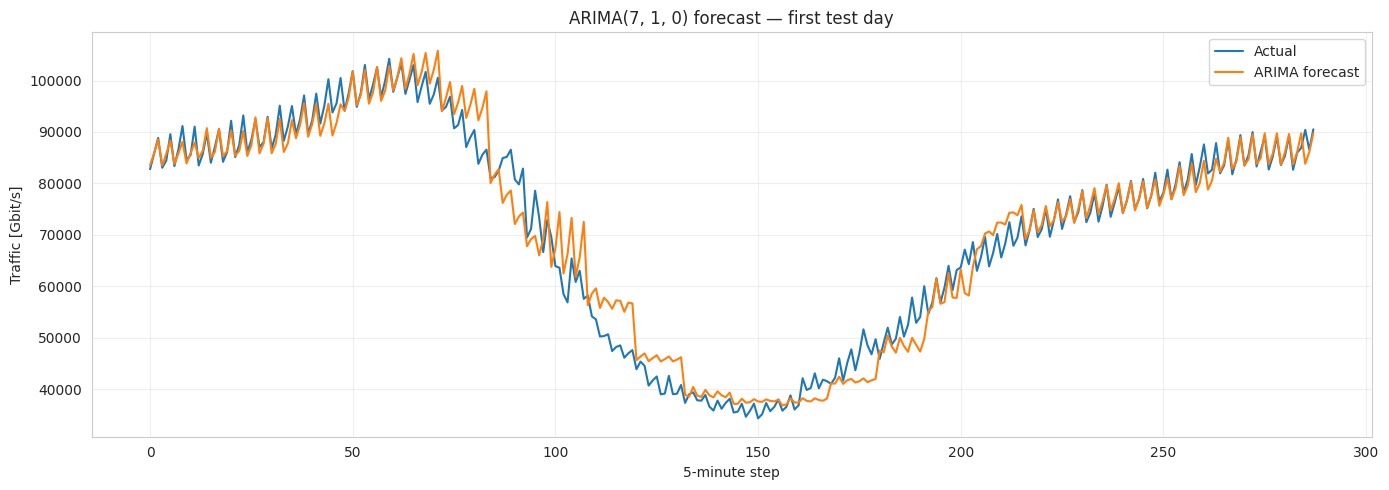

In [42]:
# ==============================
# ARIMA FORECAST VISUALIZZATION
# ==============================

first_day_windows = (24 * 12) // ARIMA_HORIZON

plt.figure(figsize=(14, 5))

plt.plot(
    arima_targets[:first_day_windows].ravel(),
    label="Actual"
)

plt.plot(
    arima_predictions[:first_day_windows].ravel(),
    label="ARIMA forecast"
)

plt.title(f"ARIMA{ARIMA_ORDER} forecast — first test day")
plt.xlabel("5-minute step")
plt.ylabel("Traffic [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### **S4.4.6 - Save ARIMA metrics**




In [ ]:
# ========================
# SAVE ARIMA METRICS
# ========================

arima_metrics = pd.DataFrame([
    {
        "model": f"ARIMA{ARIMA_ORDER}",
        "N": ARIMA_LOOKBACK,
        "K": ARIMA_HORIZON,
        "model_name": f"ARIMA{ARIMA_ORDER}",
        "MAE_Gbit_s": arima_mae,
        "RMSE_Gbit_s": arima_rmse,
        "MAPE_percent": arima_mape,
        "R2": arima_r2,
        "training_time_seconds": 0.0,
        "inference_time_seconds": arima_inference_time,
    }
])

display(arima_metrics)

arima_metrics.to_csv(
    DATA_DIR / "arima_metrics.csv",
    index=False
)

print("Saved:", DATA_DIR / "arima_metrics.csv")


,model,N,K,model_name,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,inference_time_seconds
0,"ARIMA(7, 1, 0)",72,12,"ARIMA(7, 1, 0)",2065.575439,3638.307024,3.060808,0.971779,0.0,143.331107


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/arima_metrics.csv


### **S4.4.7 - ARIMA sensitivity analysis over N and K**

For ARIMA, the sensitivity analysis has a different interpretation from the supervised models. ARIMA is not trained once on the training split; instead, it is fit independently on each test context window. Therefore, varying `N` measures how much context the per-window optimizer needs, while varying `K` measures how quickly the statistical forecast degrades as it moves away from the observed context.

The ARIMA order `(p, d, q)` is kept fixed so the sweep isolates the effect of `N` and `K`.

In [ ]:
# ============================================
# ARIMA SENSITIVITY ANALYSIS WITH CHECKPOINTS
# =============================================

# Checkpoint filename embeds the order, so results computed with a
# different (p, d, q) are never silently reused.
ARIMA_SENSITIVITY_FILE_PATH = (
    DATA_DIR / f"arima_sensitivity_NK_p{ARIMA_ORDER[0]}d{ARIMA_ORDER[1]}q{ARIMA_ORDER[2]}.csv"
)


def run_arima_experiment(
    n_lookback,
    k_horizon,
    stride=None,
):
    if stride is None:
        stride = k_horizon

    X_test_exp, Y_test_exp = make_windows(
        test_raw,
        n_lookback,
        k_horizon,
        stride=stride
    )

    predictions_list = []
    failures = 0

    start = time.time()

    for context in tqdm(X_test_exp, desc=f"ARIMA N={n_lookback}, K={k_horizon}"):
        try:
            model = ARIMA(
                context,
                order=ARIMA_ORDER,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(
                method_kwargs={"maxiter": ARIMA_MAX_ITER, "disp": 0}
            )

            forecast = fitted.forecast(steps=k_horizon)
            forecast = np.asarray(forecast, dtype=np.float32)

            # Sanity bound: if any forecast value exceeds 10x the context
            # range, the model has diverged — fall back to persistence.
            ctx_max = np.max(np.abs(context))
            if not np.all(np.isfinite(forecast)) or np.any(np.abs(forecast) > 10 * max(ctx_max, 1)):
                raise ValueError("divergent or non-finite forecast")

        except Exception:
            forecast = np.full(k_horizon, context[-1], dtype=np.float32)
            failures += 1

        predictions_list.append(forecast)

    inference_time = time.time() - start

    predictions_exp = np.stack(predictions_list)
    targets_exp = Y_test_exp

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    if failures > 0:
        print(f"  ARIMA N={n_lookback}, K={k_horizon}: {failures}/{len(X_test_exp)} windows used persistence fallback")

    return {
        "model": f"ARIMA{ARIMA_ORDER}",
        "N": n_lookback,
        "K": k_horizon,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": 0.0,
        "inference_time_seconds": inference_time,
        "fallback_windows": failures,
        "test_windows": len(X_test_exp),
    }


# Force re-run: delete old checkpoint with divergent values
if ARIMA_SENSITIVITY_FILE_PATH.exists():
    _old = pd.read_csv(ARIMA_SENSITIVITY_FILE_PATH)
    if _old["MAE_Gbit_s"].max() > 1e6:
        print("Detected divergent ARIMA sensitivity results — re-running all experiments.")
        ARIMA_SENSITIVITY_FILE_PATH.unlink()

if ARIMA_SENSITIVITY_FILE_PATH.exists():
    arima_sensitivity = pd.read_csv(ARIMA_SENSITIVITY_FILE_PATH)
    arima_sensitivity_results = arima_sensitivity.to_dict("records")

    completed_pairs = set(
        zip(
            arima_sensitivity["N"].astype(int),
            arima_sensitivity["K"].astype(int)
        )
    )

    print("Loaded previous checkpoint:")
    print(ARIMA_SENSITIVITY_FILE_PATH)
    print("Completed experiments:", completed_pairs)

else:
    arima_sensitivity_results = []
    completed_pairs = set()

    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:
        if (N, K) in completed_pairs:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running ARIMA sensitivity experiment: N={N}, K={K}")

        result = run_arima_experiment(
            n_lookback=N,
            k_horizon=K,
            stride=K,
        )

        arima_sensitivity_results.append(result)
        completed_pairs.add((N, K))

        arima_sensitivity = pd.DataFrame(arima_sensitivity_results)
        arima_sensitivity.to_csv(
            ARIMA_SENSITIVITY_FILE_PATH,
            index=False
        )

        print(result)
        print("Checkpoint saved:", ARIMA_SENSITIVITY_FILE_PATH)


arima_sensitivity = pd.DataFrame(arima_sensitivity_results)

display(arima_sensitivity)

print("Final saved file:", ARIMA_SENSITIVITY_FILE_PATH)

Loaded previous checkpoint:
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/arima_sensitivity_NK_p7d1q0.csv
Completed experiments: {(72, 12), (12, 1), (12, 36), (288, 12), (72, 1), (72, 36), (12, 12), (288, 1), (288, 36)}
Skipping already completed experiment: N=12, K=1
Skipping already completed experiment: N=12, K=12
Skipping already completed experiment: N=12, K=36
Skipping already completed experiment: N=72, K=1
Skipping already completed experiment: N=72, K=12
Skipping already completed experiment: N=72, K=36
Skipping already completed experiment: N=288, K=1
Skipping already completed experiment: N=288, K=12
Skipping already completed experiment: N=288, K=36


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,inference_time_seconds,fallback_windows,test_windows
0,"ARIMA(7, 1, 0)",12,1,1669.862183,2861.524506,2.495829,0.982513,0.0,2436.996295,1,31568
1,"ARIMA(7, 1, 0)",12,12,6474.853027,23429.693297,9.252100,-0.172167,0.0,200.940957,43,2630
2,"ARIMA(7, 1, 0)",12,36,16518.232422,48833.591062,24.974054,-4.088460,0.0,69.682391,149,876
3,"ARIMA(7, 1, 0)",72,1,1030.871704,1585.006940,1.549781,0.994643,0.0,1653.706697,0,31508
4,"ARIMA(7, 1, 0)",72,12,2065.575439,3638.307024,3.060808,0.971779,0.0,136.293957,0,2625
5,"ARIMA(7, 1, 0)",72,36,6195.300781,10011.680378,9.624394,0.786305,0.0,45.495341,0,875
6,"ARIMA(7, 1, 0)",288,1,972.543335,1469.722423,1.458105,0.995389,0.0,3275.015201,0,31292
7,"ARIMA(7, 1, 0)",288,12,2008.978638,3142.090864,2.966816,0.978929,0.0,273.252953,0,2607
8,"ARIMA(7, 1, 0)",288,36,5523.607910,9252.880200,8.631177,0.817274,0.0,92.263321,0,869


Final saved file: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/arima_sensitivity_NK_p7d1q0.csv


### **S4.4.8 - ARIMA sensitivity visualization**

The heatmap and line plots summarize how the per-window ARIMA forecast error changes with context length and prediction horizon.

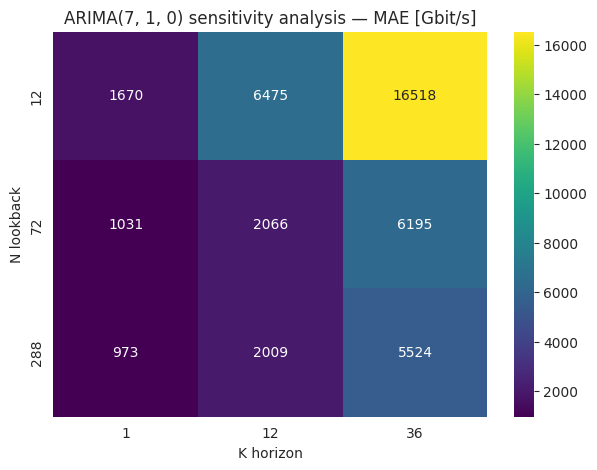

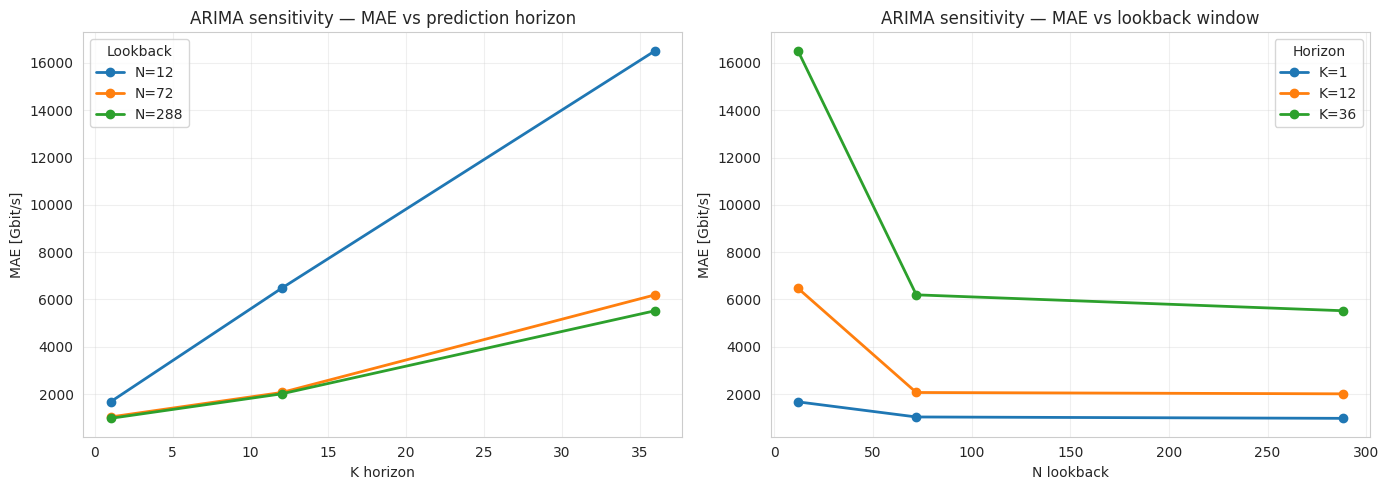

In [ ]:
# =================================
# ARIMA SENSITITIVTY VISUALIZATION
# =================================

pivot_mae_arima = arima_sensitivity.pivot(
    index="N",
    columns="K",
    values="MAE_Gbit_s"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    pivot_mae_arima,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title(f"ARIMA{ARIMA_ORDER} sensitivity analysis — MAE [Gbit/s]")
plt.xlabel("K horizon")
plt.ylabel("N lookback")
plt.show()


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

for N in sorted(arima_sensitivity["N"].unique()):
    subset = arima_sensitivity[
        arima_sensitivity["N"] == N
    ].sort_values("K")

    plt.plot(
        subset["K"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"N={N}"
    )

plt.title("ARIMA sensitivity — MAE vs prediction horizon")
plt.xlabel("K horizon")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Lookback")


plt.subplot(1, 2, 2)

for K in sorted(arima_sensitivity["K"].unique()):
    subset = arima_sensitivity[
        arima_sensitivity["K"] == K
    ].sort_values("N")

    plt.plot(
        subset["N"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"K={K}"
    )

plt.title("ARIMA sensitivity — MAE vs lookback window")
plt.xlabel("N lookback")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Horizon")

plt.tight_layout()
plt.savefig(
    DATA_DIR / "arima_sensitivity_lineplots.png",
    dpi=150
)
plt.show()

### **S4.4.9 - Reading the ARIMA sensitivity results**

ARIMA is expected to be very competitive at short horizons, because each forecast is anchored to the most recent observations. The sensitivity grid shows where that advantage breaks down:

- if increasing K produces a steep MAE increase, ARIMA is good for near-term forecasting but less suitable for longer planning horizons;
- if increasing N helps only weakly, the fitted dynamics are mostly local; if N = 288 helps clearly, the full daily cycle is still informative even though the model is non-seasonal;
- the fallback_windows column is a robustness check: a high count means the optimizer struggled on that (N, K) pair, so the metric should be read together with convergence stability.

A caveat on the N = 12 column: with ARIMA_ORDER = (7, 1, 0), the fit estimates 8 parameters from only 11 differenced observations, which is statistically degenerate. Many windows produce unstable estimates and trigger the persistence fallback, as confirmed by the high fallback_windows count and the negative R2 at K >= 12. Those cells should be read as ARIMA mixed with persistence rather than pure ARIMA, and the degradation reflects estimation instability, not a weakness of the model class: at N = 72 and N = 288 the model fits cleanly and performs well.

## **S4.5 - TSFM Forecasting with Chronos**

A Time-Series Foundation Model (TSFM) baseline using Chronos.

Unlike the LSTM, GRU, and Random Forest, Chronos is not trained from scratch on the Europe IXP dataset, t is a pretrained model that performs zero-shot forecasting: it receives a context window and directly predicts the next `K` time steps. To keep the comparison fair, we use the same test split and the same forecasting horizon `K_HORIZON` used everywhere else.


In [ ]:
# ========================
# Install Chronos
# ========================

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("chronos") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "chronos-forecasting"
    ])

### **S4.5.1 - Load the Chronos model**

We use Chronos-Bolt as the Time-Series Foundation Model. The small version is a reasonable trade-off between accuracy and runtime on Colab.

Chronos internally handles scaling, so we use the original traffic values in Gbit/s rather than the standardized series.

In [ ]:
# ========================
# LOAD CHRONOS MODEL
# ========================

from chronos import BaseChronosPipeline

TSFM_MODEL_NAME = "amazon/chronos-bolt-small"

TSFM_CONTEXT_LENGTH = N_LOOKBACK
TSFM_HORIZON = K_HORIZON

tsfm_pipeline = BaseChronosPipeline.from_pretrained(
    TSFM_MODEL_NAME,
    device_map=DEVICE,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32
)

print("Loaded TSFM model:", TSFM_MODEL_NAME)
print("Context length:", TSFM_CONTEXT_LENGTH)
print("Forecast horizon:", TSFM_HORIZON)

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loaded TSFM model: amazon/chronos-bolt-small
Context length: 72
Forecast horizon: 12


### **S4.5.2 - Build Chronos test windows**

Chronos is evaluated on the test period. Each input window contains the previous `N` raw traffic values, and the target contains the following `K` values.

Unlike LSTM and GRU, Chronos receives the original Gbit/s values because the pretrained model performs its own internal normalization.

In [ ]:
# =========================
#  BUILD TSFM TEST WINDOWS
# =========================

X_test_tsfm, Y_test_tsfm = make_windows(
    test_raw,
    TSFM_CONTEXT_LENGTH,
    TSFM_HORIZON,
    stride=TSFM_HORIZON
)

print("TSFM test windows:", X_test_tsfm.shape, Y_test_tsfm.shape)

TSFM test windows: (2625, 72) (2625, 12)


### **S4.5.3 - Run zero-shot forecasting**

Chronos produces probabilistic forecasts. We use the median forecast as the point prediction for computing MAE, RMSE, MAPE and R2.

In [ ]:
# =============================
# CHRONOS ZERO-SHOT FORECASTING
# =============================

TSFM_BATCH_SIZE = 64

tsfm_predictions_list = []

start_time = time.time()

for start in range(0, len(X_test_tsfm), TSFM_BATCH_SIZE):
    batch_context = torch.from_numpy(
        X_test_tsfm[start : start + TSFM_BATCH_SIZE]
    )

    batch_quantiles, batch_mean = tsfm_pipeline.predict_quantiles(
        batch_context,
        prediction_length=TSFM_HORIZON,
        quantile_levels=[0.1, 0.5, 0.9]
    )

    tsfm_predictions_list.append(
        batch_quantiles[:, :, 1].float().cpu().numpy()
    )

tsfm_inference_time = time.time() - start_time

tsfm_predictions = np.concatenate(tsfm_predictions_list)
tsfm_targets = Y_test_tsfm

print("TSFM predictions:", tsfm_predictions.shape)
print("TSFM targets:", tsfm_targets.shape)
print(f"TSFM inference time: {tsfm_inference_time:.2f} seconds")

TSFM predictions: (2625, 12)
TSFM targets: (2625, 12)
TSFM inference time: 2.05 seconds


### **S4.5.4 - Evaluate Chronos**

The Chronos forecasts are already in the original Gbit/s scale, so no inverse standardization is needed.

In [ ]:
# ========================
# Evaluate TSFM
# ========================

tsfm_y_pred = tsfm_predictions.ravel()
tsfm_y_true = tsfm_targets.ravel()

tsfm_mae, tsfm_rmse, tsfm_mape, tsfm_r2 = compute_regression_metrics(
    tsfm_y_true,
    tsfm_y_pred
)

print(f"TSFM MAE  [Gbit/s]: {tsfm_mae:.2f}")
print(f"TSFM RMSE [Gbit/s]: {tsfm_rmse:.2f}")
print(f"TSFM MAPE [%]:     {tsfm_mape:.2f}")
print(f"TSFM R2:           {tsfm_r2:.4f}")

TSFM MAE  [Gbit/s]: 3616.40
TSFM RMSE [Gbit/s]: 4708.74
TSFM MAPE [%]:     5.22
TSFM R2:           0.9527


### **S4.5.5 - Chronos forecast visualization**

We plot the first test day predicted by Chronos and compare it with the actual traffic.

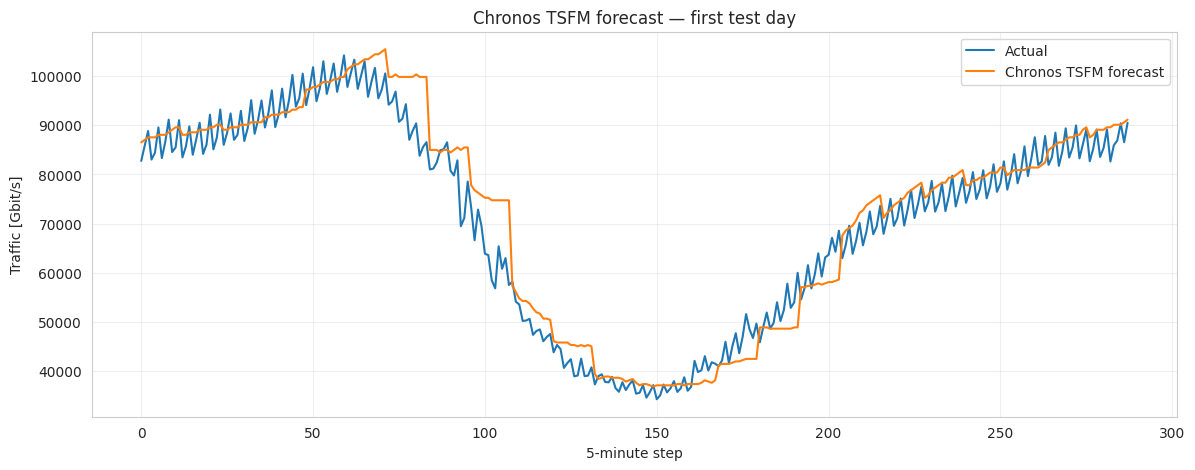

In [ ]:
# ========================
# TSFM forecast visualization
# ========================

first_day_windows = (24 * 12) // TSFM_HORIZON

plt.figure(figsize=(14, 5))

plt.plot(
    tsfm_targets[:first_day_windows].ravel(),
    label="Actual"
)

plt.plot(
    tsfm_predictions[:first_day_windows].ravel(),
    label="Chronos TSFM forecast"
)

plt.title("Chronos TSFM forecast — first test day")
plt.xlabel("5-minute step")
plt.ylabel("Traffic [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### **S4.5.6 - Save Chronos metrics**

In [ ]:
# ========================
# Save TSFM metrics
# ========================

tsfm_metrics = pd.DataFrame([
    {
        "model": "Chronos TSFM",
        "N": TSFM_CONTEXT_LENGTH,
        "K": TSFM_HORIZON,
        "model_name": TSFM_MODEL_NAME,
        "MAE_Gbit_s": tsfm_mae,
        "RMSE_Gbit_s": tsfm_rmse,
        "MAPE_percent": tsfm_mape,
        "R2": tsfm_r2,
        "training_time_seconds": 0.0,
        "inference_time_seconds": tsfm_inference_time,
    }
])

display(tsfm_metrics)

tsfm_metrics.to_csv(
    DATA_DIR / "tsfm_chronos_metrics.csv",
    index=False
)

print("Saved:", DATA_DIR / "tsfm_chronos_metrics.csv")

,model,N,K,model_name,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,inference_time_seconds
0,Chronos TSFM,72,12,amazon/chronos-bolt-small,3616.397461,4708.744631,5.223673,0.95273,0.0,2.054898


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/tsfm_chronos_metrics.csv


### **Chronos TSFM sensitivity analysis over N and K**

Keeping the same `N × K` grid used for RF, LSTM, GRU, and ARIMA makes the final comparison complete: every model is tested under the same context and horizon conditions.

In [ ]:
# ========================
# Chronos TSFM sensitivity analysis with checkpoint
# ========================

TSFM_SENSITIVITY_FILE_PATH = DATA_DIR / "tsfm_chronos_sensitivity_NK.csv"


def run_tsfm_experiment(
    n_lookback,
    k_horizon,
    batch_size=TSFM_BATCH_SIZE,
):
    X_test_exp, Y_test_exp = make_windows(
        test_raw,
        n_lookback,
        k_horizon,
        stride=k_horizon
    )

    predictions_list = []

    start_time = time.time()

    for start in range(0, len(X_test_exp), batch_size):
        batch_context = torch.from_numpy(
            X_test_exp[start : start + batch_size]
        )

        with torch.no_grad():
            batch_quantiles, batch_mean = tsfm_pipeline.predict_quantiles(
                batch_context,
                prediction_length=k_horizon,
                quantile_levels=[0.1, 0.5, 0.9]
            )

        predictions_list.append(
            batch_quantiles[:, :, 1].float().cpu().numpy()
        )

    inference_time = time.time() - start_time

    predictions_exp = np.concatenate(predictions_list)
    targets_exp = Y_test_exp

    y_pred_exp = predictions_exp.ravel()
    y_true_exp = targets_exp.ravel()

    mae_exp, rmse_exp, mape_exp, r2_exp = compute_regression_metrics(
        y_true_exp,
        y_pred_exp
    )

    return {
        "model": "Chronos TSFM",
        "N": n_lookback,
        "K": k_horizon,
        "model_name": TSFM_MODEL_NAME,
        "MAE_Gbit_s": mae_exp,
        "RMSE_Gbit_s": rmse_exp,
        "MAPE_percent": mape_exp,
        "R2": r2_exp,
        "training_time_seconds": 0.0,
        "inference_time_seconds": inference_time,
        "test_windows": len(X_test_exp),
    }


if TSFM_SENSITIVITY_FILE_PATH.exists():
    tsfm_sensitivity = pd.read_csv(TSFM_SENSITIVITY_FILE_PATH)
    tsfm_sensitivity_results = tsfm_sensitivity.to_dict("records")

    completed_pairs = set(
        zip(
            tsfm_sensitivity["N"].astype(int),
            tsfm_sensitivity["K"].astype(int)
        )
    )

    print("Loaded previous checkpoint:")
    print(TSFM_SENSITIVITY_FILE_PATH)
    print("Completed experiments:", completed_pairs)

else:
    tsfm_sensitivity_results = []
    completed_pairs = set()

    print("No checkpoint found. Starting from scratch.")


for N in N_VALUES:
    for K in K_VALUES:
        if (N, K) in completed_pairs:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running Chronos TSFM sensitivity experiment: N={N}, K={K}")

        result = run_tsfm_experiment(
            n_lookback=N,
            k_horizon=K,
            batch_size=TSFM_BATCH_SIZE,
        )

        tsfm_sensitivity_results.append(result)
        completed_pairs.add((N, K))

        tsfm_sensitivity = pd.DataFrame(tsfm_sensitivity_results)
        tsfm_sensitivity.to_csv(
            TSFM_SENSITIVITY_FILE_PATH,
            index=False
        )

        print(result)
        print("Checkpoint saved:", TSFM_SENSITIVITY_FILE_PATH)


tsfm_sensitivity = pd.DataFrame(tsfm_sensitivity_results)

display(tsfm_sensitivity)

print("Final saved file:", TSFM_SENSITIVITY_FILE_PATH)

Loaded previous checkpoint:
/content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/tsfm_chronos_sensitivity_NK.csv
Completed experiments: {(72, 12), (12, 1), (12, 36), (288, 12), (72, 1), (72, 36), (12, 12), (288, 1), (288, 36)}
Skipping already completed experiment: N=12, K=1
Skipping already completed experiment: N=12, K=12
Skipping already completed experiment: N=12, K=36
Skipping already completed experiment: N=72, K=1
Skipping already completed experiment: N=72, K=12
Skipping already completed experiment: N=72, K=36
Skipping already completed experiment: N=288, K=1
Skipping already completed experiment: N=288, K=12
Skipping already completed experiment: N=288, K=36


,model,N,K,model_name,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,inference_time_seconds,test_windows
0,Chronos TSFM,12,1,amazon/chronos-bolt-small,2646.225586,3310.092899,3.719286,0.976601,0.0,10.330629,31568
1,Chronos TSFM,12,12,amazon/chronos-bolt-small,5408.244141,7184.143930,8.291359,0.889794,0.0,1.233987,2630
2,Chronos TSFM,12,36,amazon/chronos-bolt-small,10617.358398,14390.791500,17.431194,0.558106,0.0,0.417308,876
3,Chronos TSFM,72,1,amazon/chronos-bolt-small,2607.674072,3105.652266,3.757702,0.979434,0.0,10.151711,31508
4,Chronos TSFM,72,12,amazon/chronos-bolt-small,3616.397461,4708.744631,5.223673,0.952730,0.0,1.096133,2625
5,Chronos TSFM,72,36,amazon/chronos-bolt-small,8459.740234,13084.473853,13.663535,0.635001,0.0,0.381272,875
6,Chronos TSFM,288,1,amazon/chronos-bolt-small,2353.680176,2881.474362,3.316589,0.982277,0.0,14.942574,31292
7,Chronos TSFM,288,12,amazon/chronos-bolt-small,2490.904541,3057.249090,3.488625,0.980052,0.0,1.395473,2607
8,Chronos TSFM,288,36,amazon/chronos-bolt-small,3678.390381,5049.756826,5.397264,0.945576,0.0,0.408038,869


Final saved file: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/tsfm_chronos_sensitivity_NK.csv


### **S4.5.8 - Chronos TSFM sensitivity visualization**



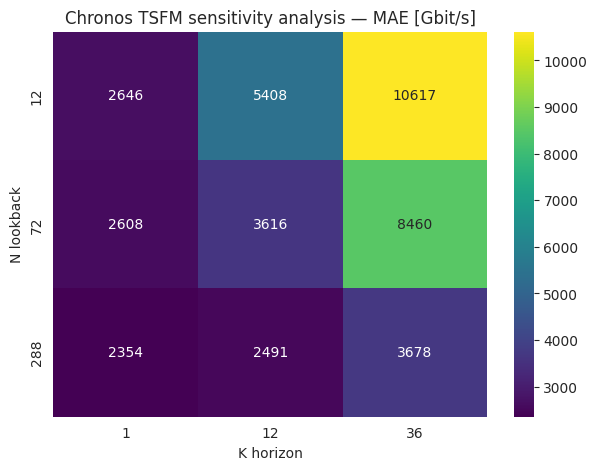

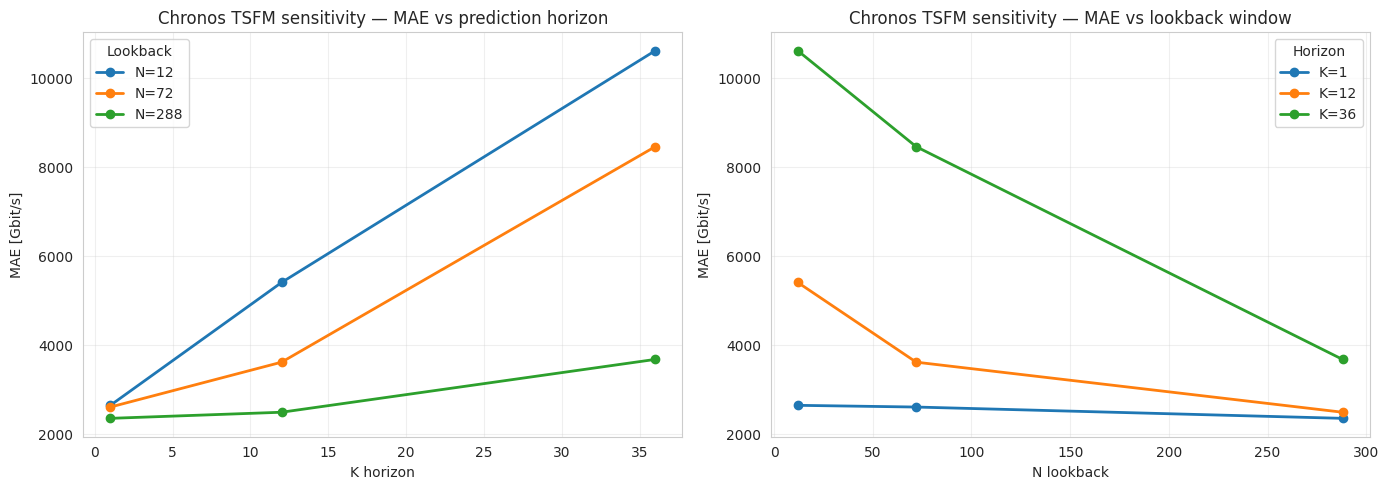

In [ ]:
# ========================
# Chronos TSFM sensitivity visualization
# ========================

pivot_mae_tsfm = tsfm_sensitivity.pivot(
    index="N",
    columns="K",
    values="MAE_Gbit_s"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    pivot_mae_tsfm,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title("Chronos TSFM sensitivity analysis — MAE [Gbit/s]")
plt.xlabel("K horizon")
plt.ylabel("N lookback")
plt.show()


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

for N in sorted(tsfm_sensitivity["N"].unique()):
    subset = tsfm_sensitivity[
        tsfm_sensitivity["N"] == N
    ].sort_values("K")

    plt.plot(
        subset["K"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"N={N}"
    )

plt.title("Chronos TSFM sensitivity — MAE vs prediction horizon")
plt.xlabel("K horizon")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Lookback")


plt.subplot(1, 2, 2)

for K in sorted(tsfm_sensitivity["K"].unique()):
    subset = tsfm_sensitivity[
        tsfm_sensitivity["K"] == K
    ].sort_values("N")

    plt.plot(
        subset["N"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"K={K}"
    )

plt.title("Chronos TSFM sensitivity — MAE vs lookback window")
plt.xlabel("N lookback")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Horizon")

plt.tight_layout()
plt.savefig(
    DATA_DIR / "tsfm_chronos_sensitivity_lineplots.png",
    dpi=150
)
plt.show()

### **S4.5.9 - Reading the Chronos TSFM sensitivity results**

The Chronos grid answers a different question from the trained models: how much a pretrained foundation model can adapt at inference time from the supplied context alone.

- If `N = 288` improves over shorter contexts, Chronos is using the full daily pattern from the prompt window.
- If the curves are flat across `N`, the pretrained model is relying more on local continuation than on full-cycle reconstruction.
- The slope across `K` is especially important: a zero-shot model that remains competitive at longer horizons is valuable even if it is not the best model at the baseline `(N = 72, K = 12)` point.

### **S4.5.10 - Extra experiment: Chronos beyond N = 288**

Chronos-Bolt supports a context of up to 512 samples (about 42.7 hours), well beyond the N = 288 (24 h) used in the shared grid. Since the model is zero-shot, extending the context only costs inference time.

This experiment is Chronos-only and kept separate from the shared N x K grid: the trained models were not evaluated at these context lengths, so these rows do not enter the S4.6 comparison. The question is whether the zero-shot forecast keeps improving once the context covers more than one full daily cycle, or whether the gain saturates at 24 h.


Loaded previous checkpoint: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/tsfm_chronos_extended_context_NK.csv
Completed experiments: {(512, 1), (384, 36), (512, 36), (384, 12), (512, 12), (384, 1)}
Skipping already completed experiment: N=384, K=1
Skipping already completed experiment: N=384, K=12
Skipping already completed experiment: N=384, K=36
Skipping already completed experiment: N=512, K=1
Skipping already completed experiment: N=512, K=12
Skipping already completed experiment: N=512, K=36


,model,N,K,model_name,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,inference_time_seconds,test_windows
0,Chronos TSFM,288,1,amazon/chronos-bolt-small,2353.680176,2881.474362,3.316589,0.982277,0.0,14.942574,31292
1,Chronos TSFM,288,12,amazon/chronos-bolt-small,2490.904541,3057.249090,3.488625,0.980052,0.0,1.395473,2607
2,Chronos TSFM,288,36,amazon/chronos-bolt-small,3678.390381,5049.756826,5.397264,0.945576,0.0,0.408038,869
3,Chronos TSFM,384,1,amazon/chronos-bolt-small,2220.319580,2712.335156,3.122778,0.984332,0.0,18.262576,31196
4,Chronos TSFM,384,12,amazon/chronos-bolt-small,2333.031982,2896.174287,3.254405,0.982139,0.0,1.541055,2599
5,Chronos TSFM,384,36,amazon/chronos-bolt-small,3398.737793,5095.404793,4.723422,0.944732,0.0,0.518811,866
6,Chronos TSFM,512,1,amazon/chronos-bolt-small,2122.520752,2612.101931,2.997463,0.985452,0.0,23.973455,31068
7,Chronos TSFM,512,12,amazon/chronos-bolt-small,2243.166016,2821.366247,3.210162,0.983027,0.0,2.033495,2589
8,Chronos TSFM,512,36,amazon/chronos-bolt-small,2595.214600,3265.889925,3.766863,0.977258,0.0,0.683818,863


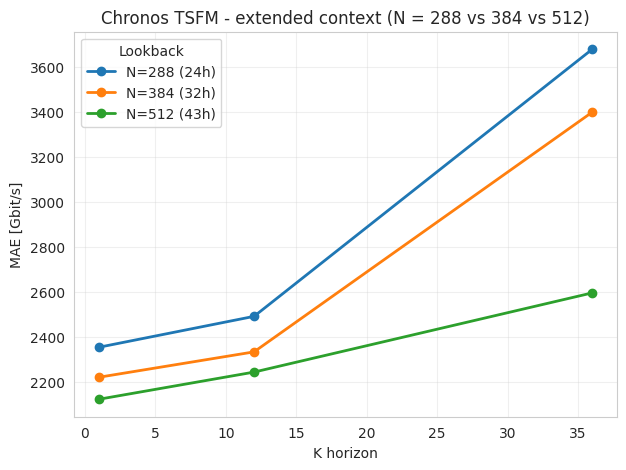

In [ ]:
# ========================
# Chronos extended-context experiment (N > 288)
# ========================

TSFM_EXTRA_N_VALUES = [384, 512]

TSFM_EXTENDED_FILE_PATH = DATA_DIR / "tsfm_chronos_extended_context_NK.csv"

if TSFM_EXTENDED_FILE_PATH.exists():
    tsfm_extended = pd.read_csv(TSFM_EXTENDED_FILE_PATH)
    tsfm_extended_results = tsfm_extended.to_dict("records")

    completed_extra = set(
        zip(
            tsfm_extended["N"].astype(int),
            tsfm_extended["K"].astype(int)
        )
    )

    print("Loaded previous checkpoint:", TSFM_EXTENDED_FILE_PATH)
    print("Completed experiments:", completed_extra)

else:
    tsfm_extended_results = []
    completed_extra = set()

    print("No checkpoint found. Starting from scratch.")


for N in TSFM_EXTRA_N_VALUES:
    for K in K_VALUES:
        if (N, K) in completed_extra:
            print(f"Skipping already completed experiment: N={N}, K={K}")
            continue

        print(f"Running Chronos extended-context experiment: N={N}, K={K}")

        result = run_tsfm_experiment(
            n_lookback=N,
            k_horizon=K,
            batch_size=TSFM_BATCH_SIZE,
        )

        tsfm_extended_results.append(result)
        completed_extra.add((N, K))

        tsfm_extended = pd.DataFrame(tsfm_extended_results)
        tsfm_extended.to_csv(TSFM_EXTENDED_FILE_PATH, index=False)

        print(result)
        print("Checkpoint saved:", TSFM_EXTENDED_FILE_PATH)


tsfm_extended = pd.DataFrame(tsfm_extended_results)

# Compare against the N=288 rows from the shared-grid sweep
tsfm_context_comparison = pd.concat(
    [
        tsfm_sensitivity[tsfm_sensitivity["N"] == 288],
        tsfm_extended,
    ],
    ignore_index=True,
).sort_values(["N", "K"])

display(tsfm_context_comparison)


plt.figure(figsize=(7, 5))

for N in sorted(tsfm_context_comparison["N"].unique()):
    subset = tsfm_context_comparison[
        tsfm_context_comparison["N"] == N
    ].sort_values("K")

    plt.plot(
        subset["K"],
        subset["MAE_Gbit_s"],
        marker="o",
        linewidth=2,
        label=f"N={N} ({N * 5 / 60:.0f}h)"
    )

plt.title("Chronos TSFM - extended context (N = 288 vs 384 vs 512)")
plt.xlabel("K horizon")
plt.ylabel("MAE [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(title="Lookback")
plt.savefig(
    DATA_DIR / "tsfm_chronos_extended_context.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


## **S4.6 - Final Model Comparison**

This is the synthesis step: every model from S4.1-S4.5 (Random Forest, LSTM, GRU, ARIMA, TSFM) was evaluated on the same test split with the same metric function, so their numbers are directly comparable.

Four views are produced:

1. a metrics table stacking the per-model baseline rows side by side;
2. a bar-plot comparison across MAE, RMSE and MAPE;
3. a forecast overlay on the first test day, to see the qualitative behavior of each model next to the headline numbers;
4. a combined sensitivity comparison showing how the five models respond to the same (N, K) grid.

In [ ]:
# Reload saved Random Forest results without retraining

rf_metrics    = pd.read_csv(DATA_DIR / "random_forest_metrics.csv")
lstm_metrics  = pd.read_csv(DATA_DIR / "lstm_metrics.csv")
gru_metrics   = pd.read_csv(DATA_DIR / "gru_metrics.csv")
arima_metrics = pd.read_csv(DATA_DIR / "arima_metrics.csv")
tsfm_metrics  = pd.read_csv(DATA_DIR / "tsfm_chronos_metrics.csv")

rf_sensitivity = pd.read_csv(DATA_DIR / "random_forest_sensitivity_NK.csv")

display(rf_metrics)
display(rf_sensitivity)

,model,N,K,n_estimators,max_depth,min_samples_leaf,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
0,Random Forest,72,12,200,NaN,2,3986.082132,5623.592677,5.259206,0.932577,1003.768117


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds,train_windows,test_windows
0,Random Forest,12,1,2815.992756,4066.950428,3.836954,0.964677,170.681502,49120,31568
1,Random Forest,12,12,3632.622651,5072.890433,4.892087,0.945050,220.115772,49116,2630
2,Random Forest,12,36,6995.509335,10128.549155,8.697594,0.781101,317.753646,49108,876
3,Random Forest,72,1,2801.073465,4026.258486,3.797560,0.965434,987.403350,49100,31508
4,Random Forest,72,12,3986.082132,5623.592677,5.259206,0.932577,1210.501245,49096,2625
5,Random Forest,72,36,7932.972823,12187.588049,9.588643,0.683324,1753.923070,49088,875
6,Random Forest,288,1,2672.298735,3749.978221,3.653389,0.969983,3950.617872,49028,31292
7,Random Forest,288,12,3214.194500,4201.803474,4.472675,0.962319,4620.736404,49024,2607
8,Random Forest,288,36,3395.001356,4511.346519,4.668188,0.956563,6487.774712,49016,869


In [ ]:
# ========================
# Metrics table (all models)
# ========================

team12_comparison = pd.concat(
    [
        rf_metrics,
        lstm_metrics,
        gru_metrics,
        arima_metrics,
        tsfm_metrics,
    ],
    ignore_index=True
)

display(
    team12_comparison[
        [
            "model",
            "N",
            "K",
            "MAE_Gbit_s",
            "RMSE_Gbit_s",
            "MAPE_percent",
            "R2",
            "training_time_seconds"
        ]
    ]
)

team12_comparison.to_csv(
    DATA_DIR / "team12_model_comparison.csv",
    index=False
)

print("Saved:", DATA_DIR / "team12_model_comparison.csv")


,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
0,Random Forest,72,12,3986.082132,5623.592677,5.259206,0.932577,1003.768117
1,LSTM,72,12,3371.156494,4080.237371,4.609358,0.964506,8.950225
2,GRU,72,12,3532.191895,4072.446562,4.852595,0.964642,28.778393
3,"ARIMA(7, 1, 0)",72,12,2065.575439,3638.307024,3.060808,0.971779,0.000000
4,Chronos TSFM,72,12,3616.397461,4708.744631,5.223673,0.952730,0.000000


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/team12_model_comparison.csv


### **S4.6.1 - Reading the metrics table**



At the default setting, ARIMA(7,1,0) leads on every metric (MAE, MAPE, RMSE and R2). Every prediction is anchored to the most recent 6-hour trend, and the richer AR(7) specification selected in S4.4.2b/c closes the RMSE gap that the earlier (5,1,0) run still showed.

Among the learned models, GRU and LSTM are effectively equivalent: the GRU has a marginally lower RMSE (4072 vs 4080 Gbit/s, less than 0.2% apart) and a slightly higher R2 (0.9646 vs 0.9645), differences well within run-to-run variability. On the cost side, Chronos (zero-shot) and ARIMA (no offline training) are the cheapest, the LSTM and GRU come next, and the RF is two orders of magnitude more expensive than the neural baselines.

The gap between MAE and RMSE is also informative. The RMSE/MAE ratio is roughly 1.2 for the LSTM and 1.3 for the TSFM, but about 1.8 for ARIMA and 1.4 for the RF: a wider gap means heavier-tailed errors, so ARIMA is excellent on routine windows and comparatively worse on the few extreme ones. With (7,1,0), however, its absolute RMSE is still the lowest of all five models, so the heavier tail no longer costs it the worst-case ranking at this setting.


/tmp/ipykernel_644/1421957698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_644/1421957698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_644/1421957698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_644/1421957698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


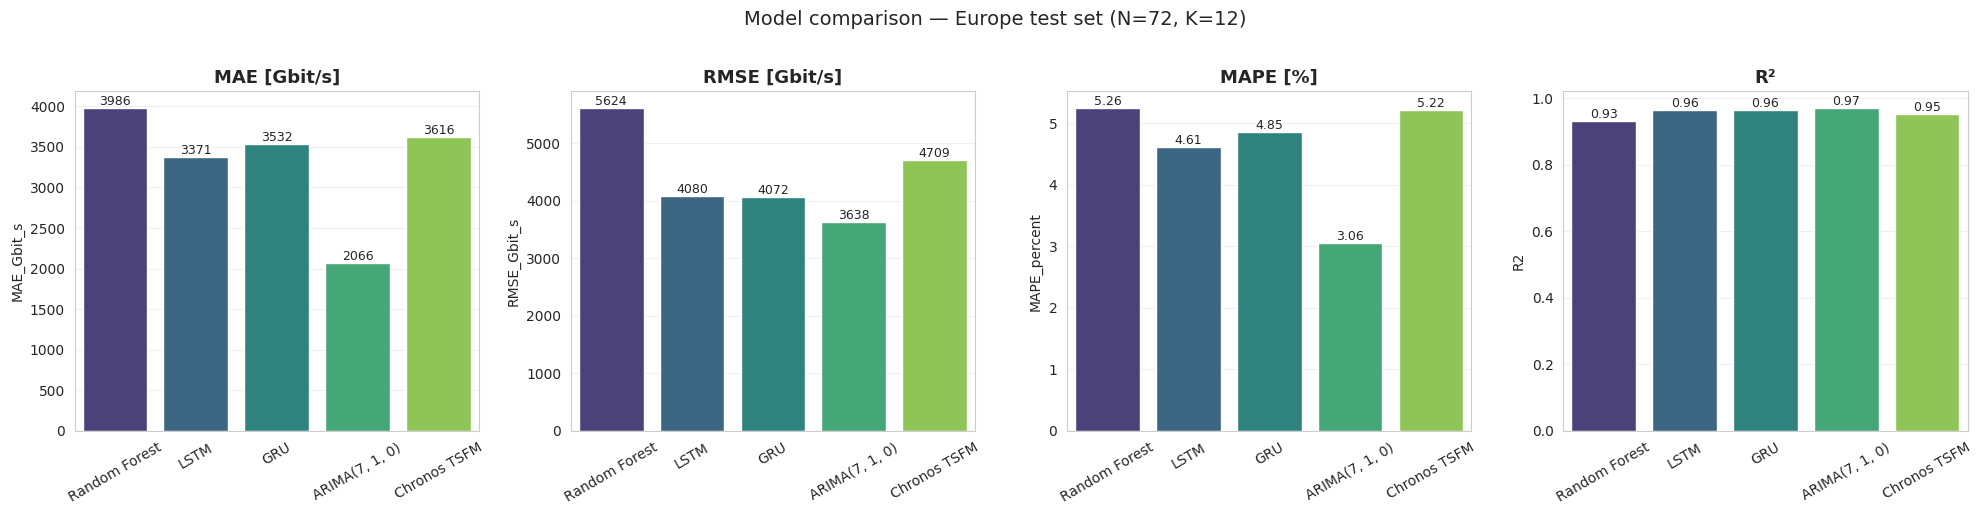

In [ ]:
# ========================
# Bar-plot comparison
# ========================

metrics_to_plot = [
    ("MAE_Gbit_s", "MAE [Gbit/s]"),
    ("RMSE_Gbit_s", "RMSE [Gbit/s]"),
    ("MAPE_percent", "MAPE [%]"),
    ("R2", "R²"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, label) in zip(axes, metrics_to_plot):
    bars = sns.barplot(
        data=team12_comparison,
        x="model",
        y=col,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)

    # Rotate long model names
    ax.tick_params(axis="x", rotation=30)

    # Annotate bars with values
    for bar in bars.patches:
        val = bar.get_height()
        fmt = f"{val:.2f}" if abs(val) < 10 else f"{val:.0f}"
        ax.annotate(
            fmt,
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle(f"Model comparison — Europe test set (N={N_LOOKBACK}, K={K_HORIZON})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "team12_model_comparison_bars.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### **S4.6.2 - Reading the bar-plot comparison**

The three bars (MAE, RMSE, MAPE) are consistent when read together.

ARIMA has the shortest bars on every metric: with the (7,1,0) order it leads MAE, RMSE and MAPE alike. Its RMSE/MAE ratio (about 1.8) is still the widest of the five, so it keeps a comparatively heavier tail of large errors, but in absolute terms even its worst-case metric is now the best. At this (N, K) setting, per-window refitting is simply the strongest approach.

The LSTM and GRU bars are almost indistinguishable on all three metrics. This is the clearest finding of the comparison: on this signal the LSTM's extra gating does not pay for itself, and either model could be used.

Random Forest has by far the worst RMSE, disproportionately so relative to its (already worst) MAE. This is the classic failure mode of trees, which cannot extrapolate: predictions are bounded by the training-set maxima, so any test window with traffic above the training peak is guaranteed to be wrong, and by a lot.

The TSFM lands between LSTM/GRU and RF on every metric, never best and never worst. For a zero-shot model that has never seen IXP data, this is a competitive result.


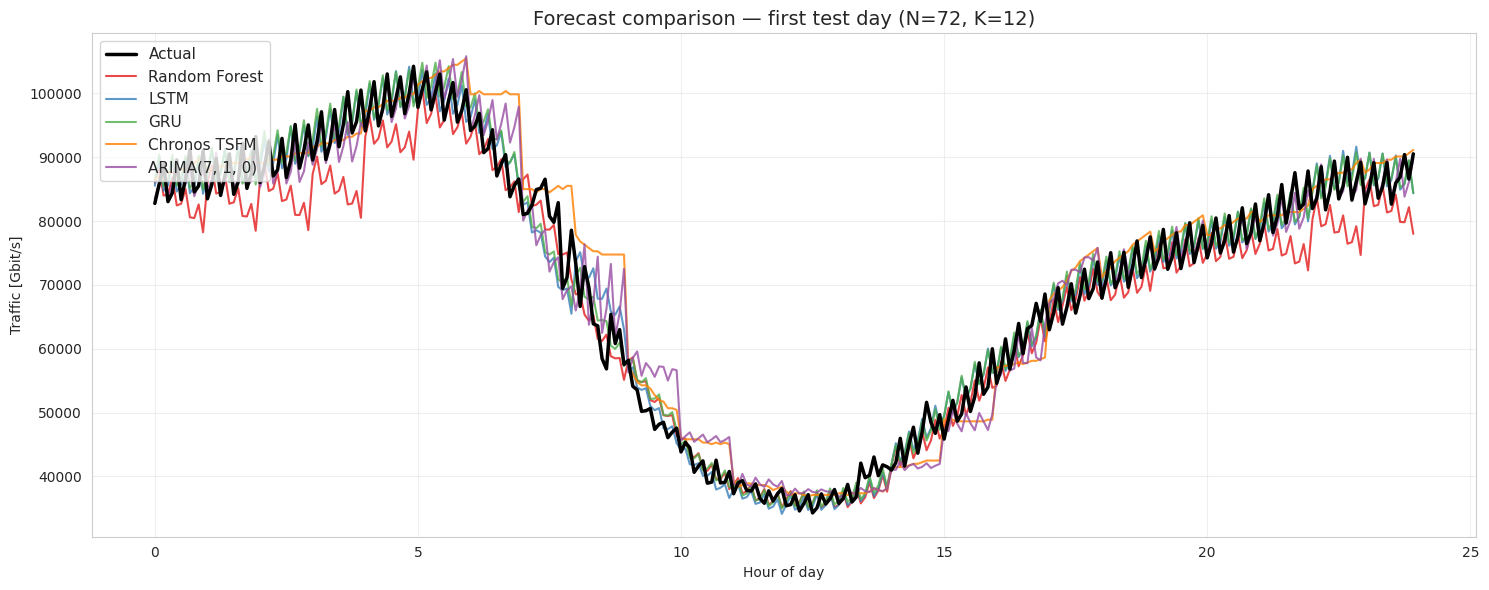

In [ ]:
# ========================
# Forecast overlay on first test day
# ========================

from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

first_day_windows = (24 * 12) // K_HORIZON

# Load RF predictions if they were saved previously
if "rf_predictions" not in globals() and (DATA_DIR / "rf_predictions.npy").exists():
    print("Loading saved Random Forest predictions...")
    rf_predictions = np.load(DATA_DIR / "rf_predictions.npy")
    rf_targets = np.load(DATA_DIR / "rf_targets.npy")

# Regenerate RF predictions only if rf_model exists AND is fitted
if "rf_predictions" not in globals() and "rf_model" in globals():
    try:
        check_is_fitted(rf_model)

        print("Regenerating Random Forest predictions from fitted rf_model...")

        rf_predictions_scaled = rf_model.predict(X_test)
        rf_predictions = scaler.inverse(rf_predictions_scaled)
        rf_targets = scaler.inverse(Y_test)

        np.save(DATA_DIR / "rf_predictions.npy", rf_predictions)
        np.save(DATA_DIR / "rf_targets.npy", rf_targets)

    except NotFittedError:
        print("Skipping Random Forest overlay: rf_model exists but is not fitted.")


# Prepare x-axis: convert 5-minute steps to hours for readability
n_steps = first_day_windows * K_HORIZON
x_hours = np.arange(n_steps) * 5 / 60

plt.figure(figsize=(15, 6))

plt.plot(
    x_hours,
    lstm_targets[:first_day_windows].ravel(),
    label="Actual",
    linewidth=2.5,
    color="black",
    zorder=5
)

model_colors = {
    "Random Forest": "#e41a1c",
    "LSTM":          "#377eb8",
    "GRU":           "#4daf4a",
    "Chronos TSFM":  "#ff7f00",
    "ARIMA":         "#984ea3",
}

if "rf_predictions" in globals():
    plt.plot(
        x_hours,
        rf_predictions[:first_day_windows].ravel(),
        label="Random Forest",
        alpha=0.8,
        color=model_colors["Random Forest"]
    )

plt.plot(
    x_hours,
    lstm_predictions[:first_day_windows].ravel(),
    label="LSTM",
    alpha=0.8,
    color=model_colors["LSTM"]
)

plt.plot(
    x_hours,
    gru_predictions[:first_day_windows].ravel(),
    label="GRU",
    alpha=0.8,
    color=model_colors["GRU"]
)

plt.plot(
    x_hours,
    tsfm_predictions[:first_day_windows].ravel(),
    label="Chronos TSFM",
    alpha=0.8,
    color=model_colors["Chronos TSFM"]
)

plt.plot(
    x_hours,
    arima_predictions[:first_day_windows].ravel(),
    label=f"ARIMA{ARIMA_ORDER}",
    alpha=0.8,
    color=model_colors["ARIMA"]
)

plt.title(f"Forecast comparison — first test day (N={N_LOOKBACK}, K={K_HORIZON})", fontsize=14)
plt.xlabel("Hour of day")
plt.ylabel("Traffic [Gbit/s]")
plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=11)

plt.tight_layout()

plt.savefig(
    DATA_DIR / "team12_forecast_overlay_first_test_day.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### **S4.6.3 - Reading the forecast overlay (first test day)**


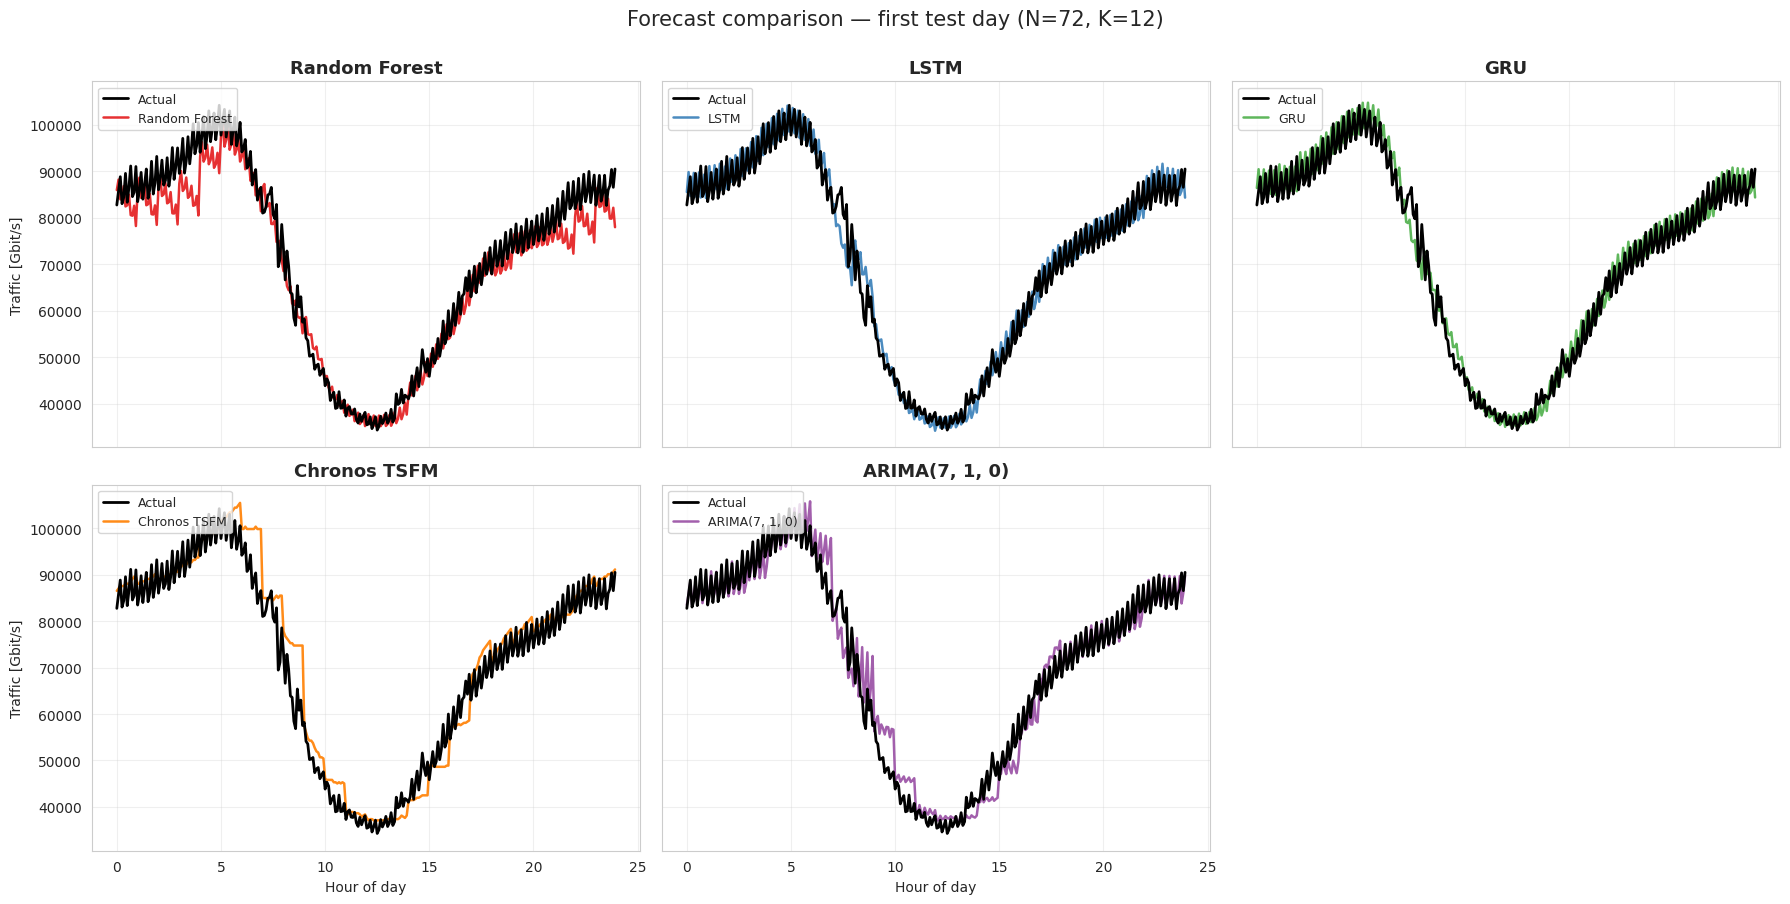

In [ ]:
actual = lstm_targets[:first_day_windows].ravel()

series = [
    ("Random Forest", rf_predictions if "rf_predictions" in globals() else None, model_colors["Random Forest"]),
    ("LSTM",          lstm_predictions, model_colors["LSTM"]),
    ("GRU",           gru_predictions, model_colors["GRU"]),
    ("Chronos TSFM",  tsfm_predictions, model_colors["Chronos TSFM"]),
    (f"ARIMA{ARIMA_ORDER}", arima_predictions, model_colors["ARIMA"]),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, preds, color) in zip(axes, series):
    ax.plot(x_hours, actual, label="Actual", linewidth=2, color="black", zorder=5)
    if preds is not None:
        ax.plot(x_hours, preds[:first_day_windows].ravel(), label=name, linewidth=1.8, color=color, alpha=0.9)
    else:
        ax.text(0.5, 0.5, f"{name}\n(not available)", transform=ax.transAxes,
                ha="center", va="center", color="gray")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

# hide the unused 6th subplot
axes[-1].axis("off")

for ax in axes[3:5]:
    ax.set_xlabel("Hour of day")
for ax in [axes[0], axes[3]]:
    ax.set_ylabel("Traffic [Gbit/s]")

plt.suptitle(f"Forecast comparison — first test day (N={N_LOOKBACK}, K={K_HORIZON})", fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(DATA_DIR / "team12_forecast_overlay_small_multiples.png", dpi=150, bbox_inches="tight")
plt.show()


### **S4.6.4 - Sensitivity comparison across all models**

This cell combines the five sensitivity DataFrames into one table and produces the final all-model sensitivity plots:

1. one MAE heatmap per model;
2. one line-plot panel per lookback value `N`, comparing how MAE grows with `K`;
3. a best-configuration table showing the lowest-MAE `(N, K)` pair for each model.

,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2,training_time_seconds
27,"ARIMA(7, 1, 0)",12,1,1669.862183,2861.524506,2.495829,0.982513,0.000000
28,"ARIMA(7, 1, 0)",12,12,6474.853027,23429.693297,9.252100,-0.172167,0.000000
29,"ARIMA(7, 1, 0)",12,36,16518.232422,48833.591062,24.974054,-4.088460,0.000000
30,"ARIMA(7, 1, 0)",72,1,1030.871704,1585.006940,1.549781,0.994643,0.000000
31,"ARIMA(7, 1, 0)",72,12,2065.575439,3638.307024,3.060808,0.971779,0.000000
32,"ARIMA(7, 1, 0)",72,36,6195.300781,10011.680378,9.624394,0.786305,0.000000
33,"ARIMA(7, 1, 0)",288,1,972.543335,1469.722423,1.458105,0.995389,0.000000
34,"ARIMA(7, 1, 0)",288,12,2008.978638,3142.090864,2.966816,0.978929,0.000000
35,"ARIMA(7, 1, 0)",288,36,5523.607910,9252.880200,8.631177,0.817274,0.000000
36,Chronos TSFM,12,1,2646.225586,3310.092899,3.719286,0.976601,0.000000


Saved: /content/drive/MyDrive/NDA_PROJECT/MAIN/ixp-traffic-dataset/data/team12_all_models_sensitivity_NK.csv


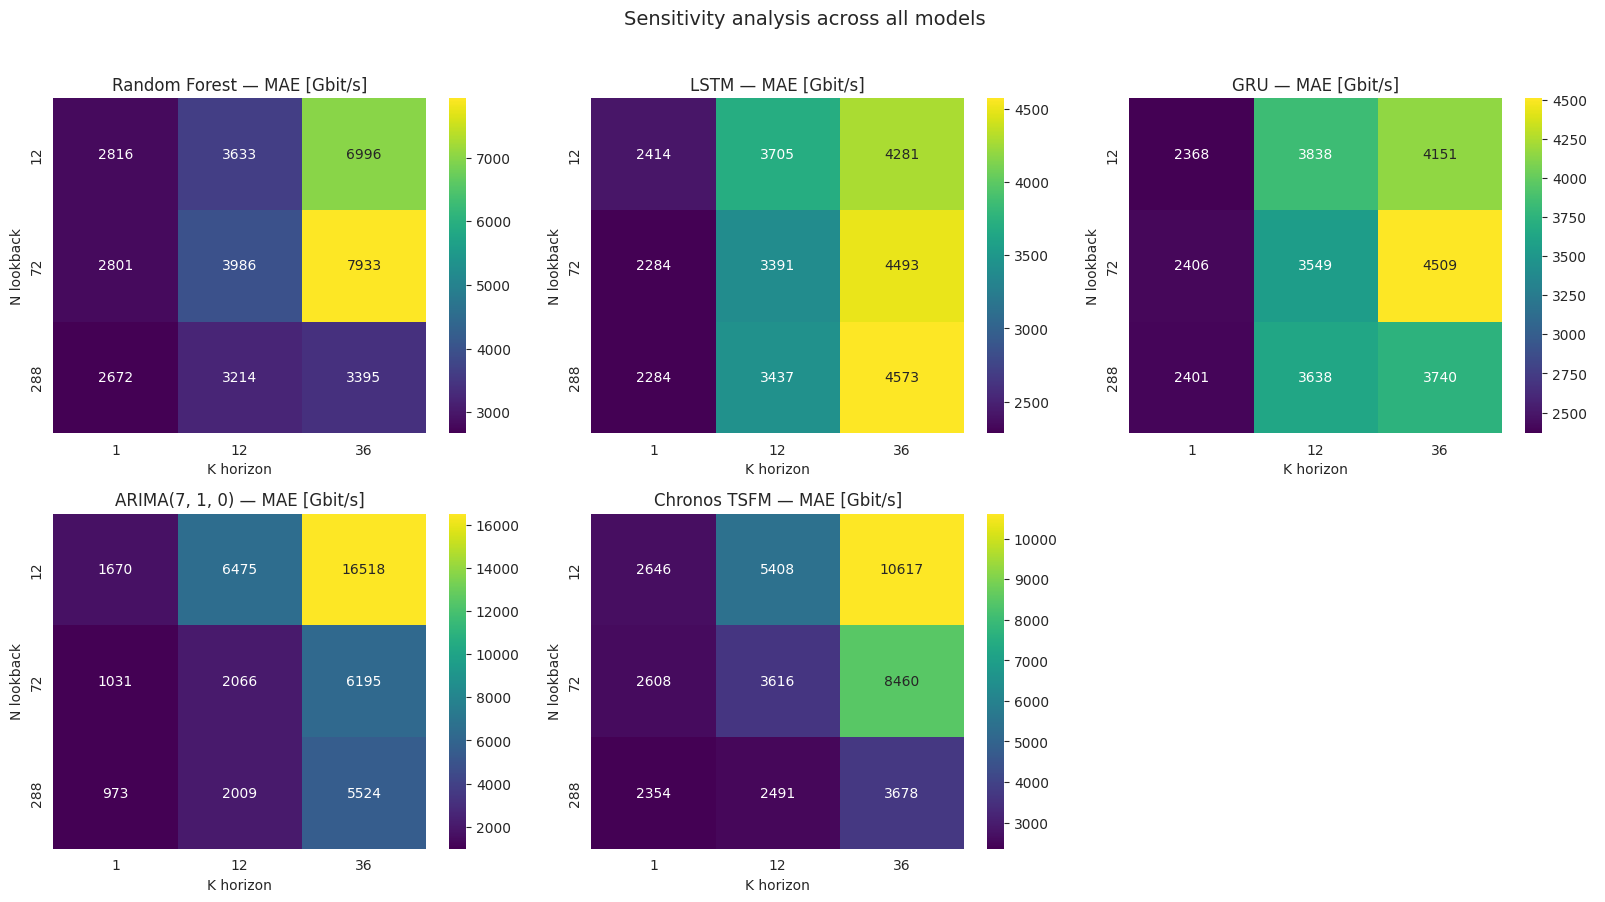

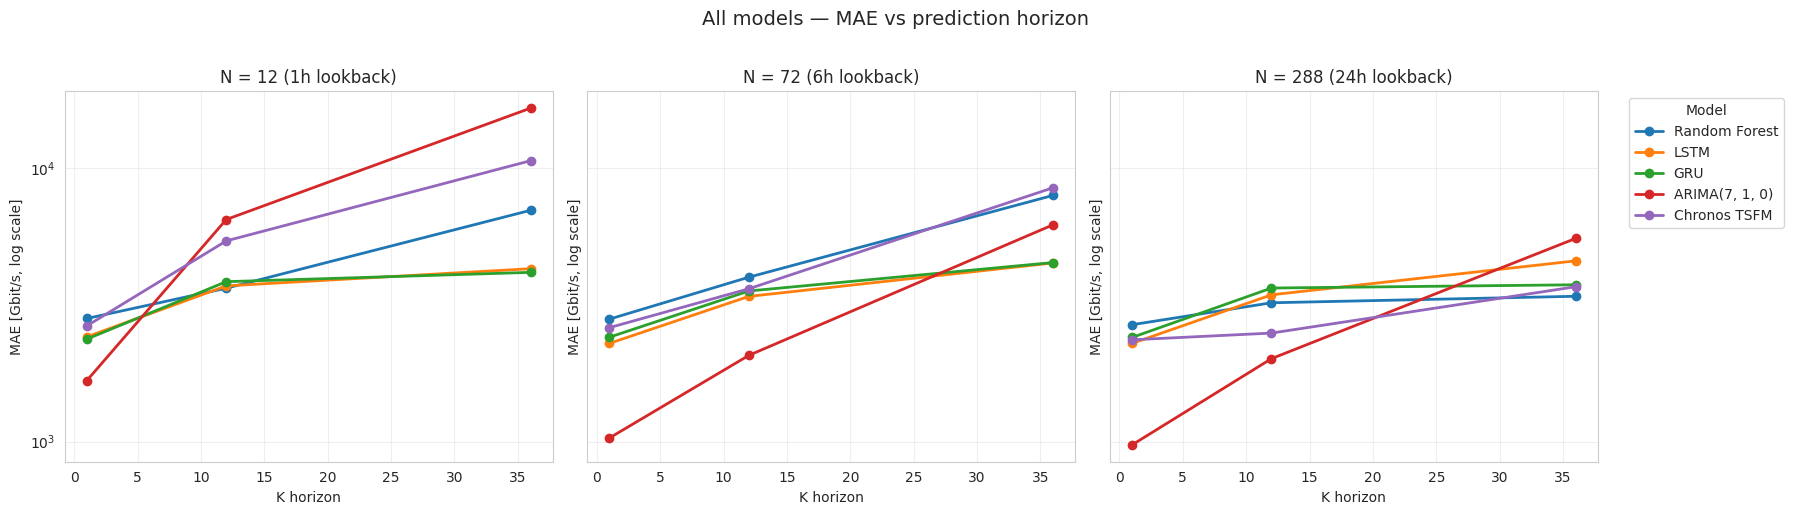

,model,N,K,MAE_Gbit_s,RMSE_Gbit_s,MAPE_percent,R2
33,"ARIMA(7, 1, 0)",288,1,972.543335,1469.722423,1.458105,0.995389
15,LSTM,288,1,2283.743164,2919.696731,3.155295,0.981803
42,Chronos TSFM,288,1,2353.680176,2881.474362,3.316589,0.982277
18,GRU,12,1,2367.717773,3032.853607,3.262804,0.980356
6,Random Forest,288,1,2672.298735,3749.978221,3.653389,0.969983


In [ ]:
# ========================
# Final sensitivity comparison across all models
# ========================

sensitivity_sources = [
    ("Random Forest", "rf_sensitivity", DATA_DIR / "random_forest_sensitivity_NK.csv"),
    ("LSTM", "lstm_sensitivity", DATA_DIR / "lstm_sensitivity_NK.csv"),
    ("GRU", "gru_sensitivity", DATA_DIR / "gru_sensitivity_NK.csv"),
    (f"ARIMA{ARIMA_ORDER}", "arima_sensitivity", DATA_DIR / f"arima_sensitivity_NK_p{ARIMA_ORDER[0]}d{ARIMA_ORDER[1]}q{ARIMA_ORDER[2]}.csv"),
    ("Chronos TSFM", "tsfm_sensitivity", DATA_DIR / "tsfm_chronos_sensitivity_NK.csv"),
]

sensitivity_frames = []

for model_label, variable_name, file_path in sensitivity_sources:
    if variable_name in globals():
        frame = globals()[variable_name].copy()
    elif file_path.exists():
        frame = pd.read_csv(file_path)
    else:
        raise FileNotFoundError(
            f"Missing sensitivity results for {model_label}: {file_path}"
        )

    sensitivity_frames.append(frame)


team12_sensitivity_all = (
    pd.concat(sensitivity_frames, ignore_index=True)
    .sort_values(["model", "N", "K"])
)

display(
    team12_sensitivity_all[
        [
            "model",
            "N",
            "K",
            "MAE_Gbit_s",
            "RMSE_Gbit_s",
            "MAPE_percent",
            "R2",
            "training_time_seconds",
        ]
    ]
)

team12_sensitivity_all.to_csv(
    DATA_DIR / "team12_all_models_sensitivity_NK.csv",
    index=False
)

print("Saved:", DATA_DIR / "team12_all_models_sensitivity_NK.csv")


# Heatmap grid
model_order = [
    "Random Forest",
    "LSTM",
    "GRU",
    f"ARIMA{ARIMA_ORDER}",
    "Chronos TSFM",
]

model_order = [
    model
    for model in model_order
    if model in set(team12_sensitivity_all["model"])
]

n_cols = 3
n_rows = int(np.ceil(len(model_order) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.4 * n_cols, 4.4 * n_rows),
    squeeze=False
)

for ax in axes.ravel():
    ax.axis("off")

for idx, model in enumerate(model_order):
    ax = axes.ravel()[idx]
    ax.axis("on")

    pivot = team12_sensitivity_all[
        team12_sensitivity_all["model"] == model
    ].pivot(
        index="N",
        columns="K",
        values="MAE_Gbit_s"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        ax=ax
    )

    ax.set_title(f"{model} — MAE [Gbit/s]")
    ax.set_xlabel("K horizon")
    ax.set_ylabel("N lookback")

plt.suptitle("Sensitivity analysis across all models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "team12_all_models_sensitivity_heatmaps.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# Line plots
fig, axes = plt.subplots(
    1,
    len(N_VALUES),
    figsize=(6 * len(N_VALUES), 5),
    sharey=True
)

if len(N_VALUES) == 1:
    axes = [axes]

for ax, N in zip(axes, sorted(N_VALUES)):
    for model in model_order:
        subset = team12_sensitivity_all[
            (team12_sensitivity_all["model"] == model) &
            (team12_sensitivity_all["N"] == N)
        ].sort_values("K")

        ax.plot(
            subset["K"],
            subset["MAE_Gbit_s"],
            marker="o",
            linewidth=2,
            label=model
        )

    ax.set_yscale("log")
    ax.set_title(f"N = {N} ({N * 5 // 60}h lookback)")
    ax.set_xlabel("K horizon")
    ax.set_ylabel("MAE [Gbit/s, log scale]")
    ax.grid(alpha=0.3)

axes[-1].legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.suptitle("All models — MAE vs prediction horizon", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "team12_all_models_sensitivity_lineplots.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# Best sensitivity point per model
best_sensitivity_by_model = (
    team12_sensitivity_all
    .loc[team12_sensitivity_all.groupby("model")["MAE_Gbit_s"].idxmin()]
    .sort_values("MAE_Gbit_s")
)

display(
    best_sensitivity_by_model[
        [
            "model",
            "N",
            "K",
            "MAE_Gbit_s",
            "RMSE_Gbit_s",
            "MAPE_percent",
            "R2",
        ]
    ]
)

### **S4.6.5 - Reading the all-model sensitivity comparison**

The combined sensitivity figure is the most complete view of the forecasting task, because it separates two effects that the baseline metrics table compresses into one row: how quickly each model deteriorates as K grows from 1 to 12 to 36, and how much each model benefits from a longer context, moving from 1 hour (N = 12) to 6 hours (N = 72) to a full day (N = 288).

This matters because the best baseline model at (N = 72, K = 12) is not necessarily the best choice for every horizon: a model with slightly worse baseline MAE can still be preferable if its line is flatter across K, or if it reaches good performance with a shorter context window.

The best-configuration table at the end should be read together with the compute cost: the lowest-MAE point is interesting per se, but in practice the right choice is the lowest error that is still cheap enough to re-train at the desired refresh rate.

### **S4.6.6 - Conclusion and model recommendation**

Which model to prefer depends on the constraint. For pure accuracy at the default setting, ARIMA(7,1,0) wins on every metric, at the price of a fresh fit per window and a sharp degradation at long horizons. GRU and LSTM are equivalent within noise, cheap to train and more robust as K grows, so either is a good choice for medium horizons. Chronos needs no training at all and stays close to the trained models, which makes it attractive when data or time are limited. Random Forest is the weakest default: worst RMSE, no extrapolation beyond training peaks, and by far the most expensive to train.

More in general, the horizon K is the dominant source of difficulty (error grows much faster along K than along N), the full daily cycle N = 288 helps mostly the non-recurrent models, and a zero-shot foundation model proves to be a credible baseline. No model dominates the others on every axis.